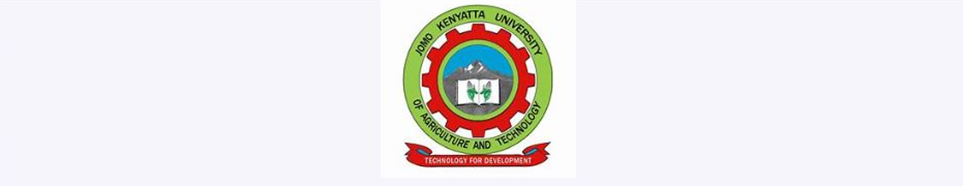

# Introduction

## Title 
### Impact of Al in African Startups and Enterprise Success in 2025
A Comprehensive Study of Exposure, Applications, and Implications of Artificial Intelligence for Investment Dynamics and the Future of Work,
Jomo Kenyatta University of Agriculture and Technology (JKUAT)

### Authors :
John Mwega | SCT212-0055/2021
BCT2406 : Project ,  BSc. Computer Technology
### Supervisor: 
Dr. Damaris Waema, PHd



### Keywords:
Artificial Intelligence, African Startups, Machine Learning, Venture Capital, Workforce Transformation, Future of Work, Investment Analysis, Economic Impact

## Abtsract

This notebook presents the computational workflow for analyzing the exposure, applications, and implications of Artificial Intelligence (AI) on startup investment dynamics and workforce transformation. 

The analysis integrates three primary datasets:

1. **World Bank Development Indicators** – providing historical and structural context, including GDP, R&D expenditure, education and health spending, and sectoral composition across countries. This dataset operationalizes national readiness and macroeconomic conditions influencing AI adoption and startup success.

2. **AI Job Market & Skills Dataset (2015–2025)** – capturing current workforce demand for AI-related roles, skill requirements, salaries, and remote work trends. This dataset enables the measurement of sectoral AI adoption, workforce skill intensity, and evolving occupational dynamics.

3. **Startup Investment & Outcomes Dataset** – including funding rounds, investor profiles, industry classification, and startup outcomes (operating, acquired, or closed). This dataset supports predictive modeling of startup success based on AI maturity, workforce composition, and investment behavior.

## Objectives

The objectives of this notebook are to:

- Preprocess and clean the datasets for analysis,
- Construct composite indices such as the **AI Maturity Index**, **Workforce Skill Density**, and **Investment Intensity Index**,
- Explore descriptive and inferential statistics on AI exposure, funding patterns, and workforce characteristics,
- Develop and evaluate a **machine learning model** to predict startup success or failure, and
- Visualize insights to inform investors, policymakers, and founders.

Throughout the notebook, computational steps are annotated for transparency and reproducibility, enabling clear tracking of data preparation, feature engineering, model training, and validation processes.

## Problem Statement

Startups play a critical role in economic development and innovation, yet a significant proportion fail within the first few years due to insufficient funding, poor market fit, weak governance, or inadequate adoption of emerging technologies like Artificial Intelligence (AI). 

While AI adoption has the potential to enhance productivity, inform investment decisions, and transform workforce composition, its actual influence on startup performance and investment dynamics remains underexplored—particularly in emerging economies such as those in Africa. 

Existing research often examines either macroeconomic indicators, labor market trends, or investment outcomes in isolation, limiting the understanding of cross-scale interactions. This study addresses this gap by integrating three complementary datasets:

1. **World Bank Development Indicators** – capturing national-level structural and economic conditions.
2. **Global AI Job Market & Skills Dataset** – representing sector-level AI adoption and workforce transformation.
3. **Startup Investment & Outcomes Dataset** – reflecting firm-level funding dynamics and success or failure outcomes.

The central problem is to understand how AI exposure, workforce skill composition, and investment patterns interact to influence the probability of startup success or failure, and how these insights can inform evidence-based strategies for investors, policymakers, and founders.




# Methodology

## Setup & Configuration

### Import Libraries

This section imports all required Python libraries used throughout the project.  
All libraries are Kaggle-compatible and support modern data science workflows. 
This setup provides a complete pipeline for data preprocessing, modeling, evaluation, and visualization.


In [1]:
# ===============================
# All libraries used in this project
# Kaggle-safe & modern
# ===============================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Utilities
from sklearn.utils import resample

# Decision Tree Visualization (NO pydotplus)
from sklearn.tree import export_graphviz
from io import StringIO
import graphviz

# Misc
import random


### Load the datasets


###  Country-Level Dataset

This dataset contains country-level macroeconomic indicators.
It is used to analyze economic conditions and national development patterns.

After loading:

* The system confirms successful upload.
* Memory usage is displayed to understand dataset size and computational cost.


In [2]:
wb_df = pd.read_csv("../input/country-data/Countries.csv") # uploading data set

#  wb_df is already loaded
print(f"✅ Dataset loaded successfully")
print(f"   • Memory usage: {wb_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

✅ Dataset loaded successfully
   • Memory usage: 1.79 MB



##  Startup Investment Dataset

This dataset includes venture capital investment records from Crunchbase.

It is used to:

* Analyze funding patterns
* Study startup survival and investment behavior
* Connect financial dynamics to economic and AI indicators

Memory usage is displayed to ensure efficient processing.



In [3]:
sf_df = pd.read_csv("../input/startup-investments-crunchbase/investments_VC.csv") # uploading data set

# sf_df is already loaded
print(f"✅ Dataset loaded successfully")
print(f"   • Memory usage: {sf_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

✅ Dataset loaded successfully
   • Memory usage: 61.22 MB



###  Global AI Workforce & Automation Dataset

This dataset captures global AI adoption and workforce transformation trends from 2015–2025.

It includes:

* AI workforce growth
* Automation trends
* AI sector maturity indicators

This dataset enables:

* Analysis of AI readiness
* Study of workforce transformation
* Integration with macroeconomic and startup performance data

After loading:

* A confirmation message is displayed.
* Memory usage is calculated to monitor computational efficiency.


In [4]:
gw_df = pd.read_csv("../input/ai-workforce-and-automation-dataset-20152025/global_ai_workforce_automation_2015_2025.csv") # uploading data set

# gw_df is already loaded
print(f"✅ Dataset loaded successfully")
print(f"   • Memory usage: {gw_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

✅ Dataset loaded successfully
   • Memory usage: 0.03 MB



### Dataset Sampling

In [5]:
# World Bank dataset

print("\nData Info:")
wb_df.info()

print("\nColumn Names:")
print(wb_df.columns)

print("\nDataset Shape:")
print(wb_df.shape)

# Display basic overview
print("Top 5 rows:")
display(wb_df.head())

print("\nStatistical Summary:")
display(wb_df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5106 entries, 0 to 5105
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country Name                   5106 non-null   object 
 1   Country Code                   5106 non-null   object 
 2   Year                           5106 non-null   int64  
 3   Agriculture (% GDP)            4830 non-null   float64
 4   Ease of Doing Business         4508 non-null   float64
 5   Education Expenditure (% GDP)  4738 non-null   float64
 6   Export (% GDP)                 4646 non-null   float64
 7   GDP                            5037 non-null   float64
 8   Health Expenditure (% GDP)     4531 non-null   float64
 9   Import (% GDP)                 4646 non-null   float64
 10  Industry (% GDP)               4853 non-null   float64
 11  Inflation Rate                 4554 non-null   float64
 12  R&D                            3588 

,Country Name,Country Code,Year,Agriculture (% GDP),Ease of Doing Business,Education Expenditure (% GDP),Export (% GDP),GDP,Health Expenditure (% GDP),Import (% GDP),...,Population,Land,Continent Name,Export,Import,Education Expenditure,Health Expenditure,Net Trade,GDP Per Capita,Population Density
0,Afghanistan,AFG,2000,27.501127,40.717968,13.670101,NaN,1.415197e+10,10.902580,NaN,...,19542982.0,652860.0,Asia,NaN,NaN,1.934589e+09,1.542930e+09,NaN,724.145910,29.934415
1,Afghanistan,AFG,2001,27.501127,40.717968,13.670101,NaN,1.415197e+10,10.902580,NaN,...,19688632.0,652860.0,Asia,NaN,NaN,1.934589e+09,1.542930e+09,NaN,718.788917,30.157510
2,Afghanistan,AFG,2002,38.627892,40.717968,13.670101,NaN,3.854235e+09,9.443391,NaN,...,21000256.0,652860.0,Asia,NaN,NaN,5.268779e+08,3.639705e+08,NaN,183.532775,32.166553
3,Afghanistan,AFG,2003,37.418855,40.717968,13.670101,NaN,4.539497e+09,8.941258,NaN,...,22645130.0,652860.0,Asia,NaN,NaN,6.205538e+08,4.058881e+08,NaN,200.462376,34.686043
4,Afghanistan,AFG,2004,29.721067,40.717968,13.670101,NaN,5.220825e+09,9.808474,NaN,...,23553551.0,652860.0,Asia,NaN,NaN,7.136921e+08,5.120832e+08,NaN,221.657662,36.077491



Statistical Summary:


,Year,Agriculture (% GDP),Ease of Doing Business,Education Expenditure (% GDP),Export (% GDP),GDP,Health Expenditure (% GDP),Import (% GDP),Industry (% GDP),Inflation Rate,...,Unemployment,Population,Land,Export,Import,Education Expenditure,Health Expenditure,Net Trade,GDP Per Capita,Population Density
count,5106.000000,4830.000000,4508.000000,4738.000000,4646.000000,5.037000e+03,4531.000000,4646.000000,4853.000000,4554.000000,...,4439.000000,5.106000e+03,5.106000e+03,4.646000e+03,4.646000e+03,4.692000e+03,4.531000e+03,4.646000e+03,5037.000000,5106.000000
mean,2011.000000,10.893914,61.738665,14.458547,44.018003,3.120245e+11,6.167133,49.445204,26.315490,6.991400,...,8.115195,3.282803e+07,7.003599e+05,9.505712e+10,9.248778e+10,4.304518e+10,3.214250e+10,2.569338e+09,15336.273219,336.020957
std,6.633899,10.971965,13.775267,4.984259,33.173984,1.405946e+12,2.744570,30.474001,12.924200,19.858123,...,5.888784,1.281141e+08,2.117451e+06,2.638186e+11,2.720004e+11,1.946240e+11,2.012357e+11,5.380235e+10,23831.258493,1570.547928
min,2000.000000,0.012519,19.977700,0.833360,1.571162,1.396473e+07,1.263576,1.127672,2.758632,-16.859691,...,0.095000,9.609000e+03,2.027000e+00,7.959988e+06,2.290063e+07,4.129775e+06,2.093155e+06,-9.540869e+11,110.460875,0.136492
25%,2005.000000,2.275972,52.919894,10.870940,23.544736,4.186073e+09,4.158750,29.401814,17.919508,1.599237,...,3.866000,8.049668e+05,1.130000e+04,1.827572e+09,2.510900e+09,6.457364e+08,2.687793e+08,-2.043559e+09,1564.015195,30.837607
50%,2011.000000,6.979923,61.982110,13.952830,36.438987,1.777477e+10,5.639608,42.543697,24.119251,3.466447,...,6.510000,5.897816e+06,9.895395e+04,8.541387e+09,9.727140e+09,3.064088e+09,1.286994e+09,-2.340244e+08,5396.214227,82.396143
75%,2017.000000,16.748657,72.535918,17.609406,54.543771,1.216041e+11,7.865923,60.600202,31.812769,7.288914,...,10.840000,2.123560e+07,4.881000e+05,6.026577e+10,5.282874e+10,1.958102e+10,7.609297e+09,1.859483e+09,19733.229269,195.721744
max,2022.000000,79.042362,87.166330,44.801800,433.836004,2.546270e+13,24.230680,429.359095,86.669555,557.201817,...,37.320000,1.417173e+09,1.709825e+07,3.714245e+12,3.874205e+12,3.667693e+12,3.966028e+12,5.766511e+11,234317.084818,23814.890701


In [6]:
# Startup Investment dataset

print("\nData Info:")
sf_df.info()


print("\nColumn Names:")
print(sf_df.columns)

print("\nDataset Shape:")
print(sf_df.shape)

# Display basic overview
print("Top 5 rows:")
display(sf_df.head())

print("\nStatistical Summary:")
display(sf_df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Statistical Summary:


,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [7]:
# Global AI Job Market dataset (2015-2025)

print("\nData Info:")
gw_df.info()

print("\nColumn Names:")
print(gw_df.columns)

print("\nDataset Shape:")
print(gw_df.shape)

print("\nStatistical Summary:")
display(gw_df.describe())

# Display basic overview
print("Top 5 rows:")
display(gw_df.head())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              220 non-null    int64  
 1   Country                           220 non-null    object 
 2   AI_Investment_BillionUSD          220 non-null    float64
 3   Automation_Rate_Percent           220 non-null    float64
 4   Employment_Rate_Percent           220 non-null    float64
 5   Average_Salary_USD                220 non-null    float64
 6   Productivity_Index                220 non-null    float64
 7   Reskilling_Investment_MillionUSD  220 non-null    float64
 8   AI_Policy_Index                   220 non-null    float64
 9   Job_Displacement_Million          220 non-null    float64
 10  Job_Creation_Million              220 non-null    float64
 11  AI_Readiness_Score                220 non-null    float64
d

,Year,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.00000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,2020.000000,82.364409,27.352136,68.818909,62074.483818,60.61450,939.959682,0.604500,0.365636,1.247773,43.922318
std,3.169489,42.522535,8.860064,5.833969,19472.117474,11.09393,522.835431,0.164123,0.220901,1.019043,5.581840
min,2015.000000,5.400000,10.190000,57.120000,26787.830000,40.40000,141.240000,0.180000,0.020000,0.030000,32.910000
25%,2017.000000,47.642500,20.337500,63.962500,45251.790000,51.83250,520.207500,0.480000,0.187500,0.430000,39.835000
50%,2020.000000,81.375000,27.085000,68.800000,60828.005000,59.00500,881.575000,0.620000,0.350000,0.935000,42.875000
75%,2023.000000,114.480000,33.812500,73.752500,75538.997500,69.67750,1278.685000,0.722500,0.520000,1.740000,48.072500
max,2025.000000,177.290000,48.410000,79.950000,117335.310000,87.26000,2371.550000,1.000000,1.010000,4.950000,59.100000


Top 5 rows:


,Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,2015,United States,52.46,10.75,65.50,38392.64,65.78,709.03,0.64,0.19,0.14,47.87
1,2016,United States,60.64,11.64,65.25,39371.74,67.02,815.38,0.75,0.16,0.85,43.85
2,2017,United States,66.11,12.46,64.93,40772.29,68.51,921.74,0.51,0.17,1.23,37.13
3,2018,United States,72.45,13.35,64.84,43974.92,71.09,1028.09,0.69,0.27,0.76,42.28
4,2019,United States,79.11,14.65,64.55,43745.39,69.89,1134.45,0.57,0.25,0.85,43.95


## Data Preprocessing

### Data Quality Assessment

#### Duplicate Check
- Identifies duplicate rows using `.duplicated().sum()`
- Ensures dataset integrity and avoids biased model training

#### Column Overview
- Displays data types of all variables
- Helps detect:
  - Incorrect data types
  - Categorical vs numerical features
  - Required type conversions

####  Numeric Column Identification

A predefined list of expected macroeconomic indicators is created :
- Checks which expected numeric columns exist
- Validates structural consistency


#### Data Type Conversion

All identified numeric columns are converted numeric format to:

- Ensure accurate economic modeling
- Support regression and classification models
- Standardize quantitative analysis

#### Missing Values Analysis

A structured missing-value report highlights:

- Columns with incomplete funding information
- Percentage of missing financial data
- Areas requiring imputation or filtering

This is critical because VC datasets typically contain sparse or partially reported funding values.

#### Dataset Coverage

Coverage is analyzed using:

- Founded year range
- Number of unique countries
- Startup status distribution (active, closed, acquired, etc.)

This helps assess:
- Temporal spread of startups
- Geographic diversity
- Outcome distribution for predictive modeling

This step ensures funding data reliability before modeling startup survival and performance.



### World Bank Macroeconomic Indicators Analysis

This section performs a comprehensive data quality assessment of the World Bank dataset before modeling.

---

In [8]:
# ================================================================================
# # World Bank Macroeconomic Indicators Analysis
# ================================================================================

# -----------------------------------
# Data Quality Assessment
# -----------------------------------
print("DATA QUALITY ASSESSMENT :  World Bank Macroeconomic Dataset")
print("-" * 80)

# Check for duplicates
duplicates = wb_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print("-" * 80)


# Display column information
print("\nColumn Overview:")
print(wb_df.dtypes)
print("-" * 80)


#  Define Numeric Columns
print("\n NUMERIC COLUMNS")
print("-" * 80)

numeric_cols = [
    'GDP',                              # GDP
    'GDP Per Capita',                   # GDP per capita
    'Inflation Rate',                   # Inflation rate
    'Health Expenditure (% GDP)',       # Health expenditure
    'Education Expenditure (% GDP)',    # Education expenditure
    'Export',                           # Exports (absolute values)
    'Import',                           # Imports (absolute values)
    'Net Trade',                        # Net trade
    'Agriculture (% GDP)',              # Agriculture
    'Industry (% GDP)',                 # Industry
    'Service (% GDP)',                  # Services
    'R&D',                              # R&D
    'Population',                       # Population
    'Population Density'                # Population density
]

numeric_cols_existing = [col for col in numeric_cols if col in wb_df.columns]
print(f"Expected numeric columns: {len(numeric_cols)}")
print(f"Found in dataset: {len(numeric_cols_existing)}")
print(f"\nAvailable columns: {numeric_cols_existing}\n")

# Data Type Conversion
print(" DATA TYPE CONVERSION")
print("-" * 80)

if numeric_cols_existing:
    wb_df[numeric_cols_existing] = wb_df[numeric_cols_existing].apply(
        pd.to_numeric, errors='coerce'
    )
    print("✅ Numeric conversion completed successfully\n")
else:
    print("⚠️ WARNING: No numeric columns found\n")

# Missing Values Analysis
print("MISSING VALUES ANALYSIS")
print("-" * 80)

missing_stats = pd.DataFrame({
    'Column': wb_df.columns,
    'Missing Count': wb_df.isnull().sum(),
    'Missing %': (wb_df.isnull().sum() / len(wb_df) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if not missing_stats.empty:
    display(missing_stats)
else:
    print("✅ No missing values detected")

#  Dataset Coverage
print("\n2 DATASET COVERAGE")
print("-" * 80)

if 'Year' in wb_df.columns:
    print(f"Year Range: {wb_df['Year'].min()} - {wb_df['Year'].max()}")
    print(f"Total Years: {wb_df['Year'].nunique()}")

if 'Country Name' in wb_df.columns:
    print(f"Total Countries: {wb_df['Country Name'].nunique()}")
    print(f"Total Observations: {len(wb_df):,}")

if 'Continent Name' in wb_df.columns:
    print(f"\nCountries by Continent:")
    continent_counts = wb_df.groupby('Continent Name')['Country Name'].nunique().sort_values(ascending=False)
    for continent, count in continent_counts.items():
        print(f"  • {continent}: {count} countries")

print("\n" + "=" * 80)

DATA QUALITY ASSESSMENT :  World Bank Macroeconomic Dataset
--------------------------------------------------------------------------------
Duplicate rows: 0
--------------------------------------------------------------------------------

Column Overview:
Country Name                      object
Country Code                      object
Year                               int64
Agriculture (% GDP)              float64
Ease of Doing Business           float64
Education Expenditure (% GDP)    float64
Export (% GDP)                   float64
GDP                              float64
Health Expenditure (% GDP)       float64
Import (% GDP)                   float64
Industry (% GDP)                 float64
Inflation Rate                   float64
R&D                              float64
Service (% GDP)                  float64
Unemployment                     float64
Population                       float64
Land                             float64
Continent Name                    object
Expo

,Column,Missing Count,Missing %
R&D,R&D,1518,29.73
Unemployment,Unemployment,667,13.06
Ease of Doing Business,Ease of Doing Business,598,11.71
Health Expenditure (% GDP),Health Expenditure (% GDP),575,11.26
Health Expenditure,Health Expenditure,575,11.26
Inflation Rate,Inflation Rate,552,10.81
Export (% GDP),Export (% GDP),460,9.01
Net Trade,Net Trade,460,9.01
Import (% GDP),Import (% GDP),460,9.01
Export,Export,460,9.01



2 DATASET COVERAGE
--------------------------------------------------------------------------------
Year Range: 2000 - 2022
Total Years: 23
Total Countries: 215
Total Observations: 5,106

Countries by Continent:
  • Africa: 54 countries
  • Europe: 52 countries
  • Asia: 51 countries
  • North America: 34 countries
  • Oceania: 19 countries
  • South America: 12 countries




### Startup Funding Dataset Analysis

This section evaluates the structural integrity and completeness of the startup investment dataset.


In [9]:
# ================================================================================
# Startup Funding Dataset Analysis
# ================================================================================

# -----------------------------------
# Data Quality Assessment
# -----------------------------------
print("DATA QUALITY ASSESSMENT : STARTUP FUNDING DATASET")
print("-" * 80)

# Check for duplicates
duplicates = sf_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print("-" * 80)

# Display column information
print("\nColumn Overview:")
print(sf_df.dtypes)
print("-" * 80)

# -----------------------------------
# Define Numeric Columns
# -----------------------------------
print("\nNUMERIC COLUMNS")
print("-" * 80)

numeric_cols = [
    'funding_total_usd',
    'funding_rounds',
    'seed',
    'venture',
    'angel',
    'grant',
    'private_equity',
    'debt_financing',
    'convertible_note',
    'equity_crowdfunding',
    'product_crowdfunding',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'round_A', 'round_B', 'round_C',
    'round_D', 'round_E', 'round_F',
    'round_G', 'round_H'
]

numeric_cols_existing = [col for col in numeric_cols if col in sf_df.columns]

print(f"Expected numeric columns: {len(numeric_cols)}")
print(f"Found in dataset: {len(numeric_cols_existing)}")
print(f"\nAvailable columns: {numeric_cols_existing}\n")

# -----------------------------------
# Data Type Conversion
# -----------------------------------
print("DATA TYPE CONVERSION")
print("-" * 80)

if numeric_cols_existing:
    sf_df[numeric_cols_existing] = sf_df[numeric_cols_existing].apply(
        pd.to_numeric, errors='coerce'
    )
    print("✅ Numeric conversion completed successfully\n")
else:
    print("⚠️ WARNING: No numeric columns found\n")

# -----------------------------------
# Missing Values Analysis
# -----------------------------------
print("MISSING VALUES ANALYSIS")
print("-" * 80)

missing_stats = pd.DataFrame({
    'Column': sf_df.columns,
    'Missing Count': sf_df.isnull().sum(),
    'Missing %': (sf_df.isnull().sum() / len(sf_df) * 100).round(2)
})

missing_stats = (
    missing_stats[missing_stats['Missing Count'] > 0]
    .sort_values('Missing %', ascending=False)
)

if not missing_stats.empty:
    display(missing_stats)
else:
    print("✅ No missing values detected")

# -----------------------------------
# Dataset Coverage
# -----------------------------------
print("\nDATASET COVERAGE")
print("-" * 80)

if 'founded_year' in sf_df.columns:
    print(f"Founded Year Range: {sf_df['founded_year'].min()} - {sf_df['founded_year'].max()}")
    print(f"Total Founded Years: {sf_df['founded_year'].nunique()}")

if 'country_code' in sf_df.columns:
    print(f"Total Countries: {sf_df['country_code'].nunique()}")

if 'status' in sf_df.columns:
    print("\nStartup Status Distribution:")
    status_counts = sf_df['status'].value_counts()
    for status, count in status_counts.items():
        print(f"  • {status}: {count:,}")

print("\n" + "=" * 80)


DATA QUALITY ASSESSMENT : STARTUP FUNDING DATASET
--------------------------------------------------------------------------------
Duplicate rows: 4855
--------------------------------------------------------------------------------

Column Overview:
permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financin

,Column,Missing Count,Missing %
state_code,state_code,24133,44.45
founded_month,founded_month,15812,29.12
founded_year,founded_year,15812,29.12
founded_quarter,founded_quarter,15812,29.12
founded_at,founded_at,15740,28.99
city,city,10972,20.21
country_code,country_code,10129,18.66
region,region,10129,18.66
market,market,8824,16.25
category_list,category_list,8817,16.24



DATASET COVERAGE
--------------------------------------------------------------------------------
Founded Year Range: 1902.0 - 2014.0
Total Founded Years: 103
Total Countries: 115

Startup Status Distribution:
  • operating: 41,829
  • acquired: 3,692
  • closed: 2,603



### Global Workforce & AI Dataset Analysis

This section assesses the AI workforce and automation dataset for structural consistency and analytical readiness.

---

In [10]:
# ================================================================================
# Global Workforce & AI Dataset Analysis
# ================================================================================

# -----------------------------------
# Data Quality Assessment
# -----------------------------------
print("DATA QUALITY ASSESSMENT : GLOBAL WORKFORCE & AI DATASET")
print("-" * 80)

# Check for duplicates
duplicates = gw_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print("-" * 80)

# Display column information
print("\nColumn Overview:")
print(gw_df.dtypes)
print("-" * 80)

# -----------------------------------
# Define Numeric Columns
# -----------------------------------
print("\nNUMERIC COLUMNS")
print("-" * 80)

numeric_cols = [
    'AI_Investment_BillionUSD',
    'Automation_Rate_Percent',
    'Employment_Rate_Percent',
    'Average_Salary_USD',
    'Productivity_Index',
    'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index',
    'Job_Displacement_Million',
    'Job_Creation_Million',
    'AI_Readiness_Score'
]

numeric_cols_existing = [col for col in numeric_cols if col in gw_df.columns]

print(f"Expected numeric columns: {len(numeric_cols)}")
print(f"Found in dataset: {len(numeric_cols_existing)}")
print(f"\nAvailable columns: {numeric_cols_existing}\n")

# -----------------------------------
# Data Type Conversion
# -----------------------------------
print("DATA TYPE CONVERSION")
print("-" * 80)

if numeric_cols_existing:
    gw_df[numeric_cols_existing] = gw_df[numeric_cols_existing].apply(
        pd.to_numeric, errors='coerce'
    )
    print("✅ Numeric conversion completed successfully\n")
else:
    print("⚠️ WARNING: No numeric columns found\n")

# -----------------------------------
# Missing Values Analysis
# -----------------------------------
print("MISSING VALUES ANALYSIS")
print("-" * 80)

missing_stats = pd.DataFrame({
    'Column': gw_df.columns,
    'Missing Count': gw_df.isnull().sum(),
    'Missing %': (gw_df.isnull().sum() / len(gw_df) * 100).round(2)
})

missing_stats = (
    missing_stats[missing_stats['Missing Count'] > 0]
    .sort_values('Missing %', ascending=False)
)

if not missing_stats.empty:
    display(missing_stats)
else:
    print("✅ No missing values detected")

# -----------------------------------
# Dataset Coverage
# -----------------------------------
print("\nDATASET COVERAGE")
print("-" * 80)

if 'Year' in gw_df.columns:
    print(f"Year Range: {gw_df['Year'].min()} - {gw_df['Year'].max()}")
    print(f"Total Years: {gw_df['Year'].nunique()}")

if 'Country' in gw_df.columns:
    print(f"Total Countries: {gw_df['Country'].nunique()}")
    print(f"Total Observations: {len(gw_df):,}")

print("\n" + "=" * 80)


DATA QUALITY ASSESSMENT : GLOBAL WORKFORCE & AI DATASET
--------------------------------------------------------------------------------
Duplicate rows: 0
--------------------------------------------------------------------------------

Column Overview:
Year                                  int64
Country                              object
AI_Investment_BillionUSD            float64
Automation_Rate_Percent             float64
Employment_Rate_Percent             float64
Average_Salary_USD                  float64
Productivity_Index                  float64
Reskilling_Investment_MillionUSD    float64
AI_Policy_Index                     float64
Job_Displacement_Million            float64
Job_Creation_Million                float64
AI_Readiness_Score                  float64
dtype: object
--------------------------------------------------------------------------------

NUMERIC COLUMNS
--------------------------------------------------------------------------------
Expected numeric columns:

### Cleaning Data

### Data Cleaning: World Bank Macroeconomic Dataset

This section applies a structured missing-value removal strategy to improve data quality while preserving meaningful observations.

Three progressive cleaning strategies are applied:

#### Drop Rows with Missing Critical Values
Critical variables required for macroeconomic analysis:
- Country Name
- Year
- GDP
- GDP Per Capita
- Population

Rows missing any of these fields are removed because:
- They are essential for country-level and time-series analysis.
- Missing GDP or population invalidates economic modeling.


#### Drop Rows Where ALL Numeric Values Are Missing
If a row contains no numeric economic indicators:
- It carries no analytical value.
- It is removed using `how='all'`.

This ensures that only economically informative records remain.


#### Drop Rows with More Than 50% Missing Numeric Data
Rows with excessive missing values (>50%) are removed.

This:
- Reduces noise
- Improves model reliability
- Prevents biased imputations

The index is then reset to maintain dataset consistency.


#### Post-Cleaning Validation

After cleaning:
- Remaining missing values are re-evaluated
- Dataset coverage (Year range, Countries, Observations) is reassessed
- Continental distribution is recalculated



In [11]:
# -----------------------------------
# DROP MISSING VALUES 
# -----------------------------------
print("\n" + "=" * 80)
print("DATA CLEANING: DROPPING MISSING VALUES : World Bank Macroeconomic Dataset")
print("=" * 80)

# Store size before cleaning
before_cleaning = len(wb_df)

# -----------------------------------
# STRATEGY 1: Drop rows with missing CRITICAL columns
# -----------------------------------
print("\n  Drop rows with missing CRITICAL values")
print("-" * 80)

critical_cols = ['Country Name', 'Year', 'GDP', 'GDP Per Capita', 'Population']

# Keep only columns that actually exist in wb_df
critical_cols_existing = [col for col in critical_cols if col in wb_df.columns]

print(f"Critical columns found: {critical_cols_existing}")

if len(critical_cols_existing) > 0:
    rows_before = len(wb_df)
    wb_df = wb_df.dropna(subset=critical_cols_existing)
    rows_after = len(wb_df)
    print(f"Dropped {rows_before - rows_after:,} rows with missing critical values")
    print(f"Remaining rows: {rows_after:,}")
else:
    print("⚠️ No critical columns found in dataset.")

# -----------------------------------
# STRATEGY 2: Drop rows where ALL numeric columns are missing
# -----------------------------------
print("\n  Drop rows where ALL numeric columns are missing")
print("-" * 80)

# Dynamically detect numeric columns from wb_df
numeric_cols_existing = wb_df.select_dtypes(include=['number']).columns.tolist()

print(f"Numeric columns detected: {numeric_cols_existing}")

if len(numeric_cols_existing) > 0:
    rows_before = len(wb_df)
    wb_df = wb_df.dropna(subset=numeric_cols_existing, how='all')
    rows_after = len(wb_df)
    print(f"Dropped {rows_before - rows_after:,} rows where ALL numeric values were missing")
    print(f"Remaining rows: {rows_after:,}")
else:
    print("⚠️ No numeric columns detected.")

# -----------------------------------
# STRATEGY 3: Drop rows with >50% missing numeric values
# -----------------------------------
print("\n  Drop rows with >50% missing numeric values")
print("-" * 80)

if len(numeric_cols_existing) > 0:
    rows_before = len(wb_df)

    missing_per_row = wb_df[numeric_cols_existing].isnull().sum(axis=1)
    threshold = len(numeric_cols_existing) * 0.5

    wb_df = wb_df[missing_per_row <= threshold]

    rows_after = len(wb_df)

    print(f"Dropped {rows_before - rows_after:,} rows with >50% missing numeric values")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# CLEANING SUMMARY
# -----------------------------------
after_cleaning = len(wb_df)
rows_dropped = before_cleaning - after_cleaning

print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)

print(f"Rows before cleaning: {before_cleaning:,}")
print(f"Rows after cleaning:  {after_cleaning:,}")
print(f"Rows dropped:         {rows_dropped:,} ({(rows_dropped/before_cleaning*100):.2f}%)")
print(f"Data retention:       {(after_cleaning/before_cleaning*100):.2f}%")

# Reset index
wb_df = wb_df.reset_index(drop=True)

print(f"\n✅ Index reset")
print(f"✅ DataFrame updated: {wb_df.shape}")

# -----------------------------------
# MISSING VALUES ANALYSIS (AFTER)
# -----------------------------------
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS (AFTER CLEANING)")
print("=" * 80)

missing_stats_after = pd.DataFrame({
    'Column': wb_df.columns,
    'Missing Count': wb_df.isnull().sum(),
    'Missing %': (wb_df.isnull().sum() / len(wb_df) * 100).round(2)
})

missing_stats_after = missing_stats_after[
    missing_stats_after['Missing Count'] > 0
].sort_values('Missing %', ascending=False)

if not missing_stats_after.empty:
    display(missing_stats_after)
    total_missing = wb_df.isnull().sum().sum()
    print(f"\nRemaining missing values: {total_missing:,}")
else:
    print("✅ No missing values remain!")

# -----------------------------------
# DATASET COVERAGE
# -----------------------------------
print("\n" + "=" * 80)
print("DATASET COVERAGE (CLEANED DATA)")
print("=" * 80)

if 'Year' in wb_df.columns:
    print(f"Year Range: {wb_df['Year'].min()} - {wb_df['Year'].max()}")
    print(f"Total Years: {wb_df['Year'].nunique()}")

if 'Country Name' in wb_df.columns:
    print(f"Total Countries: {wb_df['Country Name'].nunique()}")
    print(f"Total Observations: {len(wb_df):,}")

if 'Continent Name' in wb_df.columns:
    print("\nCountries by Continent:")
    continent_counts = (
        wb_df.groupby('Continent Name')['Country Name']
        .nunique()
        .sort_values(ascending=False)
    )
    for continent, count in continent_counts.items():
        print(f"  • {continent}: {count} countries")

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE ✅")
print("=" * 80)



DATA CLEANING: DROPPING MISSING VALUES : World Bank Macroeconomic Dataset

  Drop rows with missing CRITICAL values
--------------------------------------------------------------------------------
Critical columns found: ['Country Name', 'Year', 'GDP', 'GDP Per Capita', 'Population']
Dropped 69 rows with missing critical values
Remaining rows: 5,037

  Drop rows where ALL numeric columns are missing
--------------------------------------------------------------------------------
Numeric columns detected: ['Year', 'Agriculture (% GDP)', 'Ease of Doing Business', 'Education Expenditure (% GDP)', 'Export (% GDP)', 'GDP', 'Health Expenditure (% GDP)', 'Import (% GDP)', 'Industry (% GDP)', 'Inflation Rate', 'R&D', 'Service (% GDP)', 'Unemployment', 'Population', 'Land', 'Export', 'Import', 'Education Expenditure', 'Health Expenditure', 'Net Trade', 'GDP Per Capita', 'Population Density']
Dropped 0 rows where ALL numeric values were missing
Remaining rows: 5,037

  Drop rows with >50% missi

,Column,Missing Count,Missing %
R&D,R&D,1380,27.78
Unemployment,Unemployment,552,11.11
Ease of Doing Business,Ease of Doing Business,483,9.72
Health Expenditure (% GDP),Health Expenditure (% GDP),437,8.80
Health Expenditure,Health Expenditure,437,8.80
Inflation Rate,Inflation Rate,414,8.33
Export (% GDP),Export (% GDP),322,6.48
Import (% GDP),Import (% GDP),322,6.48
Export,Export,322,6.48
Import,Import,322,6.48



Remaining missing values: 6,417

DATASET COVERAGE (CLEANED DATA)
Year Range: 2000 - 2022
Total Years: 23
Total Countries: 209
Total Observations: 4,968

Countries by Continent:
  • Africa: 54 countries
  • Asia: 50 countries
  • Europe: 49 countries
  • North America: 32 countries
  • Oceania: 19 countries
  • South America: 12 countries

DATA CLEANING COMPLETE ✅


### Startup Funding Dataset

This section removes incomplete or unreliable startup funding records.

#### Drop Rows with Missing Critical Values

Critical variables required for startup performance analysis:
- Year
- Country
- AI Readiness Score
- Employment Rate (%)

These are necessary for:
- Temporal analysis
- Geographic mapping
- Linking funding to AI and workforce metrics

Rows missing these fields are removed.

#### Drop Rows Where ALL Numeric Funding Variables Are Missing

If a startup has no recorded financial data:
- It cannot contribute to funding analysis.
- Such rows are dropped.

This ensures financial modeling integrity.

#### Drop Rows with >50% Missing Numeric Data

Rows with excessive funding gaps are removed to:
- Reduce sparsity
- Improve statistical robustness
- Avoid distorted funding metrics

#### Cleaning Summary

The script reports:
- Initial dataset size
- Remaining rows
- Data retention percentage

The index is reset for structural consistency.

#### Post-Cleaning Assessment

After cleaning:
- Remaining missing values are reviewed
- Year range is recalculated
- Country coverage is assessed
- Startup status distribution is examined

In [12]:
import pandas as pd

# -----------------------------------
# DROP MISSING VALUES
# -----------------------------------
print("\n" + "=" * 80)
print("DATA CLEANING: DROPPING MISSING VALUES : STARTUP FUNDING DATASET")
print("=" * 80)

# Store size before cleaning
before_cleaning = len(sf_df)

# -----------------------------------
# Drop rows with missing CRITICAL values
# -----------------------------------
print("\n  Drop rows with missing CRITICAL values")
print("=" * 80)

critical_cols = [
    'Year',
    'Country',
    'AI_Readiness_Score',
    'Employment_Rate_Percent'
]

numeric_cols = [
    'AI_Investment_BillionUSD',
    'Automation_Rate_Percent',
    'Employment_Rate_Percent',
    'Average_Salary_USD',
    'Productivity_Index',
    'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index',
    'Job_Displacement_Million',
    'Job_Creation_Million',
    'AI_Readiness_Score'
]

critical_cols_existing = [col for col in critical_cols if col in sf_df.columns]
print(f"Critical columns: {critical_cols_existing}")

if critical_cols_existing:
    rows_before = len(sf_df)
    sf_df = sf_df.dropna(subset=critical_cols_existing)
    rows_after = len(sf_df)
    print(f"Dropped {rows_before - rows_after:,} rows with missing critical values")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# Drop rows where ALL numeric columns are missing
# -----------------------------------
print("\n  Drop rows where ALL numeric columns are missing")
print("-" * 80)

numeric_cols_existing = [col for col in numeric_cols if col in sf_df.columns]

if numeric_cols_existing:
    rows_before = len(sf_df)
    sf_df = sf_df.dropna(subset=numeric_cols_existing, how='all')
    rows_after = len(sf_df)
    print(f"Dropped {rows_before - rows_after:,} rows with all numeric values missing")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# Drop rows with >50% missing numeric values
# -----------------------------------
print("\n  Drop rows with >50% missing numeric values")
print("-" * 80)

if numeric_cols_existing:
    rows_before = len(sf_df)
    missing_per_row = sf_df[numeric_cols_existing].isnull().sum(axis=1)
    threshold = len(numeric_cols_existing) * 0.5

    sf_df = sf_df[missing_per_row <= threshold]
    rows_after = len(sf_df)

    print(f"Dropped {rows_before - rows_after:,} rows with >50% missing numeric values")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# CLEANING SUMMARY
# -----------------------------------
after_cleaning = len(sf_df)
rows_dropped = before_cleaning - after_cleaning

print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)
print(f"Rows before cleaning: {before_cleaning:,}")
print(f"Rows after cleaning:  {after_cleaning:,}")
print(f"Rows dropped:         {rows_dropped:,} ({(rows_dropped / before_cleaning * 100):.2f}%)")
print(f"Data retention:       {(after_cleaning / before_cleaning * 100):.2f}%")

# Reset index
sf_df = sf_df.reset_index(drop=True)
print(f"\n✅ Index reset")
print(f"✅ DataFrame updated: {sf_df.shape}")

# -----------------------------------
# MISSING VALUES ANALYSIS (AFTER)
# -----------------------------------
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS (AFTER CLEANING)")
print("=" * 80)

missing_stats_after = pd.DataFrame({
    'Column': sf_df.columns,
    'Missing Count': sf_df.isnull().sum(),
    'Missing %': (sf_df.isnull().sum() / len(sf_df) * 100).round(2)
})

missing_stats_after = (
    missing_stats_after[missing_stats_after['Missing Count'] > 0]
    .sort_values('Missing %', ascending=False)
)

if not missing_stats_after.empty:
    display(missing_stats_after)
    total_missing = sf_df.isnull().sum().sum()
    print(f"\nRemaining missing values: {total_missing:,}")
else:
    print("✅ No missing values remain!")

# -----------------------------------
# DATASET COVERAGE
# -----------------------------------
print("\n" + "=" * 80)
print("DATASET COVERAGE (CLEANED DATA)")
print("=" * 80)

if 'founded_year' in sf_df.columns:
    print(f"Founded Year Range: {sf_df['founded_year'].min()} - {sf_df['founded_year'].max()}")
    print(f"Total Founded Years: {sf_df['founded_year'].nunique()}")

if 'country_code' in sf_df.columns:
    print(f"Total Countries: {sf_df['country_code'].nunique()}")

if 'status' in sf_df.columns:
    print("\nStartup Status Distribution:")
    status_counts = sf_df['status'].value_counts()
    for status, count in status_counts.items():
        print(f"  • {status}: {count:,}")

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE ✅")
print("=" * 80)



DATA CLEANING: DROPPING MISSING VALUES : STARTUP FUNDING DATASET

  Drop rows with missing CRITICAL values
Critical columns: []

  Drop rows where ALL numeric columns are missing
--------------------------------------------------------------------------------

  Drop rows with >50% missing numeric values
--------------------------------------------------------------------------------

CLEANING SUMMARY
Rows before cleaning: 54,294
Rows after cleaning:  54,294
Rows dropped:         0 (0.00%)
Data retention:       100.00%

✅ Index reset
✅ DataFrame updated: (54294, 39)

MISSING VALUES ANALYSIS (AFTER CLEANING)


,Column,Missing Count,Missing %
state_code,state_code,24133,44.45
founded_month,founded_month,15812,29.12
founded_year,founded_year,15812,29.12
founded_quarter,founded_quarter,15812,29.12
founded_at,founded_at,15740,28.99
city,city,10972,20.21
country_code,country_code,10129,18.66
region,region,10129,18.66
market,market,8824,16.25
category_list,category_list,8817,16.24



Remaining missing values: 281,768

DATASET COVERAGE (CLEANED DATA)
Founded Year Range: 1902.0 - 2014.0
Total Founded Years: 103
Total Countries: 115

Startup Status Distribution:
  • operating: 41,829
  • acquired: 3,692
  • closed: 2,603

DATA CLEANING COMPLETE ✅


### Data Cleaning: Global Workforce & AI Dataset

This section ensures the AI workforce dataset is complete, reliable, and suitable for trend analysis.

#### Drop Rows with Missing Critical Values

Essential variables include:
- Year
- Country
- AI Readiness Score
- Employment Rate (%)

These are fundamental for:
- Time-series modeling
- Country-level comparison
- AI policy analysis

Rows missing these are removed.

####  Drop Rows Where ALL AI & Workforce Indicators Are Missing

If all numeric indicators (investment, automation, employment, productivity, etc.) are missing:
- The record provides no analytical value.
- It is removed.

#### Drop Rows with >50% Missing Numeric Values

Rows with excessive missing AI metrics are filtered out to:
- Improve dataset reliability
- Enhance modeling accuracy
- Reduce sparsity

#### Cleaning Summary

The script calculates:
- Rows dropped
- Data retention percentage
- Updated dataset dimensions

The index is reset to maintain structural consistency.

#### Post-Cleaning Validation

After cleaning:
- Remaining missing values are re-evaluated
- Year range is confirmed (2015–2025)
- Country coverage is recalculated

#### Final Outcome

Across all three datasets, this cleaning process:

- Removes incomplete and unreliable observations  
- Preserves meaningful economic and AI indicators  
- Improves statistical robustness  
- Ensures readiness for integration and machine learning modeling  



In [13]:
import pandas as pd

# -----------------------------------
# DROP MISSING VALUES
# -----------------------------------
print("\n" + "=" * 80)
print("DATA CLEANING: GLOBAL WORKFORCE & AI DATASET")
print("=" * 80)

# Store size before cleaning
before_cleaning = len(gw_df)

# -----------------------------------
# Drop rows with missing CRITICAL values
# -----------------------------------
print("\n  Drop rows with missing CRITICAL values")
print("-" * 80)

critical_cols = [
    'Year',
    'Country',
    'AI_Readiness_Score',
    'Employment_Rate_Percent'
]

numeric_cols = [
    'AI_Investment_BillionUSD',
    'Automation_Rate_Percent',
    'Employment_Rate_Percent',
    'Average_Salary_USD',
    'Productivity_Index',
    'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index',
    'Job_Displacement_Million',
    'Job_Creation_Million',
    'AI_Readiness_Score'
]


critical_cols_existing = [col for col in critical_cols if col in gw_df.columns]
print(f"Critical columns: {critical_cols_existing}")

if critical_cols_existing:
    rows_before = len(gw_df)
    gw_df = gw_df.dropna(subset=critical_cols_existing)
    rows_after = len(gw_df)
    print(f"Dropped {rows_before - rows_after:,} rows with missing critical values")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# Drop rows where ALL numeric columns are missing
# -----------------------------------
print("\n  Drop rows where ALL numeric columns are missing")
print("-" * 80)

numeric_cols_existing = [col for col in numeric_cols if col in gw_df.columns]

if numeric_cols_existing:
    rows_before = len(gw_df)
    gw_df = gw_df.dropna(subset=numeric_cols_existing, how='all')
    rows_after = len(gw_df)
    print(f"Dropped {rows_before - rows_after:,} rows with all numeric values missing")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# Drop rows with >50% missing numeric values
# -----------------------------------
print("\n  Drop rows with >50% missing numeric values")
print("-" * 80)

if numeric_cols_existing:
    rows_before = len(gw_df)
    missing_per_row = gw_df[numeric_cols_existing].isnull().sum(axis=1)
    threshold = len(numeric_cols_existing) * 0.5

    gw_df = gw_df[missing_per_row <= threshold]
    rows_after = len(gw_df)

    print(f"Dropped {rows_before - rows_after:,} rows with >50% missing numeric values")
    print(f"Remaining rows: {rows_after:,}")

# -----------------------------------
# CLEANING SUMMARY
# -----------------------------------
after_cleaning = len(gw_df)
rows_dropped = before_cleaning - after_cleaning

print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)
print(f"Rows before cleaning: {before_cleaning:,}")
print(f"Rows after cleaning:  {after_cleaning:,}")
print(f"Rows dropped:         {rows_dropped:,} ({(rows_dropped / before_cleaning * 100):.2f}%)")
print(f"Data retention:       {(after_cleaning / before_cleaning * 100):.2f}%")

# Reset index
gw_df = gw_df.reset_index(drop=True)
print(f"\n✅ Index reset")
print(f"✅ DataFrame updated: {gw_df.shape}")

# -----------------------------------
# MISSING VALUES ANALYSIS (AFTER)
# -----------------------------------
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS (AFTER CLEANING)")
print("=" * 80)

missing_stats_after = pd.DataFrame({
    'Column': gw_df.columns,
    'Missing Count': gw_df.isnull().sum(),
    'Missing %': (gw_df.isnull().sum() / len(gw_df) * 100).round(2)
})

missing_stats_after = (
    missing_stats_after[missing_stats_after['Missing Count'] > 0]
    .sort_values('Missing %', ascending=False)
)

if not missing_stats_after.empty:
    display(missing_stats_after)
    total_missing = gw_df.isnull().sum().sum()
    print(f"\nRemaining missing values: {total_missing:,}")
else:
    print("✅ No missing values remain!")

# -----------------------------------
# DATASET COVERAGE
# -----------------------------------
print("\n" + "=" * 80)
print("DATASET COVERAGE (CLEANED DATA)")
print("=" * 80)

if 'Year' in gw_df.columns:
    print(f"Year Range: {gw_df['Year'].min()} - {gw_df['Year'].max()}")
    print(f"Total Years: {gw_df['Year'].nunique()}")

if 'Country' in gw_df.columns:
    print(f"Total Countries: {gw_df['Country'].nunique()}")

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE ✅")
print("=" * 80)



DATA CLEANING: GLOBAL WORKFORCE & AI DATASET

  Drop rows with missing CRITICAL values
--------------------------------------------------------------------------------
Critical columns: ['Year', 'Country', 'AI_Readiness_Score', 'Employment_Rate_Percent']
Dropped 0 rows with missing critical values
Remaining rows: 220

  Drop rows where ALL numeric columns are missing
--------------------------------------------------------------------------------
Dropped 0 rows with all numeric values missing
Remaining rows: 220

  Drop rows with >50% missing numeric values
--------------------------------------------------------------------------------
Dropped 0 rows with >50% missing numeric values
Remaining rows: 220

CLEANING SUMMARY
Rows before cleaning: 220
Rows after cleaning:  220
Rows dropped:         0 (0.00%)
Data retention:       100.00%

✅ Index reset
✅ DataFrame updated: (220, 12)

MISSING VALUES ANALYSIS (AFTER CLEANING)
✅ No missing values remain!

DATASET COVERAGE (CLEANED DATA)
Year 

## Data Analysis

This section presents the **Exploratory Data Analysis (EDA)** conducted after data cleaning and prior to feature engineering and statistical modeling. The objective of this step is to understand the structure, distribution, and relationships within the datasets while ensuring readiness for advanced analytical procedures.

---

### World Bank Macroeconomic Dataset 

This cell performs structured exploratory analysis on the World Bank macroeconomic dataset. The goal is to evaluate data quality, coverage, and statistical properties before transformation and modeling.

####  Numeric Column Preparation

All detected numeric variables are explicitly converted to numeric format to ensure computational consistency. This step prevents type-related errors during statistical analysis and modeling.

####  Data Coverage Assessment

The dataset is evaluated for:

* Year range and total unique years
* Total number of countries
* Total observations

This ensures sufficient temporal and geographic coverage for panel or cross-country analysis.

#### Descriptive Statistics

Summary statistics (mean, standard deviation, minimum, maximum, quartiles) are generated for all numeric variables. This helps identify:

* Central tendencies
* Variability
* Extreme values
* Potential outliers

#### Correlation Analysis

A correlation matrix is generated to examine linear relationships among macroeconomic indicators. This helps:

* Detect multicollinearity
* Identify strongly related economic variables
* Inform future feature selection

#### Distribution Analysis

Histograms with density curves are plotted for each numeric variable to evaluate:

* Distribution shape (normal, skewed, heavy-tailed)
* Presence of outliers
* Need for transformations (e.g., log scaling)

This step ensures the macroeconomic dataset is statistically well-understood before feature engineering.

EXPLORATORY DATA ANALYSIS (EDA)

NUMERIC COLUMN PREPARATION

Numeric Columns Detected:
['Year', 'Agriculture (% GDP)', 'Ease of Doing Business', 'Education Expenditure (% GDP)', 'Export (% GDP)', 'GDP', 'Health Expenditure (% GDP)', 'Import (% GDP)', 'Industry (% GDP)', 'Inflation Rate', 'R&D', 'Service (% GDP)', 'Unemployment', 'Population', 'Land', 'Export', 'Import', 'Education Expenditure', 'Health Expenditure', 'Net Trade', 'GDP Per Capita', 'Population Density']

DATA COVERAGE
Year Range: 2000 - 2022
Total Years: 23
Total Countries: 209
Total Observations: 4,968

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Year,4968.0,2.011000e+03,6.633917e+00,2.000000e+03,2.005000e+03,2.011000e+03,2.017000e+03,2.022000e+03
Agriculture (% GDP),4784.0,1.099569e+01,1.097514e+01,1.251885e-02,2.347057e+00,7.090550e+00,1.681492e+01,7.904236e+01
Ease of Doing Business,4485.0,6.172272e+01,1.380875e+01,1.997770e+01,5.291989e+01,6.188410e+01,7.253592e+01,8.716633e+01
Education Expenditure (% GDP),4692.0,1.449038e+01,4.990593e+00,8.333600e-01,1.092005e+01,1.400231e+01,1.763322e+01,4.480180e+01
Export (% GDP),4646.0,4.401800e+01,3.317398e+01,1.571162e+00,2.354474e+01,3.643899e+01,5.454377e+01,4.338360e+02
GDP,4968.0,3.163072e+11,1.415205e+12,1.396473e+07,4.281246e+09,1.841204e+10,1.280049e+11,2.546270e+13
Health Expenditure (% GDP),4531.0,6.167133e+00,2.744570e+00,1.263576e+00,4.158750e+00,5.639608e+00,7.865923e+00,2.423068e+01
Import (% GDP),4646.0,4.944520e+01,3.047400e+01,1.127672e+00,2.940181e+01,4.254370e+01,6.060020e+01,4.293591e+02
Industry (% GDP),4807.0,2.633089e+01,1.288547e+01,2.758632e+00,1.797861e+01,2.411925e+01,3.171304e+01,8.666956e+01
Inflation Rate,4554.0,6.991400e+00,1.985812e+01,-1.685969e+01,1.599237e+00,3.466447e+00,7.288914e+00,5.572018e+02



CORRELATION MATRIX


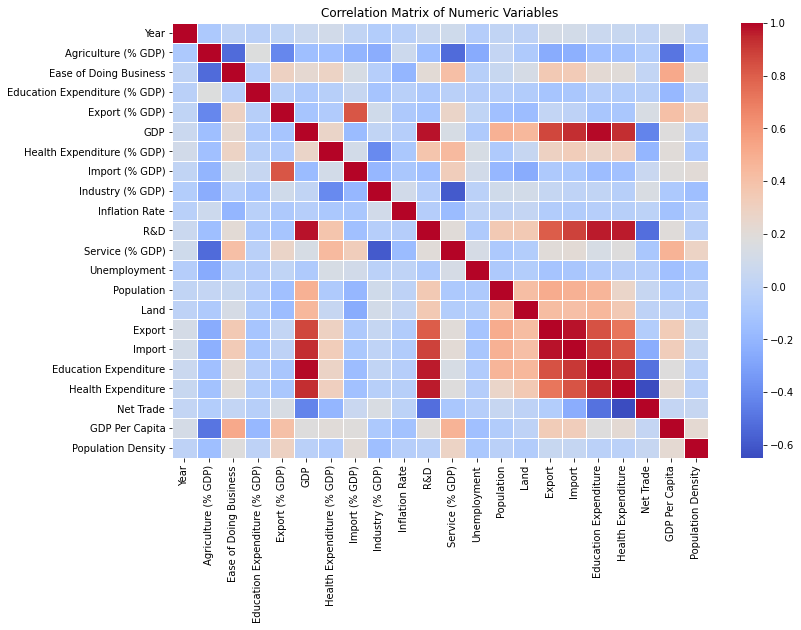


DISTRIBUTION ANALYSIS


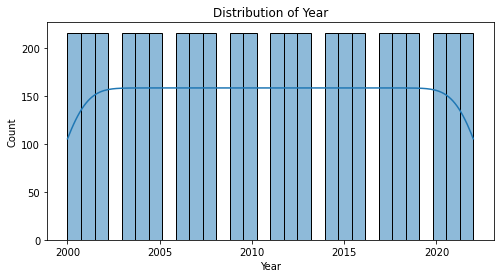

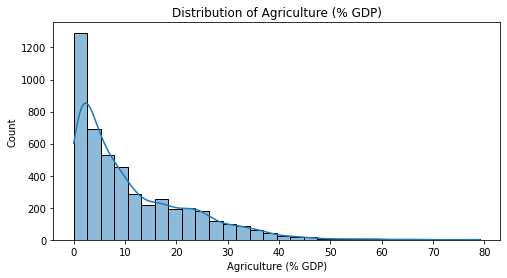

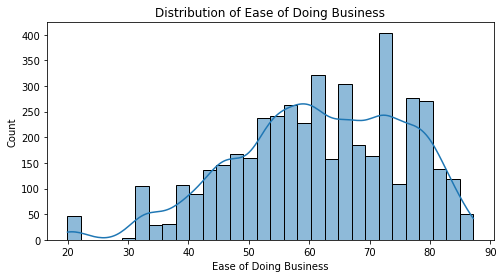

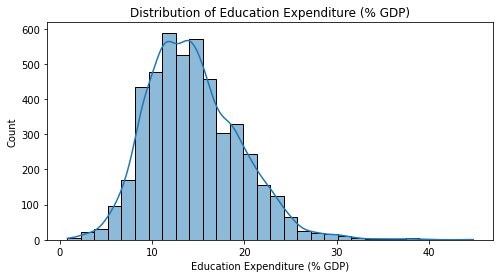

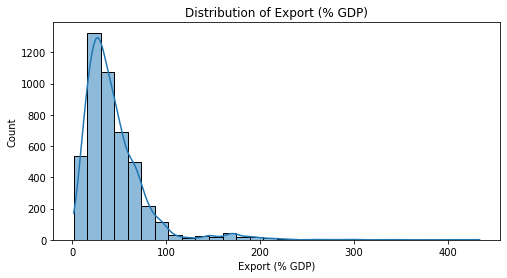

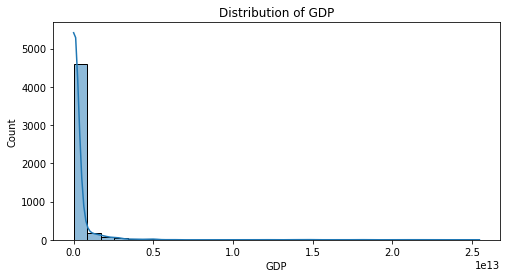

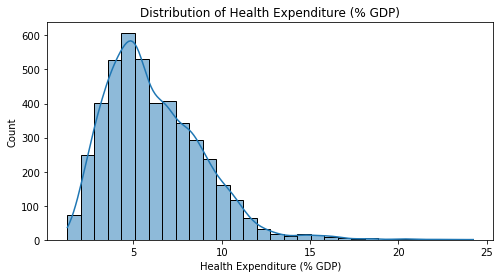

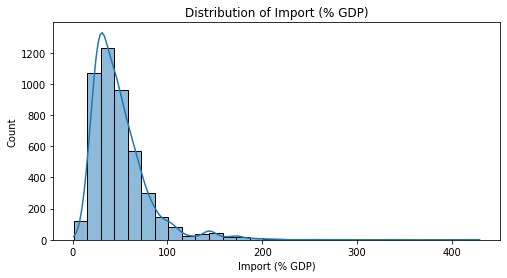

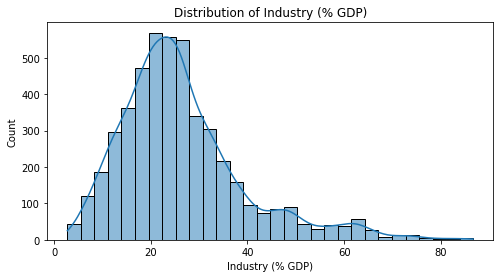

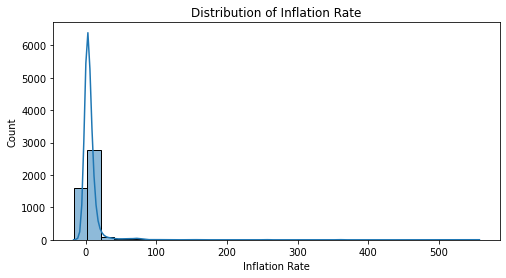

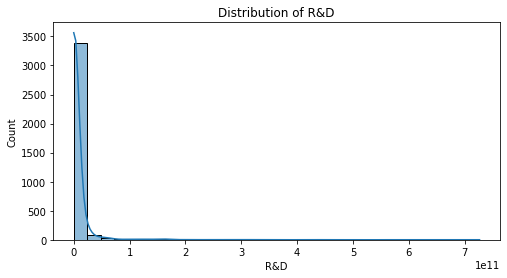

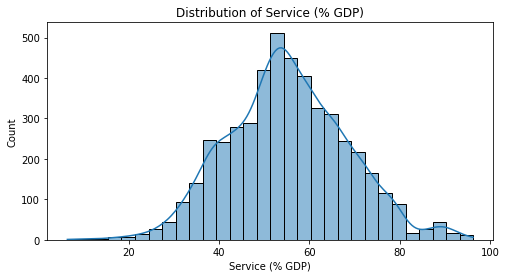

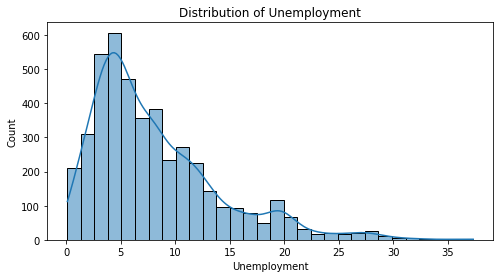

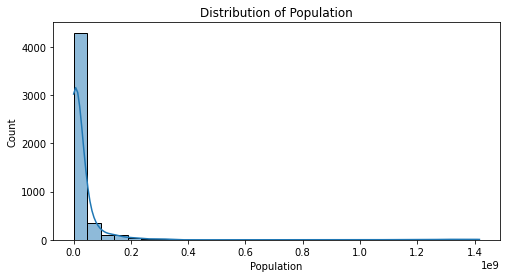

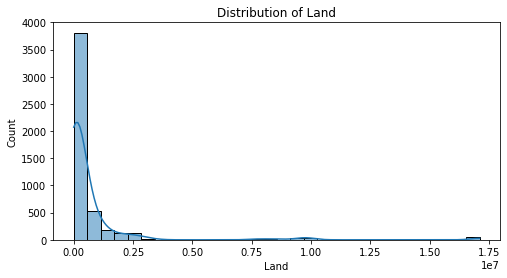

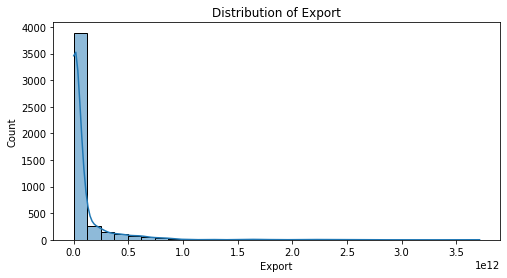

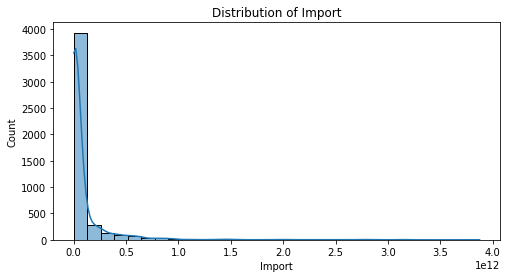

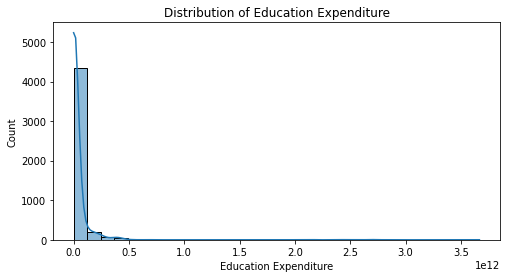

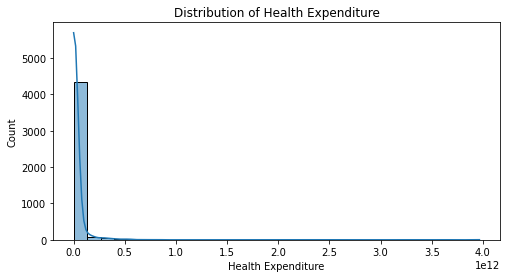

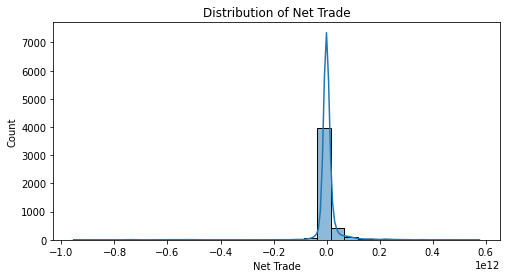

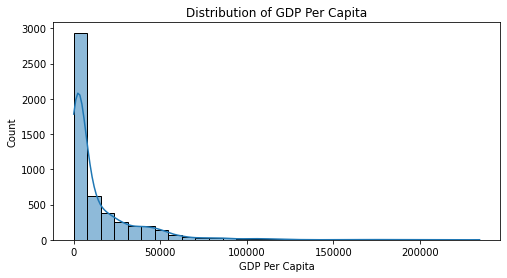

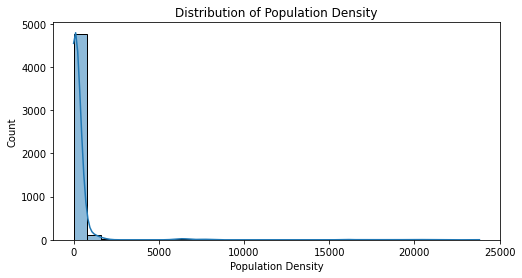


EDA COMPLETE ✅
Ready for Feature Engineering & Statistical Modeling


In [14]:
# =============================================================================
# WB_DF: EXPLORATORY DATA ANALYSIS (PRE-FEATURE ENGINEERING)
# This step occurs AFTER data cleaning
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# -----------------------------------------------------------------------------
# NUMERIC COLUMN PREPARATION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("NUMERIC COLUMN PREPARATION")
print("=" * 80)

# Automatically detect numeric columns directly from wb_df
numeric_cols = wb_df.select_dtypes(include=np.number).columns.tolist()

print("\nNumeric Columns Detected:")
print(numeric_cols)

# Safely convert (only if column exists)
for col in numeric_cols:
    if col in wb_df.columns:
        wb_df[col] = pd.to_numeric(wb_df[col], errors='coerce')


# -----------------------------------------------------------------------------
# DATA COVERAGE
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DATA COVERAGE")
print("=" * 80)

if 'Year' in wb_df.columns:
    print(f"Year Range: {wb_df['Year'].min()} - {wb_df['Year'].max()}")
    print(f"Total Years: {wb_df['Year'].nunique()}")

if 'Country Name' in wb_df.columns:
    print(f"Total Countries: {wb_df['Country Name'].nunique()}")
    print(f"Total Observations: {len(wb_df):,}")


# -----------------------------------------------------------------------------
# DESCRIPTIVE STATISTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

if numeric_cols:
    display(wb_df[numeric_cols].describe().T)
else:
    print("No numeric columns detected.")


# -----------------------------------------------------------------------------
# CORRELATION ANALYSIS
# -----------------------------------------------------------------------------
if len(numeric_cols) > 1:
    print("\n" + "=" * 80)
    print("CORRELATION MATRIX")
    print("=" * 80)

    corr_matrix = wb_df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Matrix of Numeric Variables")
    plt.show()


# -----------------------------------------------------------------------------
# DISTRIBUTION ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(wb_df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


print("\n" + "=" * 80)
print("EDA COMPLETE ✅")
print("Ready for Feature Engineering & Statistical Modeling")
print("=" * 80)


### Startup Funding Dataset (SF_DF) – Pre-Feature Engineering EDA

This cell performs exploratory analysis on the startup ecosystem dataset, focusing on funding dynamics, firm status, and structural characteristics.

#### Numeric Column Preparation

All numeric startup-related variables (e.g., funding amounts, funding rounds, founding year) are standardized and validated for numerical consistency.

#### Data Coverage Assessment

The dataset is examined for:

* Founded year range
* Total number of companies
* Total regions represented

This confirms adequate ecosystem representation across time and geography.

#### Descriptive Statistics

Statistical summaries are computed for funding variables and related quantitative metrics to assess:

* Average funding levels
* Funding dispersion
* Scale differences across variables

#### Correlation Analysis

A correlation matrix evaluates relationships among financial variables, such as:

* Funding rounds vs. total funding
* Round-specific capital vs. total capital

This helps detect redundancy and informs dimensionality reduction strategies.

#### Status Distribution Analysis

The distribution of company status (e.g., operating, acquired, closed) is examined to:

* Understand class balance
* Prepare for potential classification modeling
* Identify survival patterns

#### Funding Metrics by Company Status

Mean, median, and total funding metrics are computed by company status. This provides insight into:

* Whether higher funding correlates with survival
* Differences in funding structures across outcome categories

#### Distribution Analysis

Histograms assess skewness and capital concentration patterns, which are common in venture datasets.

#### Market and Regional Insights

Top markets and regions are identified by:

* Total funding volume
* Company count

This reveals ecosystem concentration and geographic investment patterns.


This structured exploratory analysis provides a solid empirical foundation for the subsequent stages.


EXPLORATORY DATA ANALYSIS (EDA)

NUMERIC COLUMN PREPARATION

Numeric Columns Detected:
['funding_rounds', 'founded_year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

DATA COVERAGE
Founded Year Range: 1902.0 - 2014.0
Total Unique Founded Years: 103
Total Companies: 49,350
Total Observations: 54,294
Total Regions: 1089

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
funding_rounds,49438.0,1.696205e+00,1.294213e+00,1.0,1.0,1.0,2.0,1.800000e+01
founded_year,38482.0,2.007359e+03,7.579203e+00,1902.0,2006.0,2010.0,2012.0,2.014000e+03
seed,49438.0,2.173215e+05,1.056985e+06,0.0,0.0,0.0,25000.0,1.300000e+08
venture,49438.0,7.501051e+06,2.847112e+07,0.0,0.0,0.0,5000000.0,2.351000e+09
equity_crowdfunding,49438.0,6.163322e+03,1.999048e+05,0.0,0.0,0.0,0.0,2.500000e+07
undisclosed,49438.0,1.302213e+05,2.981404e+06,0.0,0.0,0.0,0.0,2.924328e+08
convertible_note,49438.0,2.336410e+04,1.432046e+06,0.0,0.0,0.0,0.0,3.000000e+08
debt_financing,49438.0,1.888157e+06,1.382046e+08,0.0,0.0,0.0,0.0,3.007950e+10
angel,49438.0,6.541898e+04,6.582908e+05,0.0,0.0,0.0,0.0,6.359026e+07
grant,49438.0,1.628453e+05,5.612088e+06,0.0,0.0,0.0,0.0,7.505000e+08



CORRELATION MATRIX


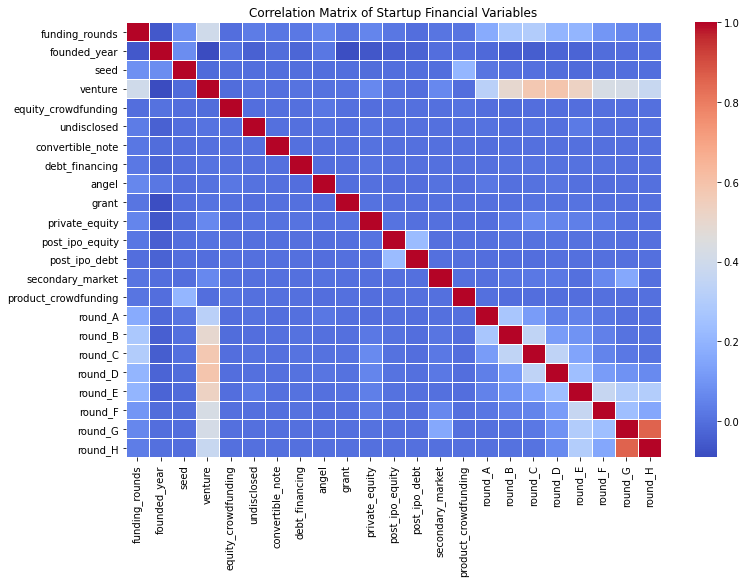


COMPANY STATUS DISTRIBUTION


operating    41829
acquired      3692
closed        2603
Name: status, dtype: int64


Number of Companies by Status:


status
acquired      3691
closed        2602
operating    41762
Name: name, dtype: int64


FUNDING METRICS BY COMPANY STATUS

Mean Funding Metrics:


...


Median Funding Metrics:


status,acquired,closed,operating
funding_rounds,2.0,1.0,1.0
seed,0.0,0.0,0.0
venture,5000000.0,0.0,0.0
equity_crowdfunding,0.0,0.0,0.0
undisclosed,0.0,0.0,0.0
convertible_note,0.0,0.0,0.0
debt_financing,0.0,0.0,0.0
angel,0.0,0.0,0.0
grant,0.0,0.0,0.0
private_equity,0.0,0.0,0.0



Total Funding Metrics:


status,acquired,closed,operating
funding_rounds,7.435000e+03,3.733000e+03,7.067100e+04
seed,6.585308e+08,3.683325e+08,9.517305e+09
venture,5.115343e+10,1.356749e+10,3.009296e+11
equity_crowdfunding,8.883057e+06,0.000000e+00,2.921749e+08
undisclosed,5.758979e+08,9.715853e+07,5.455188e+09
convertible_note,2.371484e+07,2.635356e+07,1.082456e+09
debt_financing,7.033715e+09,1.630271e+09,8.321657e+10
angel,2.465479e+08,1.907633e+08,2.741604e+09
grant,9.490263e+07,1.524594e+08,7.579363e+09
private_equity,9.738953e+09,1.451440e+09,8.906859e+10



DISTRIBUTION ANALYSIS


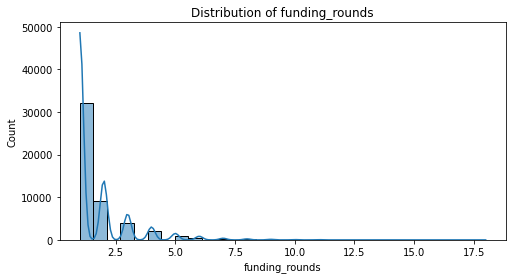

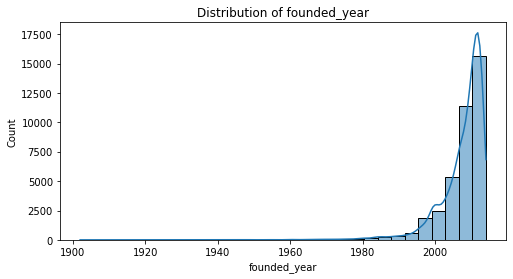

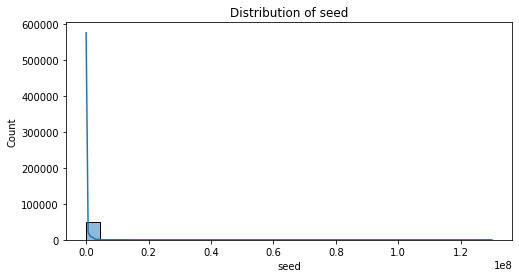

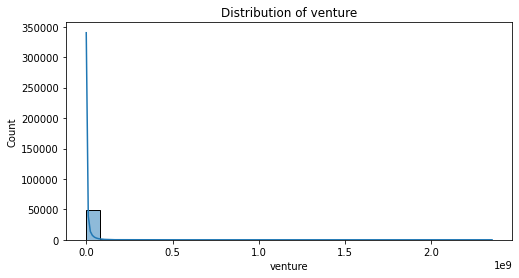

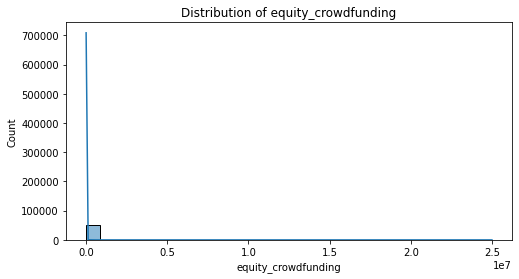

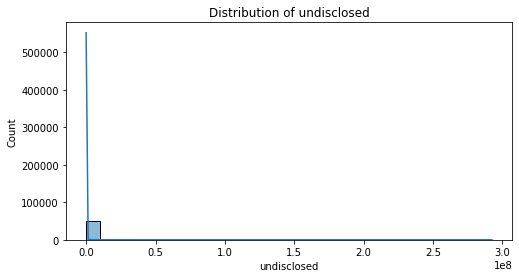

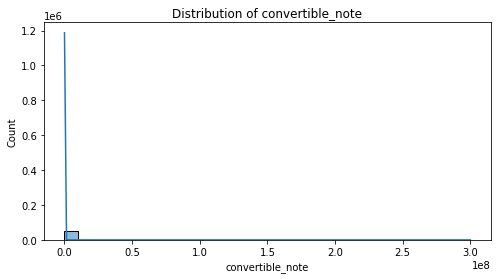

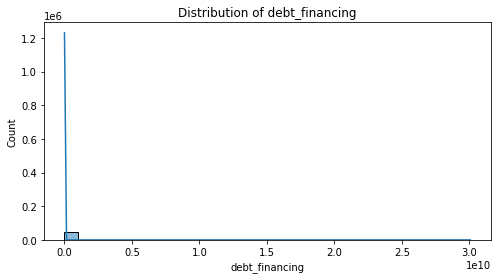

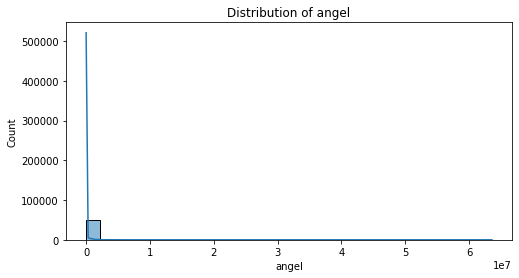

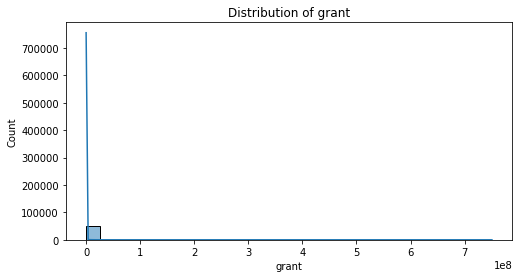

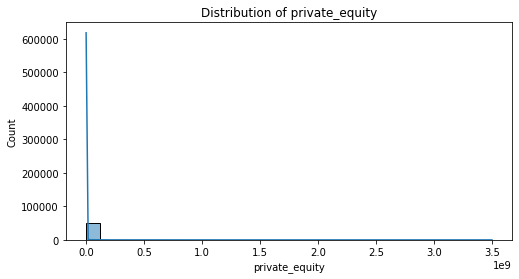

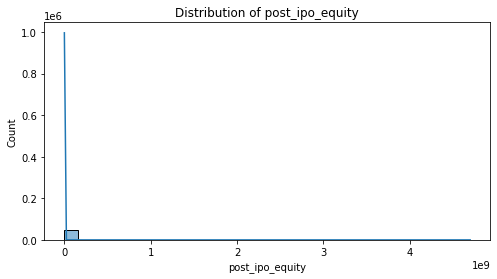

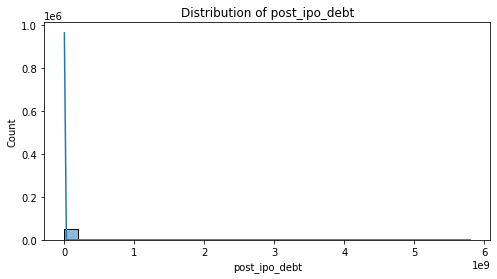

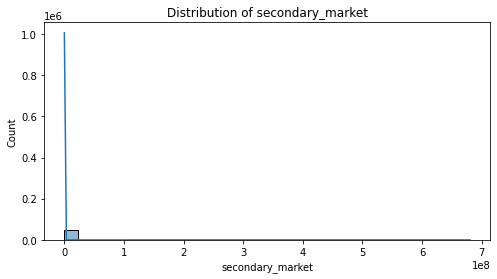

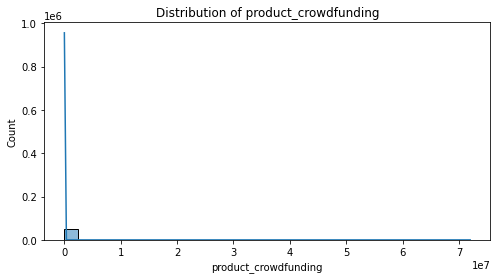

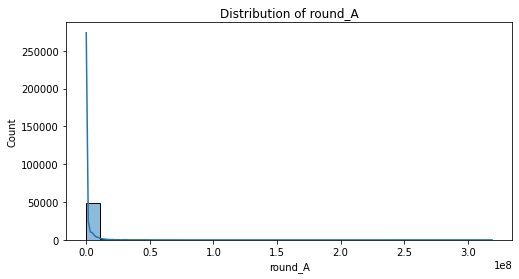

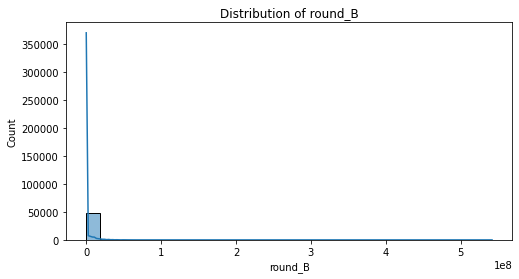

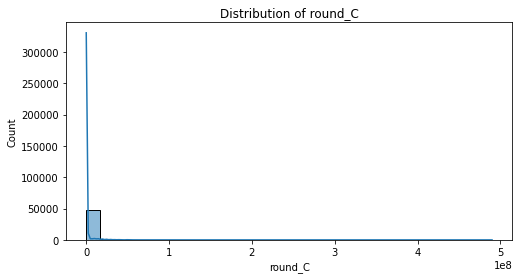

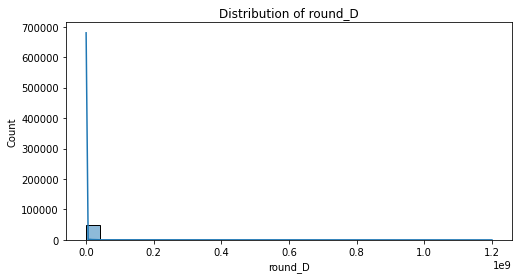

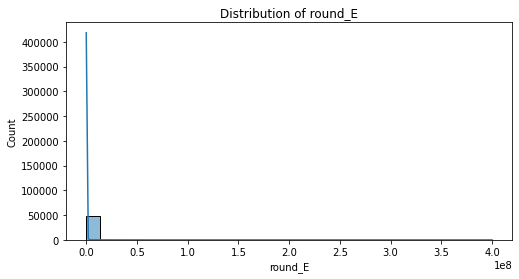

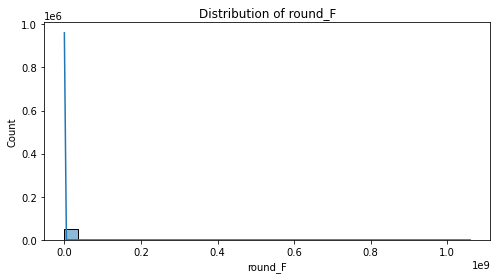

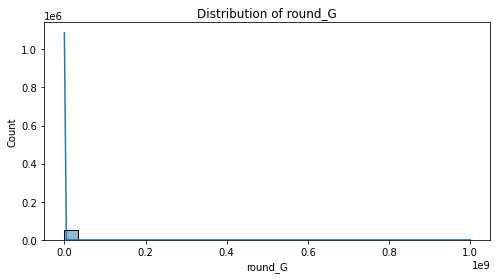

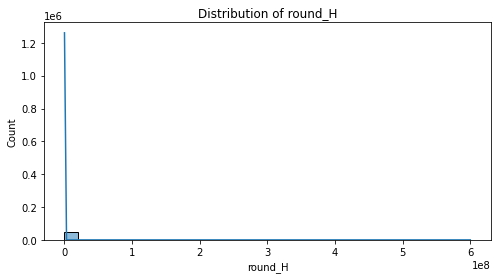


TOP REGIONS BY COMPANY COUNT


region
SF Bay Area         6804
New York City       2577
Boston              1837
London              1588
Los Angeles         1389
Seattle              932
Washington, D.C.     785
Chicago              749
San Diego            700
Denver               636
Name: name, dtype: int64


EDA COMPLETE ✅
Ready for Feature Engineering & Statistical Modeling


In [15]:
# =============================================================================
# SF_DF: EXPLORATORY DATA ANALYSIS (PRE-FEATURE ENGINEERING)
# This step occurs AFTER data cleaning
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)


# -----------------------------------------------------------------------------
# NUMERIC COLUMN PREPARATION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("NUMERIC COLUMN PREPARATION")
print("=" * 80)

# Automatically detect numeric columns
numeric_cols = sf_df.select_dtypes(include=np.number).columns.tolist()

# Convert safely to numeric (ensures consistency)
for col in numeric_cols:
    sf_df[col] = pd.to_numeric(sf_df[col], errors='coerce')

print("\nNumeric Columns Detected:")
print(numeric_cols)


# -----------------------------------------------------------------------------
# DATA COVERAGE
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DATA COVERAGE")
print("=" * 80)

if 'founded_year' in sf_df.columns:
    print(f"Founded Year Range: {sf_df['founded_year'].min()} - {sf_df['founded_year'].max()}")
    print(f"Total Unique Founded Years: {sf_df['founded_year'].nunique()}")

if 'name' in sf_df.columns:
    print(f"Total Companies: {sf_df['name'].nunique():,}")
    print(f"Total Observations: {len(sf_df):,}")

if 'region' in sf_df.columns:
    print(f"Total Regions: {sf_df['region'].nunique()}")


# -----------------------------------------------------------------------------
# DESCRIPTIVE STATISTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

display(sf_df[numeric_cols].describe().T)


# -----------------------------------------------------------------------------
# CORRELATION ANALYSIS
# -----------------------------------------------------------------------------
if len(numeric_cols) > 1:
    print("\n" + "=" * 80)
    print("CORRELATION MATRIX")
    print("=" * 80)

    corr_matrix = sf_df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Matrix of Startup Financial Variables")
    plt.show()


# -----------------------------------------------------------------------------
# STATUS DISTRIBUTION ANALYSIS
# -----------------------------------------------------------------------------
if 'status' in sf_df.columns:
    print("\n" + "=" * 80)
    print("COMPANY STATUS DISTRIBUTION")
    print("=" * 80)

    display(sf_df['status'].value_counts())

    if 'name' in sf_df.columns:
        print("\nNumber of Companies by Status:")
        display(sf_df.groupby('status')['name'].nunique())


# -----------------------------------------------------------------------------
# FUNDING METRICS BY STATUS
# -----------------------------------------------------------------------------
funding_cols = [
    'funding_total_usd', 'funding_rounds', 'seed', 'venture',
    'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
    'product_crowdfunding', 'round_A', 'round_B', 'round_C',
    'round_D', 'round_E', 'round_F', 'round_G', 'round_H'
]

existing_funding_cols = [col for col in funding_cols if col in sf_df.columns]

if 'status' in sf_df.columns and existing_funding_cols:
    print("\n" + "=" * 80)
    print("FUNDING METRICS BY COMPANY STATUS")
    print("=" * 80)

    grouped_mean = sf_df.groupby('status')[existing_funding_cols].mean().T
    print("\nMean Funding Metrics:")
    display(grouped_mean)

    grouped_median = sf_df.groupby('status')[existing_funding_cols].median().T
    print("\nMedian Funding Metrics:")
    display(grouped_median)

    grouped_sum = sf_df.groupby('status')[existing_funding_cols].sum().T
    print("\nTotal Funding Metrics:")
    display(grouped_sum)


# -----------------------------------------------------------------------------
# DISTRIBUTION ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(sf_df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


# -----------------------------------------------------------------------------
# MARKET & REGION INSIGHTS
# -----------------------------------------------------------------------------
if 'market' in sf_df.columns and 'funding_total_usd' in sf_df.columns:
    print("\n" + "=" * 80)
    print("TOP MARKETS BY TOTAL FUNDING")
    print("=" * 80)

    display(
        sf_df.groupby('market')['funding_total_usd']
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

if 'region' in sf_df.columns and 'name' in sf_df.columns:
    print("\n" + "=" * 80)
    print("TOP REGIONS BY COMPANY COUNT")
    print("=" * 80)

    display(
        sf_df.groupby('region')['name']
        .count()
        .sort_values(ascending=False)
        .head(10)
    )


print("\n" + "=" * 80)
print("EDA COMPLETE ✅")
print("Ready for Feature Engineering & Statistical Modeling")
print("=" * 80)


### Global Workforce & Skills Dataset

This section presents the **Exploratory Data Analysis (EDA)** conducted on the Global Workforce dataset. This step occurs **after data cleaning and before feature engineering, statistical modeling, and visualization refinement**.

The objective is to understand workforce dynamics, skills distribution, and temporal trends in AI-related employment indicators.

#### Structure Assessment

The initial stage provides a structural overview of the dataset, including:

* Dataset shape (rows × columns)
* Full list of variables
* Missing value counts per column
* Number of zero values per variable
* Unique value counts per feature

This step ensures data integrity and helps identify:

* Sparse variables
* Categorical vs numeric variables
* Columns requiring transformation
* Potential imbalance issues

---

#### Numeric Column Preparation

All numeric columns (integer and float types) are:

* Automatically detected
* Explicitly converted to numeric format (with coercion for invalid entries)

This ensures compatibility with statistical analysis and prevents type-related errors in modeling stages.

A preview of numeric columns is displayed to verify:

* Proper formatting
* Absence of parsing issues
* Logical value ranges

#### Descriptive Statistical Analysis

Summary statistics are computed for all numeric variables, including:

* Mean
* Standard deviation
* Minimum and maximum values
* Quartiles (25%, 50%, 75%)

This analysis provides insight into:

* Central tendencies in workforce metrics
* Variability across years
* Presence of extreme values or outliers
* Distribution skewness

These insights are essential for determining whether scaling, normalization, or transformation is required before modeling.

#### Temporal Distribution Analysis

If a `year` variable exists, its distribution is visualized to assess:

* Time coverage span
* Data density across years
* Potential gaps in reporting

This ensures sufficient longitudinal coverage for trend analysis and forecasting applications.

#### Skill Frequency Analysis

The most frequently occurring skills are identified using value counts.

This step helps:

* Detect dominant AI or digital skills
* Identify specialization patterns
* Understand workforce demand concentration

It also supports later feature engineering tasks such as skill clustering or index construction.

#### Skill Trends Over Time

For the top five most frequent skills, line plots are generated to analyze:

* Growth patterns over time
* Emerging vs declining skills
* Workforce transformation dynamics

This temporal skill analysis provides insight into:

* AI skill diffusion
* Labor market adaptation
* Structural workforce shifts

The exploratory analysis establishes:

* Workforce data reliability
* Temporal consistency
* Skill concentration patterns
* Evolution of AI-related competencies



EXPLORATORY DATA ANALYSIS (EDA)

NUMERIC COLUMN PREPARATION

Numeric Columns Detected:
['Year', 'AI_Investment_BillionUSD', 'Automation_Rate_Percent', 'Employment_Rate_Percent', 'Average_Salary_USD', 'Productivity_Index', 'Reskilling_Investment_MillionUSD', 'AI_Policy_Index', 'Job_Displacement_Million', 'Job_Creation_Million', 'AI_Readiness_Score']

DATA COVERAGE
Total Observations: 220

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Year,220.0,2020.000000,3.169489,2015.00,2017.0000,2020.000,2023.0000,2025.00
AI_Investment_BillionUSD,220.0,82.364409,42.522535,5.40,47.6425,81.375,114.4800,177.29
Automation_Rate_Percent,220.0,27.352136,8.860064,10.19,20.3375,27.085,33.8125,48.41
Employment_Rate_Percent,220.0,68.818909,5.833969,57.12,63.9625,68.800,73.7525,79.95
Average_Salary_USD,220.0,62074.483818,19472.117474,26787.83,45251.7900,60828.005,75538.9975,117335.31
Productivity_Index,220.0,60.614500,11.093930,40.40,51.8325,59.005,69.6775,87.26
Reskilling_Investment_MillionUSD,220.0,939.959682,522.835431,141.24,520.2075,881.575,1278.6850,2371.55
AI_Policy_Index,220.0,0.604500,0.164123,0.18,0.4800,0.620,0.7225,1.00
Job_Displacement_Million,220.0,0.365636,0.220901,0.02,0.1875,0.350,0.5200,1.01
Job_Creation_Million,220.0,1.247773,1.019043,0.03,0.4300,0.935,1.7400,4.95



CORRELATION MATRIX


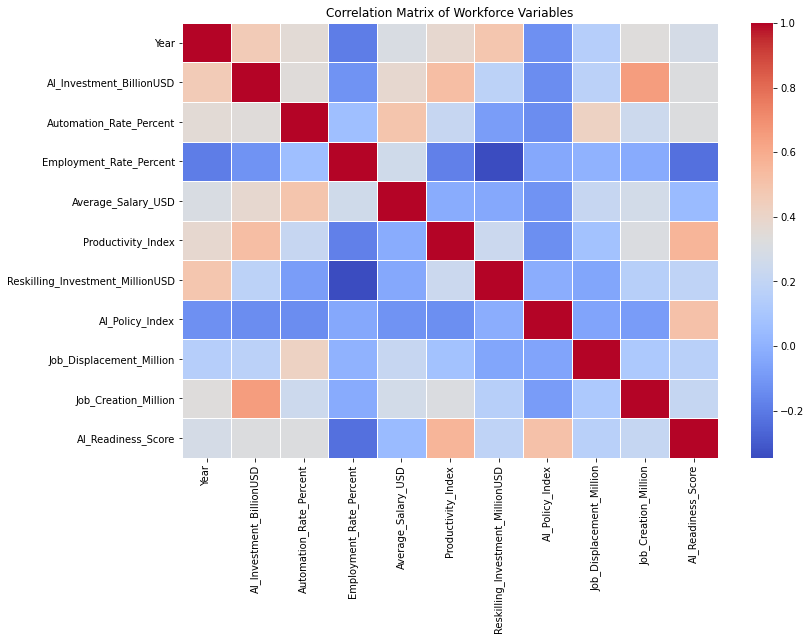


DISTRIBUTION ANALYSIS


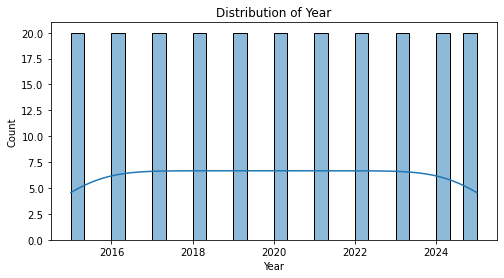

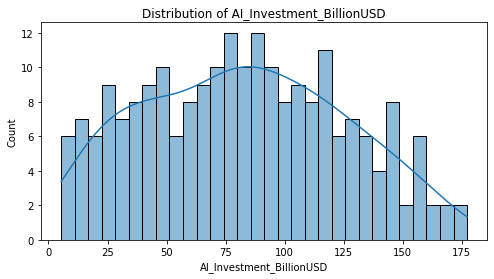

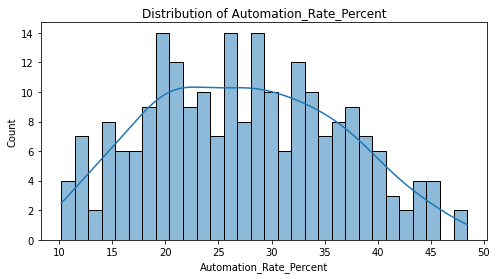

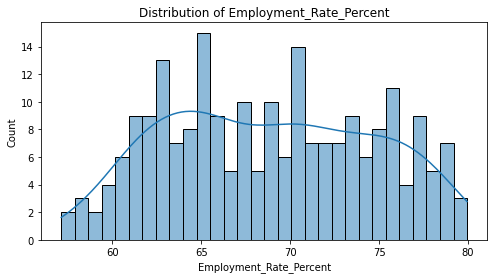

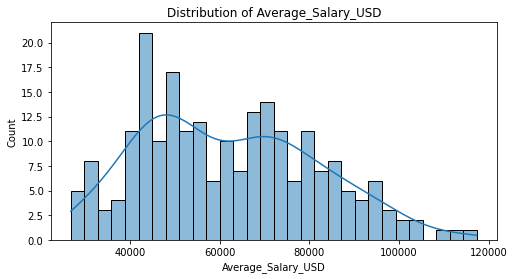

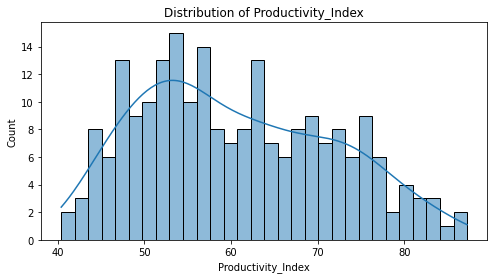

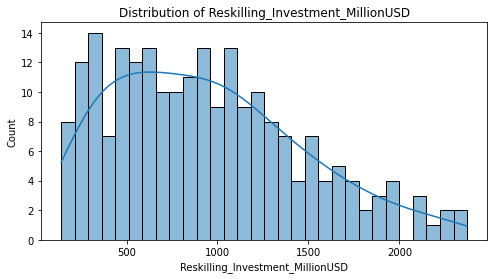

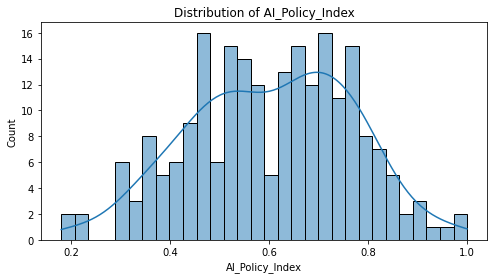

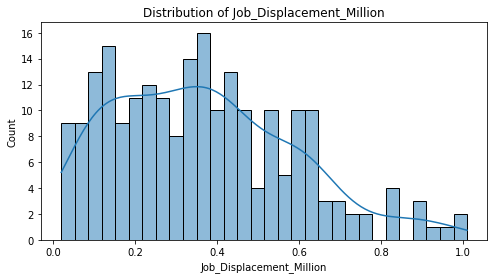

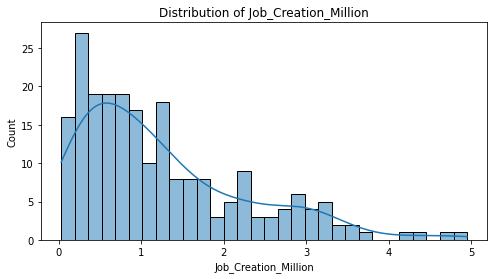

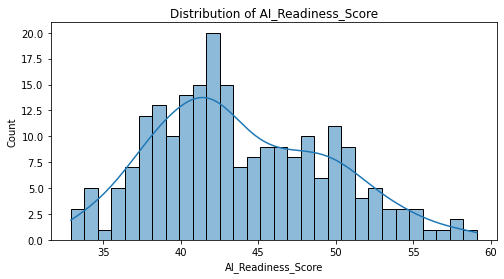


EDA COMPLETE ✅
Ready for Feature Engineering & Statistical Modeling


In [16]:
# =============================================================================
#  EXPLORATORY DATA ANALYSIS 
# This step occurs AFTER data cleaning
# =============================================================================


print("=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)


# -----------------------------------------------------------------------------
# NUMERIC COLUMN PREPARATION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("NUMERIC COLUMN PREPARATION")
print("=" * 80)

# Automatically detect numeric columns
numeric_cols = gw_df.select_dtypes(include=np.number).columns.tolist()

# Convert safely to numeric (ensures consistency)
for col in numeric_cols:
    gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce')

print("\nNumeric Columns Detected:")
print(numeric_cols)


# -----------------------------------------------------------------------------
# DATA COVERAGE
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DATA COVERAGE")
print("=" * 80)

if 'year' in gw_df.columns:
    print(f"Year Range: {gw_df['year'].min()} - {gw_df['year'].max()}")
    print(f"Total Unique Years: {gw_df['year'].nunique()}")

if 'skill' in gw_df.columns:
    print(f"Total Unique Skills: {gw_df['skill'].nunique()}")

print(f"Total Observations: {len(gw_df):,}")


# -----------------------------------------------------------------------------
# DESCRIPTIVE STATISTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

if numeric_cols:
    display(gw_df[numeric_cols].describe().T)


# -----------------------------------------------------------------------------
# CORRELATION ANALYSIS
# -----------------------------------------------------------------------------
if len(numeric_cols) > 1:
    print("\n" + "=" * 80)
    print("CORRELATION MATRIX")
    print("=" * 80)

    corr_matrix = gw_df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Matrix of Workforce Variables")
    plt.show()


# -----------------------------------------------------------------------------
# SKILL DISTRIBUTION ANALYSIS
# -----------------------------------------------------------------------------
if 'skill' in gw_df.columns:
    print("\n" + "=" * 80)
    print("SKILL DISTRIBUTION")
    print("=" * 80)

    display(gw_df['skill'].value_counts())

    print("\nTop 10 Skills:")
    display(gw_df['skill'].value_counts().head(10))


# -----------------------------------------------------------------------------
# SKILL TRENDS BY YEAR
# -----------------------------------------------------------------------------
if 'year' in gw_df.columns and 'skill' in gw_df.columns:
    print("\n" + "=" * 80)
    print("SKILL TRENDS BY YEAR")
    print("=" * 80)

    top_skills = gw_df['skill'].value_counts().head(5).index

    trend_df = (
        gw_df[gw_df['skill'].isin(top_skills)]
        .groupby(['year', 'skill'])
        .size()
        .reset_index(name='count')
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=trend_df, x='year', y='count', hue='skill')
    plt.title("Top 5 Skills Trends Over Time")
    plt.xlabel("Year")
    plt.ylabel("Skill Frequency")
    plt.legend(title="Skill")
    plt.show()


# -----------------------------------------------------------------------------
# DISTRIBUTION ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(gw_df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


print("\n" + "=" * 80)
print("EDA COMPLETE ✅")
print("Ready for Feature Engineering & Statistical Modeling")
print("=" * 80)


## Feature Engineering

### World Bank Dataset

This step enhances the cleaned `wb_df` dataset by creating economically meaningful and model-ready variables.

First, a snapshot of available columns is displayed to verify dataset structure and prevent referencing missing variables. A predefined list of important economic indicators (GDP, GDP Per Capita, Inflation, Trade, Sector shares, R&D, Population metrics) is then filtered to keep only those that actually exist in the dataset. These columns are safely converted to numeric format using `errors='coerce'` to avoid errors and ensure consistency.

Next, several engineered features are created:

- **Log GDP per Capita (`log_gdp_per_capita`)**: Applies a log(1 + x) transformation to reduce skewness and improve regression performance.
- **Trade Balance Ratio (`trade_balance_ratio`)**: Measures export strength relative to imports (Export % GDP / Import % GDP), serving as a proxy for trade competitiveness.
- **Sector Diversity Index (`sector_diversity`)**: Counts how many economic sectors (Agriculture, Industry, Services) contribute positively to GDP, capturing structural diversification.
- **Log Population Density (`log_population_density`)**: Reduces skewness in population density data.
- **High-Income Indicator (`high_income`)**: A binary variable set to 1 if GDP per capita is above the dataset median, enabling classification and segmentation analysis.

Finally, the engineered features are previewed and summarized using descriptive statistics to confirm successful transformation.

Overall, this step improves interpretability, reduces skewness, introduces structural economic indicators, and prepares the dataset for statistical modeling and machine learning.


In [17]:
# ============================================
# FEATURE ENGINEERING — WORLD BANK DATASET 
# ============================================

import numpy as np
import pandas as pd

print("=" * 70)
print("FEATURE ENGINEERING: WORLD BANK DATASET")
print("=" * 70)

# --------------------------------------------
#  Snapshot of available columns
# --------------------------------------------
print("\nAvailable columns (first 25):")
display(wb_df.columns[:25])

# --------------------------------------------
#  Numeric Columns (auto-detect & convert)
# --------------------------------------------
numeric_cols = [
    'GDP', 'GDP Per Capita', 'Inflation Rate',
    'Health Expenditure (% GDP)', 'Education Expenditure (% GDP)',
    'Export (% GDP)', 'Import (% GDP)', 'Net Trade',
    'Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)',
    'R&D', 'Population', 'Population Density'
]

numeric_cols_existing = [col for col in numeric_cols if col in wb_df.columns]

# Safe conversion
wb_df[numeric_cols_existing] = wb_df[numeric_cols_existing].apply(
    pd.to_numeric, errors='coerce'
)

print("\n Converted numeric columns:")
print(numeric_cols_existing)

# --------------------------------------------
# GDP per Capita Log
# --------------------------------------------
if 'GDP Per Capita' in wb_df.columns:
    wb_df['log_gdp_per_capita'] = np.log1p(wb_df['GDP Per Capita'])
else:
    wb_df['log_gdp_per_capita'] = np.nan

# --------------------------------------------
# Economic Complexity: Exports vs Imports
# --------------------------------------------
if {'Export (% GDP)', 'Import (% GDP)'}.issubset(wb_df.columns):
    wb_df['trade_balance_ratio'] = (
        wb_df['Export (% GDP)'] / (wb_df['Import (% GDP)'] + 1e-6)
    )
else:
    wb_df['trade_balance_ratio'] = np.nan

# --------------------------------------------
# Sector Diversity Index
# --------------------------------------------
sector_cols = ['Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)']
existing_sector_cols = [c for c in sector_cols if c in wb_df.columns]

if existing_sector_cols:
    wb_df['sector_diversity'] = wb_df[existing_sector_cols].gt(0).sum(axis=1)
else:
    wb_df['sector_diversity'] = np.nan

# --------------------------------------------
# Population Density Log
# --------------------------------------------
if 'Population Density' in wb_df.columns:
    wb_df['log_population_density'] = np.log1p(wb_df['Population Density'])
else:
    wb_df['log_population_density'] = np.nan

# --------------------------------------------
# Country Income Indicator (high vs low)
# --------------------------------------------
if 'GDP Per Capita' in wb_df.columns:
    wb_df['high_income'] = (wb_df['GDP Per Capita'] > wb_df['GDP Per Capita'].median()).astype(int)
else:
    wb_df['high_income'] = 0

# --------------------------------------------
# Final Feature Preview
# --------------------------------------------
engineered_features_wb = [
    'GDP', 'GDP Per Capita', 'log_gdp_per_capita',
    'Inflation Rate', 'Health Expenditure (% GDP)',
    'Education Expenditure (% GDP)', 'Export (% GDP)',
    'Import (% GDP)', 'trade_balance_ratio', 'sector_diversity',
    'R&D', 'Population', 'Population Density', 'log_population_density',
    'high_income'
]

print("\nEngineered feature preview:")
display(wb_df[engineered_features_wb].head())

print("\nFeature summary:")
display(wb_df[engineered_features_wb].describe())

print("\n Feature engineering for wb_df completed successfully.")


FEATURE ENGINEERING: WORLD BANK DATASET

Available columns (first 25):


Index(['Country Name', 'Country Code', 'Year', 'Agriculture (% GDP)',
       'Ease of Doing Business', 'Education Expenditure (% GDP)',
       'Export (% GDP)', 'GDP', 'Health Expenditure (% GDP)', 'Import (% GDP)',
       'Industry (% GDP)', 'Inflation Rate', 'R&D', 'Service (% GDP)',
       'Unemployment', 'Population', 'Land', 'Continent Name', 'Export',
       'Import', 'Education Expenditure', 'Health Expenditure', 'Net Trade',
       'GDP Per Capita', 'Population Density'],
      dtype='object')


 Converted numeric columns:
['GDP', 'GDP Per Capita', 'Inflation Rate', 'Health Expenditure (% GDP)', 'Education Expenditure (% GDP)', 'Export (% GDP)', 'Import (% GDP)', 'Net Trade', 'Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)', 'R&D', 'Population', 'Population Density']

Engineered feature preview:


,GDP,GDP Per Capita,log_gdp_per_capita,Inflation Rate,Health Expenditure (% GDP),Education Expenditure (% GDP),Export (% GDP),Import (% GDP),trade_balance_ratio,sector_diversity,R&D,Population,Population Density,log_population_density,high_income
0,1.415197e+10,724.145910,6.586373,6.12462,10.902580,13.670101,NaN,NaN,NaN,3,NaN,19542982.0,29.934415,3.431869,0
1,1.415197e+10,718.788917,6.578958,6.12462,10.902580,13.670101,NaN,NaN,NaN,3,NaN,19688632.0,30.157510,3.439055,0
2,3.854235e+09,183.532775,5.217827,6.12462,9.443391,13.670101,NaN,NaN,NaN,3,NaN,21000256.0,32.166553,3.501542,0
3,4.539497e+09,200.462376,5.305603,6.12462,8.941258,13.670101,NaN,NaN,NaN,3,NaN,22645130.0,34.686043,3.574760,0
4,5.220825e+09,221.657662,5.405635,6.12462,9.808474,13.670101,NaN,NaN,NaN,3,NaN,23553551.0,36.077491,3.613010,0



Feature summary:


,GDP,GDP Per Capita,log_gdp_per_capita,Inflation Rate,Health Expenditure (% GDP),Education Expenditure (% GDP),Export (% GDP),Import (% GDP),trade_balance_ratio,sector_diversity,R&D,Population,Population Density,log_population_density,high_income
count,4.968000e+03,4968.000000,4968.000000,4554.000000,4531.000000,4692.000000,4646.000000,4646.000000,4646.000000,4968.000000,3.588000e+03,4.968000e+03,4968.000000,4968.000000,4968.00000
mean,3.163072e+11,14515.028679,8.558412,6.991400,6.167133,14.490385,44.018003,49.445204,0.920217,2.888889,8.469386e+09,3.362423e+07,324.412548,4.329940,0.50000
std,1.415205e+12,22064.632650,1.553051,19.858123,2.744570,4.990593,33.173984,30.474001,0.398671,0.524163,4.373749e+10,1.297822e+08,1580.728450,1.458612,0.50005
min,1.396473e+07,110.460875,4.713674,-16.859691,1.263576,0.833360,1.571162,1.127672,0.042845,0.000000,1.574855e+05,9.609000e+03,0.136492,0.127946,0.00000
25%,4.281246e+09,1530.176236,7.333791,1.599237,4.158750,10.920053,23.544736,29.401814,0.674417,3.000000,1.966543e+07,1.056758e+06,29.688535,3.423889,0.00000
50%,1.841204e+10,5252.941703,8.566733,3.466447,5.639608,14.002313,36.438987,42.543697,0.914107,3.000000,1.284085e+08,6.203438e+06,80.242106,4.397434,0.50000
75%,1.280049e+11,18727.844476,9.837820,7.288914,7.865923,17.633221,54.543771,60.600202,1.092157,3.000000,1.530285e+09,2.149857e+07,183.813760,5.219349,1.00000
max,2.546270e+13,234317.084818,12.364435,557.201817,24.230680,44.801800,433.836004,429.359095,3.696785,3.000000,7.266243e+11,1.417173e+09,23814.890701,10.078108,1.00000



 Feature engineering for wb_df completed successfully.


### Feature Engineering — Startup Funding Dataset

This feature engineering step prepares the startup funding dataset (`sf_df`) for predictive modeling by creating a clean target variable and multiple robust financial, structural, temporal, and geographic features, while ensuring stability against missing columns or inconsistent data formats.

The process begins by displaying a snapshot of the available columns (first 25) to verify dataset structure and confirm that required variables exist before transformations are applied.

The first major step is creating the target variable, `target_success`. This binary variable is derived from the `status` column. Startups labeled as **"operating"** or **"acquired"** are considered successful and assigned a value of 1, while all other outcomes (such as closed or inactive) are assigned 0. If the `status` column is missing, the pipeline raises an error to prevent silent failure. The distribution of this new target variable is then printed to inspect class balance.

Next, the pipeline handles total funding in a robust manner. Because startup datasets often use different naming conventions, the code searches for a valid funding column among multiple possible names (e.g., `funding_total_usd`, `total_funding_usd`, `raised_amount_usd`, `funding_total`). If none is found, a new column called `total_funding_usd` is safely created and initialized with 0. The selected funding column is then converted to numeric format using `errors='coerce'`, and missing values are filled with 0 to ensure consistency.

The number of funding rounds is then processed. If the `funding_rounds` column is missing, it is created with a default value of 1. All values are converted to numeric, and zeros are replaced with 1 to avoid division-by-zero errors in later calculations.

Using total funding and funding rounds, a new feature called `avg_funding_per_round` is calculated as:

`total_funding / funding_rounds`

This metric captures capital intensity per investment round and may indicate investor confidence or funding efficiency. Infinite values resulting from division are safely replaced with NaN.

The next engineered feature is `funding_diversity`. If funding-type columns such as seed, venture, angel, private equity, convertible note, debt financing, or grant exist, the model counts how many of these funding types have positive values for each startup. This produces a diversity index representing the breadth of funding sources. If none of these columns exist, the feature is set to 0 to maintain robustness.

Company maturity is captured through `company_age`. If `founded_year` is available, age is calculated as the difference between the current year and the founding year. Negative values are clipped at 0 to prevent invalid ages. If the column is missing, the feature is initialized as NaN and later filled using the dataset median to maintain numerical stability.

A geographic indicator, `is_us_based`, is then created. If the `country_code` column exists, startups located in the USA are assigned a value of 1, and all others receive 0. If the column is missing, the feature defaults to 0.

To address skewness in funding data, a log transformation is applied:

`log_total_funding = log(1 + total_funding)`

This transformation stabilizes variance, reduces the impact of extreme outliers, and improves performance in regression or classification models.

Finally, the engineered feature set is previewed and summarized using descriptive statistics. The final features include:

- Total funding
- Funding rounds
- Average funding per round
- Funding diversity
- Company age
- US-based indicator
- Log-transformed funding
- Target success variable

Overall, this pipeline ensures robustness against missing data, standardizes financial metrics, introduces structural and geographic indicators, reduces skewness in monetary variables, and produces a clean, model-ready dataset suitable for classification, regression, and startup success prediction tasks.


In [18]:
# ============================================
# FEATURE ENGINEERING — STARTUP FUNDING 
# ============================================

import numpy as np
import pandas as pd

print("=" * 70)
print("FEATURE ENGINEERING: STARTUP FUNDING DATASET (sf_df)")
print("=" * 70)

# --------------------------------------------
# 0. Snapshot of available columns
# --------------------------------------------
print("\nAvailable columns (first 25):")
display(sf_df.columns[:25])

# --------------------------------------------
# 1. Target Variable: Startup Success
# --------------------------------------------
if 'status' not in sf_df.columns:
    raise ValueError("❌ Required column 'status' not found")

sf_df['target_success'] = sf_df['status'].isin(
    ['operating', 'acquired']
).astype(int)

print("\nTarget variable distribution:")
print(sf_df['target_success'].value_counts())

# --------------------------------------------
# 2. Total Funding (create if missing)
# --------------------------------------------
possible_funding_cols = [
    'funding_total_usd',
    'total_funding_usd',
    'raised_amount_usd',
    'funding_total'
]

total_funding_col = next(
    (c for c in possible_funding_cols if c in sf_df.columns),
    None
)

# If none exists, CREATE one safely
if total_funding_col is None:
    print("⚠️ No total funding column found — creating 'total_funding_usd'")

    sf_df['total_funding_usd'] = 0.0
    total_funding_col = 'total_funding_usd'

# Ensure numeric
sf_df[total_funding_col] = pd.to_numeric(
    sf_df[total_funding_col], errors='coerce'
).fillna(0)

print(f"\nUsing total funding column: {total_funding_col}")

# --------------------------------------------
# 3. Funding Rounds (create if missing)
# --------------------------------------------
if 'funding_rounds' not in sf_df.columns:
    print("⚠️ 'funding_rounds' missing — creating with value 1")
    sf_df['funding_rounds'] = 1

sf_df['funding_rounds'] = pd.to_numeric(
    sf_df['funding_rounds'], errors='coerce'
).replace(0, 1)

# --------------------------------------------
# 4. Average Funding Per Round
# --------------------------------------------
sf_df['avg_funding_per_round'] = (
    sf_df[total_funding_col] / sf_df['funding_rounds']
).replace([np.inf, -np.inf], np.nan)

# --------------------------------------------
# 5. Funding Diversity (robust)
# --------------------------------------------
funding_type_cols = [
    'seed', 'venture', 'angel',
    'private_equity', 'convertible_note',
    'debt_financing', 'grant'
]

existing_funding_cols = [
    c for c in funding_type_cols if c in sf_df.columns
]

if existing_funding_cols:
    sf_df['funding_diversity'] = (
        sf_df[existing_funding_cols]
        .fillna(0)
        .gt(0)
        .sum(axis=1)
    )
else:
    print("⚠️ No funding-type columns found — funding_diversity set to 0")
    sf_df['funding_diversity'] = 0

# --------------------------------------------
# 6. Company Age (create safely)
# --------------------------------------------
if 'founded_year' in sf_df.columns:
    current_year = pd.Timestamp.now().year
    sf_df['company_age'] = (
        current_year - sf_df['founded_year']
    ).clip(lower=0)
else:
    print("⚠️ 'founded_year' missing — company_age set to median")
    sf_df['company_age'] = np.nan

sf_df['company_age'].fillna(
    sf_df['company_age'].median(), inplace=True
)

# --------------------------------------------
# 7. Geographic Indicator
# --------------------------------------------
if 'country_code' in sf_df.columns:
    sf_df['is_us_based'] = (sf_df['country_code'] == 'USA').astype(int)
else:
    sf_df['is_us_based'] = 0

# --------------------------------------------
# 8. Log-Scaled Funding (always safe)
# --------------------------------------------
sf_df['log_total_funding'] = np.log1p(sf_df[total_funding_col])

# --------------------------------------------
# 9. Final Feature Sanity Check
# --------------------------------------------
engineered_features = [
    total_funding_col,
    'funding_rounds',
    'avg_funding_per_round',
    'funding_diversity',
    'company_age',
    'is_us_based',
    'log_total_funding',
    'target_success'
]

print("\nEngineered feature preview:")
display(sf_df[engineered_features].head())

print("\nFeature summary:")
display(sf_df[engineered_features].describe())

print("\n Feature engineering completed successfully.")


FEATURE ENGINEERING: STARTUP FUNDING DATASET (sf_df)

Available columns (first 25):


Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel'],
      dtype='object')


Target variable distribution:
1    45521
0     8773
Name: target_success, dtype: int64
⚠️ No total funding column found — creating 'total_funding_usd'

Using total funding column: total_funding_usd

Engineered feature preview:


,total_funding_usd,funding_rounds,avg_funding_per_round,funding_diversity,company_age,is_us_based,log_total_funding,target_success
0,0.0,1.0,0.0,1,14.0,1,0.0,1
1,0.0,2.0,0.0,1,16.0,1,0.0,1
2,0.0,1.0,0.0,1,14.0,0,0.0,1
3,0.0,1.0,0.0,1,15.0,0,0.0,1
4,0.0,2.0,0.0,0,12.0,1,0.0,1



Feature summary:


,total_funding_usd,funding_rounds,avg_funding_per_round,funding_diversity,company_age,is_us_based,log_total_funding,target_success
count,54294.0,49438.000000,49438.0,54294.000000,54294.000000,54294.000000,54294.0,54294.000000
mean,0.0,1.696205,0.0,0.875658,17.871772,0.530316,0.0,0.838417
std,0.0,1.294213,0.0,0.665745,6.492623,0.499085,0.0,0.368071
min,0.0,1.000000,0.0,0.000000,12.000000,0.000000,0.0,0.000000
25%,0.0,1.000000,0.0,0.000000,15.000000,0.000000,0.0,1.000000
50%,0.0,1.000000,0.0,1.000000,16.000000,1.000000,0.0,1.000000
75%,0.0,2.000000,0.0,1.000000,19.000000,1.000000,0.0,1.000000
max,0.0,18.000000,0.0,6.000000,124.000000,1.000000,0.0,1.000000



 Feature engineering completed successfully.


### Feature Engineering — Global AI Job Skills Dataset

This feature engineering step enhances the Global AI Job Skills dataset (`gw_df`) by transforming raw economic and labor-market indicators into structured, model-ready variables while ensuring robustness against missing columns.

The process begins by displaying a snapshot of the first 20 available columns to verify dataset structure and confirm which indicators are present before applying transformations.

Next, a predefined list of expected numeric variables is created, including AI investment, automation rate, employment rate, salary, productivity, reskilling investment, policy index, job displacement, job creation, and AI readiness score. Since datasets may vary, only the columns that actually exist in `gw_df` are selected. These columns are safely converted to numeric format using `errors='coerce'`, ensuring that invalid values are converted to NaN rather than causing errors.

To address skewness in financial and investment variables, log transformations are applied (using `log1p`, which computes log(1 + x)) to the following columns when available:

- AI_Investment_BillionUSD  
- Average_Salary_USD  
- Reskilling_Investment_MillionUSD  

These transformations stabilize variance, reduce the impact of extreme values, and improve suitability for regression and machine learning models.

The pipeline then calculates `net_job_impact`, defined as:

`Job_Creation_Million - Job_Displacement_Million`

This metric captures the overall employment effect of AI adoption, indicating whether AI expansion results in net job gains or losses. If either column is missing, the feature is safely set to NaN.

An additional structural indicator, `ai_investment_per_worker`, is computed when possible:

`AI_Investment_BillionUSD / Employment_Rate_Percent`

This serves as a proxy for AI investment intensity relative to workforce participation. A small constant (1e-6) is added to the denominator to prevent division-by-zero errors.

Finally, the engineered feature set includes:

- All existing numeric indicators
- Log-transformed investment and salary variables
- Net job impact
- AI investment per worker proxy

The code concludes by previewing the engineered features and displaying summary statistics to confirm successful transformation.

Overall, this feature engineering pipeline improves interpretability, reduces skewness in key financial variables, captures labor-market automation effects, and produces a structured dataset ready for econometric analysis, predictive modeling, and AI workforce impact studies.


In [19]:
# ============================================
# FEATURE ENGINEERING — GLOBAL AI JOB SKILLS 
# ============================================

import numpy as np
import pandas as pd

print("=" * 70)
print("FEATURE ENGINEERING: GLOBAL AI JOB SKILLS DATASET (gw_df)")
print("=" * 70)

# --------------------------------------------
# 0. Snapshot of available columns
# --------------------------------------------
print("\nAvailable columns:")
display(gw_df.columns[:20])

# --------------------------------------------
# 1. Numeric Columns (auto-detect & convert)
# --------------------------------------------
numeric_cols_gw = [
    'AI_Investment_BillionUSD', 'Automation_Rate_Percent',
    'Employment_Rate_Percent', 'Average_Salary_USD',
    'Productivity_Index', 'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index', 'Job_Displacement_Million',
    'Job_Creation_Million', 'AI_Readiness_Score'
]

numeric_cols_existing = [c for c in numeric_cols_gw if c in gw_df.columns]

gw_df[numeric_cols_existing] = gw_df[numeric_cols_existing].apply(
    pd.to_numeric, errors='coerce'
)

print("\n Converted numeric columns:")
print(numeric_cols_existing)

# --------------------------------------------
# 2. Log-transforms for skewed columns
# --------------------------------------------
for col in ['AI_Investment_BillionUSD', 'Average_Salary_USD', 'Reskilling_Investment_MillionUSD']:
    if col in gw_df.columns:
        gw_df[f'log_{col}'] = np.log1p(gw_df[col])

# --------------------------------------------
# 3. Automation Impact Ratio
# --------------------------------------------
if {'Job_Displacement_Million', 'Job_Creation_Million'}.issubset(gw_df.columns):
    gw_df['net_job_impact'] = gw_df['Job_Creation_Million'] - gw_df['Job_Displacement_Million']
else:
    gw_df['net_job_impact'] = np.nan

# --------------------------------------------
# 4. AI Investment per Capita Proxy (normalized)
# --------------------------------------------
if {'AI_Investment_BillionUSD', 'Employment_Rate_Percent'}.issubset(gw_df.columns):
    gw_df['ai_investment_per_worker'] = (
        gw_df['AI_Investment_BillionUSD'] / (gw_df['Employment_Rate_Percent'] + 1e-6)
    )
else:
    gw_df['ai_investment_per_worker'] = np.nan

# --------------------------------------------
# 5. Final Feature Preview
# --------------------------------------------
engineered_features_gw = numeric_cols_existing + [
    'log_AI_Investment_BillionUSD', 'log_Average_Salary_USD',
    'log_Reskilling_Investment_MillionUSD', 'net_job_impact', 'ai_investment_per_worker'
]

print("\nEngineered feature preview:")
display(gw_df[engineered_features_gw].head())

print("\nFeature summary:")
display(gw_df[engineered_features_gw].describe())

print("\n Feature engineering for gw_df completed successfully.")


FEATURE ENGINEERING: GLOBAL AI JOB SKILLS DATASET (gw_df)

Available columns:


Index(['Year', 'Country', 'AI_Investment_BillionUSD',
       'Automation_Rate_Percent', 'Employment_Rate_Percent',
       'Average_Salary_USD', 'Productivity_Index',
       'Reskilling_Investment_MillionUSD', 'AI_Policy_Index',
       'Job_Displacement_Million', 'Job_Creation_Million',
       'AI_Readiness_Score'],
      dtype='object')


 Converted numeric columns:
['AI_Investment_BillionUSD', 'Automation_Rate_Percent', 'Employment_Rate_Percent', 'Average_Salary_USD', 'Productivity_Index', 'Reskilling_Investment_MillionUSD', 'AI_Policy_Index', 'Job_Displacement_Million', 'Job_Creation_Million', 'AI_Readiness_Score']

Engineered feature preview:


,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score,log_AI_Investment_BillionUSD,log_Average_Salary_USD,log_Reskilling_Investment_MillionUSD,net_job_impact,ai_investment_per_worker
0,52.46,10.75,65.50,38392.64,65.78,709.03,0.64,0.19,0.14,47.87,3.978934,10.555647,6.565307,-0.05,0.800916
1,60.64,11.64,65.25,39371.74,67.02,815.38,0.75,0.16,0.85,43.85,4.121311,10.580829,6.704880,0.69,0.929349
2,66.11,12.46,64.93,40772.29,68.51,921.74,0.51,0.17,1.23,37.13,4.206333,10.615782,6.827348,1.06,1.018173
3,72.45,13.35,64.84,43974.92,71.09,1028.09,0.69,0.27,0.76,42.28,4.296605,10.691397,6.936430,0.49,1.117366
4,79.11,14.65,64.55,43745.39,69.89,1134.45,0.57,0.25,0.85,43.95,4.383401,10.686164,7.034784,0.60,1.225562



Feature summary:


,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score,log_AI_Investment_BillionUSD,log_Average_Salary_USD,log_Reskilling_Investment_MillionUSD,net_job_impact,ai_investment_per_worker
count,220.000000,220.000000,220.000000,220.000000,220.00000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,82.364409,27.352136,68.818909,62074.483818,60.61450,939.959682,0.604500,0.365636,1.247773,43.922318,4.238745,10.985307,6.667164,0.882136,1.211705
std,42.522535,8.860064,5.833969,19472.117474,11.09393,522.835431,0.164123,0.220901,1.019043,5.581840,0.688931,0.324518,0.641656,1.018176,0.644554
min,5.400000,10.190000,57.120000,26787.830000,40.40000,141.240000,0.180000,0.020000,0.030000,32.910000,1.856298,10.195740,4.957516,-0.810000,0.073973
25%,47.642500,20.337500,63.962500,45251.790000,51.83250,520.207500,0.480000,0.187500,0.430000,39.835000,3.884497,10.720020,6.256116,0.127500,0.704756
50%,81.375000,27.085000,68.800000,60828.005000,59.00500,881.575000,0.620000,0.350000,0.935000,42.875000,4.411276,11.015794,6.782820,0.595000,1.186153
75%,114.480000,33.812500,73.752500,75538.997500,69.67750,1278.685000,0.722500,0.520000,1.740000,48.072500,4.749095,11.232398,7.154368,1.412500,1.701242
max,177.290000,48.410000,79.950000,117335.310000,87.26000,2371.550000,1.000000,1.010000,4.950000,59.100000,5.183411,11.672800,7.771721,4.450000,2.970588



 Feature engineering for gw_df completed successfully.


## Statistics and Data Visualization

### World Bank Macroeconomic Dataset — Statistics and Data Visualization

This section performs comprehensive statistical analysis and visualization of key macroeconomic indicators from the World Bank dataset (`wb_df`). It combines descriptive statistics, variability assessment, data completeness evaluation, correlation analysis, and graphical exploration.

---

#### Descriptive Statistics

A selected group of macroeconomic indicators is analyzed:

- GDP  
- GDP Per Capita  
- Agriculture (% GDP)  
- Industry (% GDP)  
- Service (% GDP)  
- Education Expenditure (% GDP)  
- Health Expenditure (% GDP)  
- Population  

Only variables present in the dataset are processed.

For each available variable, the following statistics are computed:

- Number of observations (N)
- Mean
- Standard deviation
- Minimum
- First quartile (Q1)
- Median
- Third quartile (Q3)
- Maximum

The results are compiled into a formatted table and exported as:

`table_wb_descriptive_statistics.csv`

This provides a structured statistical overview suitable for reporting and academic documentation.


#### Statistical Insights

For each macroeconomic indicator, additional insights are generated:

- Coefficient of Variation (CV = Std Dev / Mean × 100)
- Interpretation of variability:
  - CV > 100% → High variability
  - CV > 50% → Moderate variability
  - Otherwise → Low variability
- Range (Min–Max)
- Interquartile Range (IQR = Q3 − Q1)

This step identifies dispersion patterns and highlights economic volatility across countries and years.


#### Data Completeness Analysis

A completeness table is generated showing:

- Total dataset rows
- Valid (non-missing) values
- Missing values
- Completeness percentage

This ensures transparency about data quality and highlights variables with potential missing-data concerns.


#### Correlation Analysis

A correlation matrix is computed for the selected key variables (if more than one exists).

The analysis includes:

- Full correlation matrix (rounded)
- Identification of strong correlations (|r| > 0.7)
- Display of strongly correlated variable pairs

This helps detect multicollinearity and structural macroeconomic relationships (e.g., GDP vs GDP per capita, sector shares vs development level).


### DATA VISUALIZATIONS

The visualization section provides graphical insights into distribution, structure, and trends.


#### GDP Distribution Plots

Two histograms are generated:

1. Raw GDP distribution  
2. Log10-transformed GDP distribution  

The log transformation reveals underlying structure by reducing extreme skewness common in macroeconomic data.

Plots are saved as:

- `gdp_distribution.png`


#### Sectoral Composition Analysis

If agriculture, industry, and services shares are available:

- The mean contribution of each sector is calculated
- A pie chart visualizes the average GDP composition

This illustrates economic structure and development patterns.

Plot saved as:

- `sectoral_composition.png`


#### Correlation Heatmap

A heatmap visualizes the correlation matrix using a centered color scale.

This makes macroeconomic relationships visually interpretable and highlights clusters of related indicators.

Plot saved as:

- `correlation_heatmap.png`


#### Time Series Trends

If `Year` and `GDP` are available:

- Average GDP is computed per year
- A time-series line plot visualizes economic growth trends

This identifies long-term macroeconomic patterns and global development trajectories.

Plot saved as:

- `gdp_time_trend.png`

#### Outcome

This section provides:

- Structured statistical summaries
- Variability and dispersion analysis
- Data quality assessment
- Correlation diagnostics
- Distribution visualization
- Sectoral economic structure analysis
- Long-term GDP trend evaluation

Together, these analyses deliver a rigorous macroeconomic overview suitable for econometric modeling, academic research, and policy interpretation.


 STATISTICS AND DATA VISUALIZATION

 DESCRIPTIVE STATISTICS — SELECTED MACROECONOMIC INDICATORS
--------------------------------------------------------------------------------

📋 Descriptive Statistics:



,Variable,N,Mean,Std Dev,Min,Q1,Median,Q3,Max
0,GDP (current US$),4968,"316,307,218,894.01","1,415,205,157,778.06","13,964,728.72","4,281,246,011.95","18,412,040,886.45","128,004,866,572.43","25,462,700,000,000.00"
1,GDP per Capita (current US$),4968,"14,515.03","22,064.63",110.46,"1,530.18","5,252.94","18,727.84","234,317.08"
2,Agriculture (% of GDP),4784,11.00,10.98,0.01,2.35,7.09,16.81,79.04
3,Industry (% of GDP),4807,26.33,12.89,2.76,17.98,24.12,31.71,86.67
4,Services (% of GDP),4761,55.16,13.19,6.45,46.39,54.57,64.00,96.20
5,Education Expenditure (% of GDP),4692,14.49,4.99,0.83,10.92,14.00,17.63,44.80
6,Health Expenditure (% of GDP),4531,6.17,2.74,1.26,4.16,5.64,7.87,24.23
7,Population (total),4968,"33,624,225.16","129,782,153.12","9,609.00","1,056,758.00","6,203,438.00","21,498,569.00","1,417,173,173.00"



✅ Table exported to: table_wb_descriptive_statistics.csv

 KEY STATISTICAL INSIGHTS
--------------------------------------------------------------------------------

GDP (current US$):
  • Observations: 4,968
  • Mean: 316,307,218,894.01
  • Std Dev: 1,415,205,157,778.06
  • Coefficient of Variation: 447.41%
    → High variability detected
  • Range: [13,964,728.72, 25,462,700,000,000.00]
  • IQR: 123,723,620,560.48

GDP per Capita (current US$):
  • Observations: 4,968
  • Mean: 14,515.03
  • Std Dev: 22,064.63
  • Coefficient of Variation: 152.01%
    → High variability detected
  • Range: [110.46, 234,317.08]
  • IQR: 17,197.67

Agriculture (% of GDP):
  • Observations: 4,784
  • Mean: 11.00
  • Std Dev: 10.98
  • Coefficient of Variation: 99.81%
    → Moderate variability
  • Range: [0.01, 79.04]
  • IQR: 14.47

Industry (% of GDP):
  • Observations: 4,807
  • Mean: 26.33
  • Std Dev: 12.89
  • Coefficient of Variation: 48.94%
    → Low variability
  • Range: [2.76, 86.67]
  • IQR

,Variable,Total Rows,Valid Values,Missing Values,Completeness %
0,GDP (current US$),4968,4968,0,100.000000
1,GDP per Capita (current US$),4968,4968,0,100.000000
2,Agriculture (% of GDP),4968,4784,184,96.296296
3,Industry (% of GDP),4968,4807,161,96.759259
4,Services (% of GDP),4968,4761,207,95.833333
5,Education Expenditure (% of GDP),4968,4692,276,94.444444
6,Health Expenditure (% of GDP),4968,4531,437,91.203704
7,Population (total),4968,4968,0,100.000000



 CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Correlation Matrix (Key Variables):


,GDP,GDP Per Capita,Agriculture (% GDP),Industry (% GDP),Service (% GDP),Education Expenditure (% GDP),Health Expenditure (% GDP),Population
GDP,1.000,0.181,-0.146,0.016,0.136,-0.074,0.268,0.481
GDP Per Capita,0.181,1.000,-0.494,-0.083,0.478,-0.188,0.197,-0.060
Agriculture (% GDP),-0.146,-0.494,1.000,-0.249,-0.531,0.171,-0.144,0.028
Industry (% GDP),0.016,-0.083,-0.249,1.000,-0.591,-0.117,-0.408,0.097
Service (% GDP),0.136,0.478,-0.531,-0.591,1.000,-0.023,0.437,-0.082
Education Expenditure (% GDP),-0.074,-0.188,0.171,-0.117,-0.023,1.000,-0.037,-0.038
Health Expenditure (% GDP),0.268,0.197,-0.144,-0.408,0.437,-0.037,1.000,-0.071
Population,0.481,-0.060,0.028,0.097,-0.082,-0.038,-0.071,1.000



🔍 Strong Correlations (|r| > 0.7):
  No strong correlations found


DATA VISUALIZATIONS

CREATING DISTRIBUTION PLOTS
--------------------------------------------------------------------------------


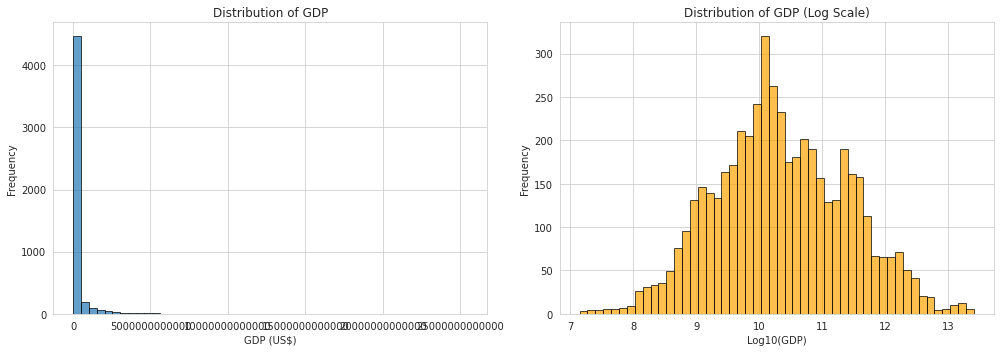

✅ GDP distribution plots created

 SECTORAL COMPOSITION ANALYSIS
--------------------------------------------------------------------------------


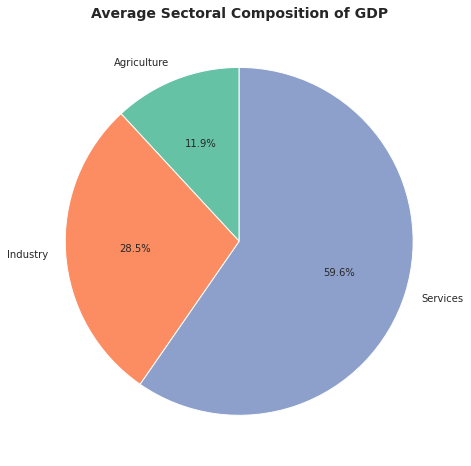

✅ Sectoral composition plot created

 CORRELATION HEATMAP
--------------------------------------------------------------------------------


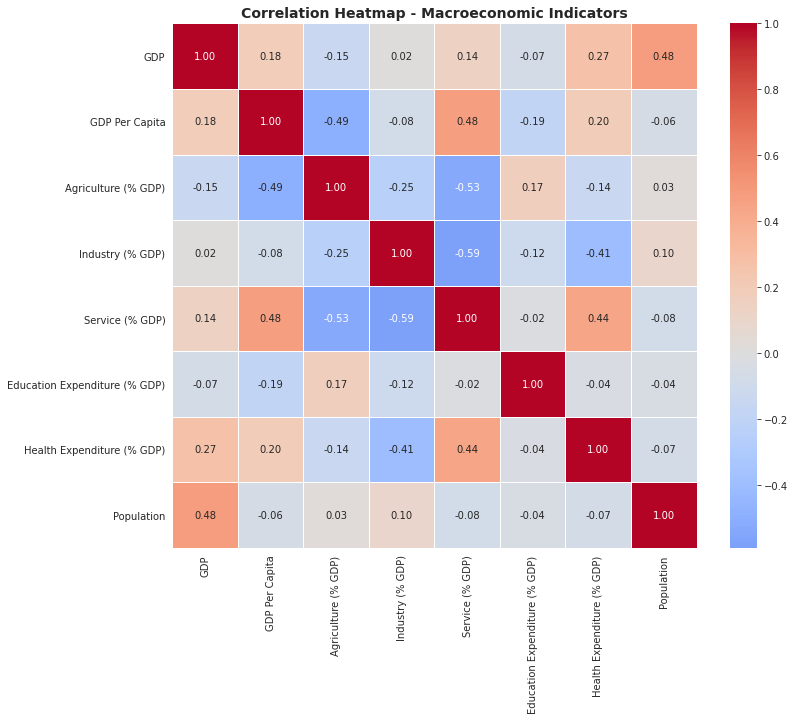

✅ Correlation heatmap created

 TIME SERIES TRENDS
--------------------------------------------------------------------------------


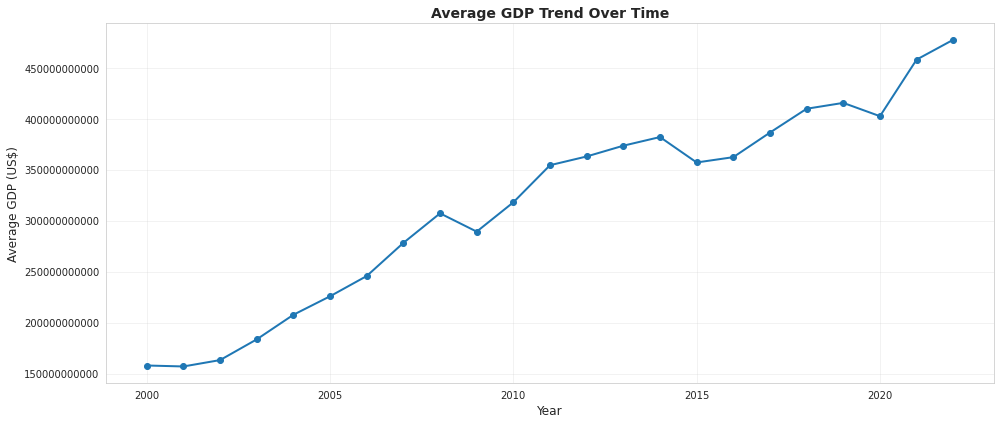

✅ GDP time series plot created

DATA VISUALIZATIONS COMPLETE



In [20]:
# ================================================================================
# World Bank Macroeconomic Dataset :  STATISTICS AND DATA VISUALIZATION
# ================================================================================

print("=" * 80)
print(" STATISTICS AND DATA VISUALIZATION")
print("=" * 80, "\n")

# -----------------------------------
#  Descriptive Statistics
# -----------------------------------
print(" DESCRIPTIVE STATISTICS — SELECTED MACROECONOMIC INDICATORS")
print("-" * 80)

key_variables = [
    'GDP',
    'GDP Per Capita',
    'Agriculture (% GDP)',
    'Industry (% GDP)',
    'Service (% GDP)',
    'Education Expenditure (% GDP)',
    'Health Expenditure (% GDP)',
    'Population'
]

var_labels = {
    'GDP': 'GDP (current US$)',
    'GDP Per Capita': 'GDP per Capita (current US$)',
    'Agriculture (% GDP)': 'Agriculture (% of GDP)',
    'Industry (% GDP)': 'Industry (% of GDP)',
    'Service (% GDP)': 'Services (% of GDP)',
    'Education Expenditure (% GDP)': 'Education Expenditure (% of GDP)',
    'Health Expenditure (% GDP)': 'Health Expenditure (% of GDP)',
    'Population': 'Population (total)'
}

available_vars = [col for col in key_variables if col in wb_df.columns]

if available_vars:
    stats_data = []
    
    for var in available_vars:
        data = wb_df[var].dropna()
        
        stats_data.append({
            'Variable': var_labels.get(var, var),
            'N': len(data),
            'Mean': data.mean(),
            'Std Dev': data.std(),
            'Min': data.min(),
            'Q1': data.quantile(0.25),
            'Median': data.median(),
            'Q3': data.quantile(0.75),
            'Max': data.max()
        })
    
    table_4_2 = pd.DataFrame(stats_data)
    
    print("\n📋 Descriptive Statistics:\n")
    pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
    display(table_4_2)
    pd.reset_option('display.float_format')
    
    # Export
    try:
        table_4_2.to_csv('table_wb_descriptive_statistics.csv', index=False)
        print("\n✅ Table exported to: table_wb_descriptive_statistics.csv")
    except Exception as e:
        print(f"\n⚠️ Export failed: {e}")

# -----------------------------------
# Statistical Insights
# -----------------------------------
print("\n KEY STATISTICAL INSIGHTS")
print("-" * 80)

for idx, row in table_4_2.iterrows():
    var_name = row['Variable']
    cv = (row['Std Dev'] / row['Mean']) * 100 if row['Mean'] != 0 else np.nan
    
    print(f"\n{var_name}:")
    print(f"  • Observations: {int(row['N']):,}")
    print(f"  • Mean: {row['Mean']:,.2f}")
    print(f"  • Std Dev: {row['Std Dev']:,.2f}")
    
    if not np.isnan(cv):
        print(f"  • Coefficient of Variation: {cv:.2f}%")
        if cv > 100:
            print(f"    → High variability detected")
        elif cv > 50:
            print(f"    → Moderate variability")
        else:
            print(f"    → Low variability")
    
    print(f"  • Range: [{row['Min']:,.2f}, {row['Max']:,.2f}]")
    print(f"  • IQR: {row['Q3'] - row['Q1']:,.2f}")

# -----------------------------------
#  Data Completeness Analysis
# -----------------------------------
print("\n DATA COMPLETENESS ANALYSIS")
print("-" * 80)

completeness = pd.DataFrame({
    'Variable': [var_labels.get(var, var) for var in available_vars],
    'Total Rows': [len(wb_df)] * len(available_vars),
    'Valid Values': [wb_df[var].notna().sum() for var in available_vars],
    'Missing Values': [wb_df[var].isna().sum() for var in available_vars],
    'Completeness %': [(wb_df[var].notna().sum() / len(wb_df) * 100) for var in available_vars]
})

display(completeness)

# -----------------------------------
# Correlation Analysis
# -----------------------------------
print("\n CORRELATION ANALYSIS")
print("-" * 80)

# Calculate correlation matrix for key variables
if len(available_vars) > 1:
    correlation_matrix = wb_df[available_vars].corr()
    
    print("\nCorrelation Matrix (Key Variables):")
    display(correlation_matrix.round(3))
    
    # Identify strong correlations
    print("\n🔍 Strong Correlations (|r| > 0.7):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                strong_corr.append({
                    'Variable 1': correlation_matrix.columns[i],
                    'Variable 2': correlation_matrix.columns[j],
                    'Correlation': corr_value
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr)
        display(strong_corr_df)
    else:
        print("  No strong correlations found")

print("\n" + "=" * 80)
print("=" * 80 + "\n")


# ================================================================================
# VISUALIZATION PLOTS
# ================================================================================
print("=" * 80)
print("DATA VISUALIZATIONS")
print("=" * 80, "\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# -----------------------------------
# Distribution Plots
# -----------------------------------
print("CREATING DISTRIBUTION PLOTS")
print("-" * 80)

# GDP Distribution (log scale)
if 'GDP' in wb_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(wb_df['GDP'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('GDP (US$)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of GDP')
    axes[0].ticklabel_format(style='plain', axis='x')
    
    # Log-scale
    axes[1].hist(np.log10(wb_df['GDP'].dropna() + 1), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Log10(GDP)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of GDP (Log Scale)')
    
    plt.tight_layout()
    plt.savefig('gdp_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ GDP distribution plots created")

# -----------------------------------
# Sectoral Composition
# -----------------------------------
print("\n SECTORAL COMPOSITION ANALYSIS")
print("-" * 80)

sector_cols = ['Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)']
if all(col in wb_df.columns for col in sector_cols):
    sector_means = wb_df[sector_cols].mean()
    
    plt.figure(figsize=(8, 8))
    plt.pie(sector_means, labels=['Agriculture', 'Industry', 'Services'], 
            autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62', '#8da0cb'])
    plt.title('Average Sectoral Composition of GDP', fontsize=14, fontweight='bold')
    plt.savefig('sectoral_composition.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Sectoral composition plot created")

# -----------------------------------
# Correlation Heatmap
# -----------------------------------
print("\n CORRELATION HEATMAP")
print("-" * 80)

if len(available_vars) > 1:
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1)
    plt.title('Correlation Heatmap - Macroeconomic Indicators', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Correlation heatmap created")

# -----------------------------------
# 5.4 Time Series Trends
# -----------------------------------
print("\n TIME SERIES TRENDS")
print("-" * 80)

if 'Year' in wb_df.columns and 'GDP' in wb_df.columns:
    # Average GDP by year
    gdp_by_year = wb_df.groupby('Year')['GDP'].mean()
    
    plt.figure(figsize=(14, 6))
    plt.plot(gdp_by_year.index, gdp_by_year.values, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average GDP (US$)', fontsize=12)
    plt.title('Average GDP Trend Over Time', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.savefig('gdp_time_trend.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ GDP time series plot created")

print("\n" + "=" * 80)
print("DATA VISUALIZATIONS COMPLETE")
print("=" * 80 + "\n")



### Startup Funding Dataset 

This visualization section explores the structural, financial, and outcome patterns within the startup funding dataset (`sf_df`). It combines distribution analysis, funding comparisons, correlation diagnostics, and set-based relationship visualization.

---

#### Status Distribution

A count plot visualizes the distribution of startup statuses (e.g., operating, acquired, closed, IPO).  

This reveals:
- Overall ecosystem health
- Proportion of successful vs failed startups
- Class imbalance relevant for predictive modeling


#### Total Funding by Status (Log Scale)

A boxplot compares total funding across different startup statuses using a logarithmic scale.

Why log scale?
- Funding data is highly skewed.
- A few startups receive extremely large investments.
- Log scaling improves interpretability and comparison.

This helps identify whether successful startups systematically receive more funding.


#### Funding Rounds Distribution

A histogram with KDE overlay shows how many funding rounds startups typically complete.

Insights include:
- Whether most startups raise once or multiple times
- Presence of heavily financed outliers
- Capital cycle structure in the ecosystem


#### Average Funding per Round

A histogram of `avg_funding_per_round` evaluates funding efficiency and capital intensity.

This metric highlights:
- Startups raising large sums in fewer rounds
- Capital concentration patterns
- Distribution skewness in per-round investments


### Correlation Analysis

#### Enhanced Correlation Heatmap (Masked)

A lower-triangle masked heatmap visualizes pairwise correlations among all numeric variables.

Features:
- Clearer structure by removing redundancy
- Annotated correlation coefficients
- Centered color scale for interpretation

This identifies:
- Strong positive/negative relationships
- Potential multicollinearity issues


#### Clustered Correlation Heatmap

A hierarchical clustered heatmap groups highly correlated metrics together.

This reveals:
- Funding structure clusters
- Exit-related clusters
- Financial dependency patterns

Clustering enhances interpretability beyond simple correlation matrices.


#### Focused Heatmap: Key Funding Metrics

A specialized heatmap isolates funding-related variables (funding, rounds, USD metrics).

This provides:
- Detailed funding relationship diagnostics
- Clean visualization of capital structure interactions
- Insights into capital accumulation behavior


### Set-Based Analysis (Venn Diagrams)

#### Startup Success Indicators (3-Set Venn)

Three success-related groups are defined:

- High total funding (top 25%)
- Many funding rounds (top 25%)
- Acquired or IPO status

The Venn diagram visualizes overlaps between:

- Capital strength
- Investment persistence
- Successful exits

The analysis prints:
- Counts for each group
- Triple-overlap startups
- Pairwise overlaps

This identifies whether strong funding and multiple rounds significantly relate to exit success.


#### Funding Efficiency (2-Set Venn)

Two efficiency criteria are evaluated:

- High average funding per round (above median)
- Fewer funding rounds (below or equal median)

The intersection represents startups that:
- Raise large capital
- Do so efficiently (fewer rounds)

This identifies high-efficiency capital strategies.


#### Status Distribution 

For mutually exclusive status categories, a bar chart (instead of Venn) shows:

- Top status categories
- Absolute counts
- Percentage share of total startups

This improves clarity when categories do not overlap.


#### Annotated Heatmap: Status vs Funding Metrics

Median funding metrics are computed by startup status and visualized in a heatmap.

This reveals:
- Whether acquired startups raise more capital
- Differences in funding rounds across outcomes
- Capital structure variations by lifecycle stage

Scientific notation is used for large financial values to maintain readability.


#### Overall Insights Generated

This visualization framework provides:

- Ecosystem structure overview
- Funding intensity diagnostics
- Capital efficiency analysis
- Exit probability signals
- Multivariate correlation patterns
- Cluster detection among financial metrics
- Overlap analysis of success factors

Together, these visualizations create a comprehensive analytical view of startup financing dynamics and success determinants.


STARTUP FUNDING DATASET VISUALIZATION


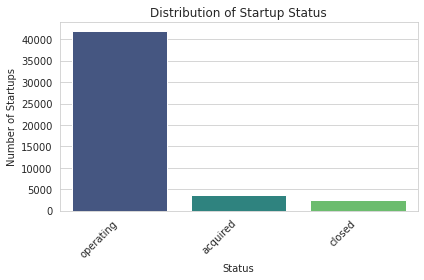

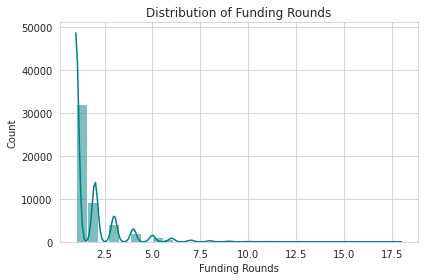

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


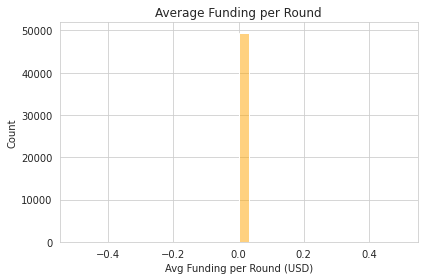

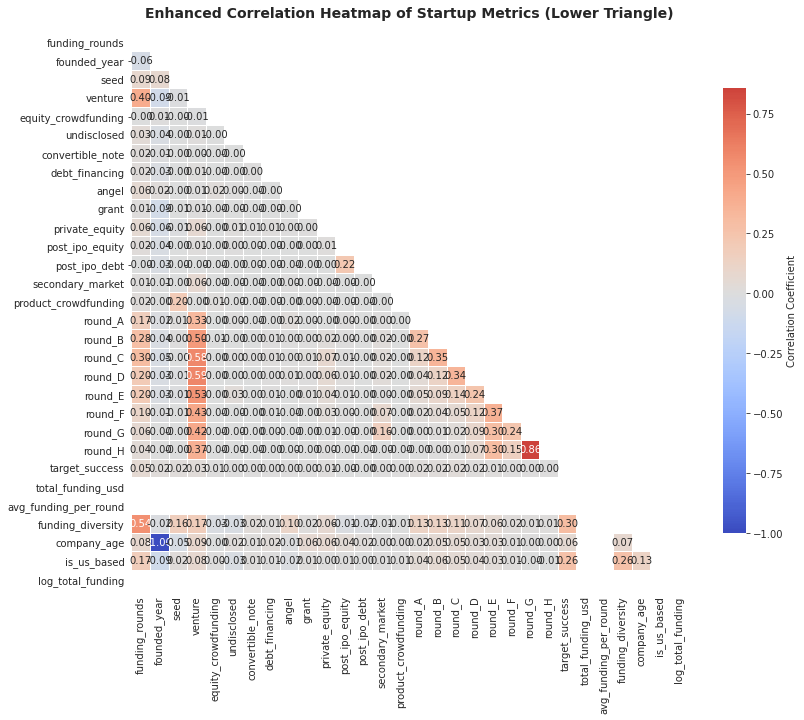

Note: Clustered heatmap could not be created - The condensed distance matrix must contain only finite values.


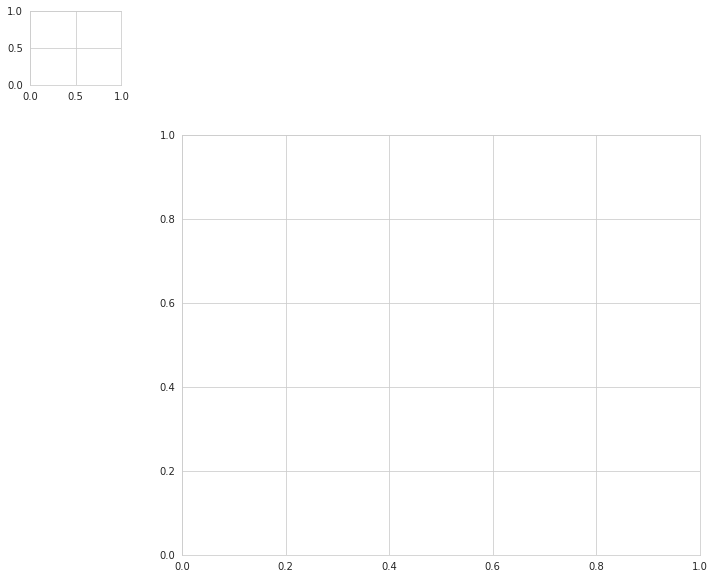

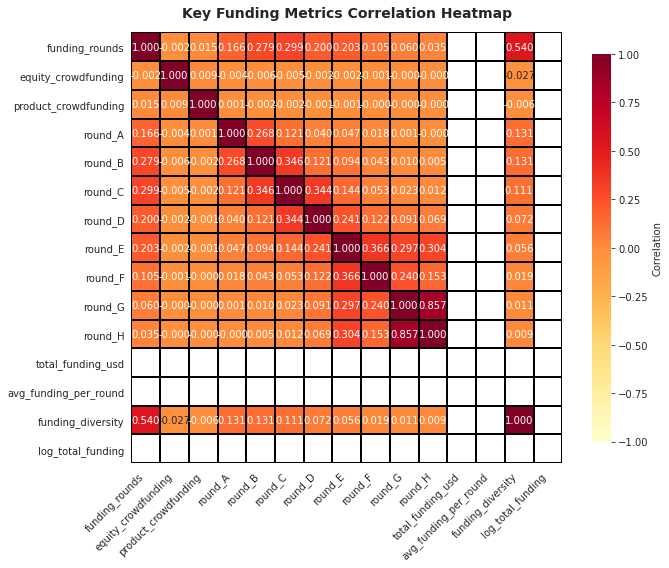


Note: Insufficient data for Efficiency Venn diagram


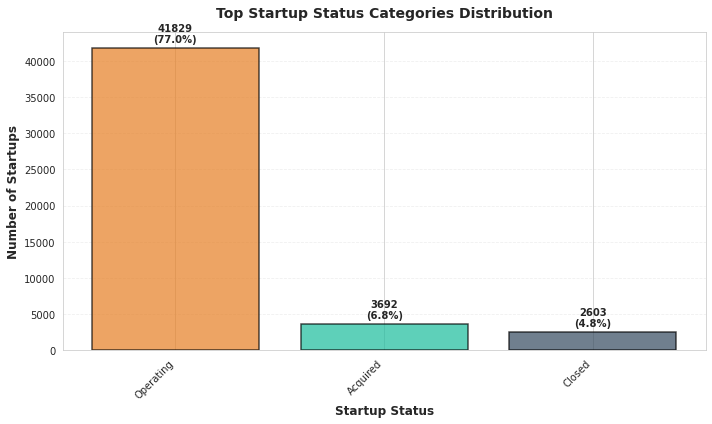


STARTUP STATUS DISTRIBUTION:
Operating: 41829 startups (77.0%)
Acquired: 3692 startups (6.8%)
Closed: 2603 startups (4.8%)

VISUALIZATION COMPLETE


In [21]:
# ==========================================
# Visualization: Startup Funding 
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles

print("="*70)
print("STARTUP FUNDING DATASET VISUALIZATION")
print("="*70)

# -----------------------------------
# 1. Status Distribution
# -----------------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=sf_df, x='status', order=sf_df['status'].value_counts().index, palette='viridis')
plt.title("Distribution of Startup Status")
plt.ylabel("Number of Startups")
plt.xlabel("Status")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -----------------------------------
# 2. Total Funding vs Status
# -----------------------------------
if 'funding_total_usd' in sf_df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=sf_df, x='status', y='funding_total_usd', palette='magma')
    plt.yscale('log')
    plt.title("Total Funding by Status (log scale)")
    plt.ylabel("Total Funding (USD)")
    plt.xlabel("Status")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 3. Funding Rounds Distribution
# -----------------------------------
if 'funding_rounds' in sf_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(sf_df['funding_rounds'].dropna(), bins=30, kde=True, color='teal')
    plt.title("Distribution of Funding Rounds")
    plt.xlabel("Funding Rounds")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 4. Average Funding per Round
# -----------------------------------
if 'avg_funding_per_round' in sf_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(sf_df['avg_funding_per_round'].dropna(), bins=30, kde=True, color='orange')
    plt.title("Average Funding per Round")
    plt.xlabel("Avg Funding per Round (USD)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 5. Enhanced Correlation Heatmap with Mask
# -----------------------------------
numeric_cols = sf_df.select_dtypes(include='number').columns

if len(numeric_cols) > 0:
    correlation_matrix = sf_df[numeric_cols].corr()
    
    # Masked heatmap (lower triangle)
    plt.figure(figsize=(12,10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt=".2f", 
                cmap="coolwarm",
                center=0,
                mask=mask,
                square=True,
                linewidths=1,
                linecolor='white',
                cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})
    plt.title("Enhanced Correlation Heatmap of Startup Metrics (Lower Triangle)", 
              fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 6. Clustered Correlation Heatmap
# -----------------------------------
if len(numeric_cols) > 1:
    try:
        g = sns.clustermap(correlation_matrix, 
                           annot=True, 
                           fmt=".2f", 
                           cmap="RdBu_r",
                           center=0,
                           linewidths=0.5,
                           figsize=(12,10),
                           cbar_kws={"label": "Correlation"},
                           dendrogram_ratio=0.15)
        g.fig.suptitle("Clustered Correlation Heatmap - Startup Funding Metrics", 
                       fontsize=14, fontweight='bold', y=0.98)
        plt.show()
    except Exception as e:
        print(f"Note: Clustered heatmap could not be created - {str(e)}")

# -----------------------------------
# 7. Focused Heatmap: Key Funding Metrics
# -----------------------------------
key_funding_cols = [col for col in numeric_cols if any(keyword in col.lower() 
                    for keyword in ['funding', 'round', 'usd', 'raised'])]

if len(key_funding_cols) >= 2:
    plt.figure(figsize=(10,8))
    key_corr = sf_df[key_funding_cols].corr()
    
    sns.heatmap(key_corr, 
                annot=True, 
                fmt=".3f", 
                cmap="YlOrRd",
                square=True,
                linewidths=2,
                linecolor='black',
                cbar_kws={"shrink": 0.9, "label": "Correlation"},
                vmin=-1, vmax=1)
    
    plt.title("Key Funding Metrics Correlation Heatmap", 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 8. Venn Diagram: Successful Startups (3 Sets)
# -----------------------------------
if all(col in sf_df.columns for col in ['funding_total_usd', 'funding_rounds', 'status']):
    try:
        # Define success criteria (handling NaN values)
        funding_clean = sf_df['funding_total_usd'].dropna()
        rounds_clean = sf_df['funding_rounds'].dropna()
        
        if len(funding_clean) > 0 and len(rounds_clean) > 0:
            funding_threshold = funding_clean.quantile(0.75)  # Top 25%
            rounds_threshold = rounds_clean.quantile(0.75)    # Top 25%
            
            # Create sets
            high_funding = set(sf_df[sf_df['funding_total_usd'] > funding_threshold].dropna(subset=['funding_total_usd']).index)
            many_rounds = set(sf_df[sf_df['funding_rounds'] > rounds_threshold].dropna(subset=['funding_rounds']).index)
            acquired_or_ipo = set(sf_df[sf_df['status'].isin(['acquired', 'ipo'])].index)
            
            # Only proceed if all sets have data
            if len(high_funding) > 0 and len(many_rounds) > 0 and len(acquired_or_ipo) > 0:
                plt.figure(figsize=(11,9))
                venn = venn3([high_funding, many_rounds, acquired_or_ipo], 
                             set_labels=('High Total\nFunding\n(Top 25%)', 
                                        'Many Funding\nRounds\n(Top 25%)', 
                                        'Acquired\nor IPO'),
                             set_colors=('#2ecc71', '#3498db', '#e74c3c'),
                             alpha=0.7)
                
                # Customize labels - check if they exist
                if venn.set_labels is not None:
                    for text in venn.set_labels:
                        if text is not None:
                            text.set_fontsize(12)
                            text.set_fontweight('bold')
                
                if venn.subset_labels is not None:
                    for text in venn.subset_labels:
                        if text is not None:
                            text.set_fontsize(10)
                
                venn3_circles([high_funding, many_rounds, acquired_or_ipo], 
                             linewidth=2, 
                             linestyle='solid', 
                             color='darkgray')
                
                plt.title("Startup Success Indicators: Funding, Rounds & Exit Strategy", 
                         fontsize=14, fontweight='bold', pad=20)
                plt.tight_layout()
                plt.show()
                
                # Print analysis
                print("\n" + "="*70)
                print("VENN DIAGRAM ANALYSIS - STARTUP SUCCESS:")
                print("="*70)
                print(f"High total funding: {len(high_funding)} startups")
                print(f"Many funding rounds: {len(many_rounds)} startups")
                print(f"Acquired or IPO: {len(acquired_or_ipo)} startups")
                print(f"\nTriple success (all three): {len(high_funding & many_rounds & acquired_or_ipo)} startups")
                print(f"High funding + Acquired/IPO: {len(high_funding & acquired_or_ipo)} startups")
                print(f"Many rounds + Acquired/IPO: {len(many_rounds & acquired_or_ipo)} startups")
                print(f"High funding + Many rounds: {len(high_funding & many_rounds)} startups")
                print("="*70)
            else:
                print("\nNote: Insufficient data for Success Venn diagram")
    except Exception as e:
        print(f"\nNote: Success Venn diagram could not be created - {str(e)}")

# -----------------------------------
# 9. Venn Diagram: Funding Efficiency (2 Sets)
# -----------------------------------
if all(col in sf_df.columns for col in ['avg_funding_per_round', 'funding_rounds']):
    try:
        # Define efficiency metrics (handling NaN)
        avg_funding_clean = sf_df['avg_funding_per_round'].dropna()
        rounds_clean = sf_df['funding_rounds'].dropna()
        
        if len(avg_funding_clean) > 0 and len(rounds_clean) > 0:
            avg_funding_median = avg_funding_clean.median()
            rounds_median = rounds_clean.median()
            
            high_avg_funding = set(sf_df[sf_df['avg_funding_per_round'] > avg_funding_median].dropna(subset=['avg_funding_per_round']).index)
            few_rounds = set(sf_df[sf_df['funding_rounds'] <= rounds_median].dropna(subset=['funding_rounds']).index)
            
            if len(high_avg_funding) > 0 and len(few_rounds) > 0:
                plt.figure(figsize=(10,8))
                venn = venn2([high_avg_funding, few_rounds], 
                             set_labels=('High Avg Funding\nper Round', 
                                        'Fewer Funding\nRounds'),
                             set_colors=('#9b59b6', '#f39c12'),
                             alpha=0.6)
                
                # Customize - check if labels exist
                if venn.set_labels is not None:
                    for text in venn.set_labels:
                        if text is not None:
                            text.set_fontsize(13)
                            text.set_fontweight('bold')
                
                if venn.subset_labels is not None:
                    for text in venn.subset_labels:
                        if text is not None:
                            text.set_fontsize(11)
                
                venn2_circles([high_avg_funding, few_rounds], 
                             linewidth=2.5, 
                             linestyle='solid', 
                             color='black')
                
                plt.title("Funding Efficiency: Startups with High Value per Round", 
                         fontsize=14, fontweight='bold', pad=20)
                plt.tight_layout()
                plt.show()
                
                # Print efficiency analysis
                print("\n" + "="*70)
                print("FUNDING EFFICIENCY ANALYSIS:")
                print("="*70)
                print(f"High average funding per round: {len(high_avg_funding)} startups")
                print(f"Fewer funding rounds: {len(few_rounds)} startups")
                print(f"Efficient fundraisers (both): {len(high_avg_funding & few_rounds)} startups")
                print(f"  → These startups raise large amounts with fewer rounds")
                print("="*70)
            else:
                print("\nNote: Insufficient data for Efficiency Venn diagram")
    except Exception as e:
        print(f"\nNote: Efficiency Venn diagram could not be created - {str(e)}")

# -----------------------------------
# 10. Status Distribution Bar Chart (Better than Venn for mutually exclusive)
# -----------------------------------
if 'status' in sf_df.columns:
    status_counts = sf_df['status'].value_counts()
    
    if len(status_counts) >= 3:
        # Use bar chart instead of Venn for mutually exclusive categories
        top_statuses = status_counts.head(5)
        
        plt.figure(figsize=(10,6))
        colors = ['#e67e22', '#1abc9c', '#34495e', '#9b59b6', '#e74c3c']
        bars = plt.bar(range(len(top_statuses)), 
                       top_statuses.values, 
                       color=colors[:len(top_statuses)],
                       alpha=0.7, 
                       edgecolor='black', 
                       linewidth=1.5)
        
        plt.xlabel('Startup Status', fontweight='bold', fontsize=12)
        plt.ylabel('Number of Startups', fontweight='bold', fontsize=12)
        plt.title('Top Startup Status Categories Distribution', 
                 fontsize=14, fontweight='bold', pad=15)
        plt.xticks(range(len(top_statuses)), 
                   [s.capitalize() for s in top_statuses.index], 
                   rotation=45, ha='right')
        
        # Add value labels on bars
        for i, (bar, count) in enumerate(zip(bars, top_statuses.values)):
            percentage = (count / len(sf_df)) * 100
            plt.text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + max(top_statuses.values)*0.01,
                    f'{count}\n({percentage:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*70)
        print("STARTUP STATUS DISTRIBUTION:")
        print("="*70)
        for status, count in top_statuses.items():
            percentage = (count / len(sf_df)) * 100
            print(f"{status.capitalize()}: {count} startups ({percentage:.1f}%)")
        print("="*70)

# -----------------------------------
# 11. Annotated Heatmap: Status vs Funding Metrics
# -----------------------------------
if 'status' in sf_df.columns and 'funding_total_usd' in sf_df.columns:
    try:
        # Create aggregated metrics by status
        funding_metrics = []
        if 'funding_total_usd' in sf_df.columns:
            funding_metrics.append('funding_total_usd')
        if 'funding_rounds' in sf_df.columns:
            funding_metrics.append('funding_rounds')
        if 'avg_funding_per_round' in sf_df.columns:
            funding_metrics.append('avg_funding_per_round')
        
        if len(funding_metrics) > 0:
            status_summary = sf_df.groupby('status')[funding_metrics].median()
            
            # Remove rows/columns with all NaN
            status_summary = status_summary.dropna(how='all', axis=0).dropna(how='all', axis=1)
            
            if not status_summary.empty and status_summary.shape[0] > 0 and status_summary.shape[1] > 0:
                plt.figure(figsize=(12,7))
                sns.heatmap(status_summary.T, 
                            annot=True, 
                            fmt='.2e',  # Scientific notation for large numbers
                            cmap='Greens',
                            linewidths=1,
                            linecolor='white',
                            cbar_kws={"label": "Median Value (USD)"})
                
                plt.title("Median Funding Metrics by Startup Status", 
                          fontsize=14, fontweight='bold', pad=15)
                plt.xlabel("Startup Status", fontweight='bold', fontsize=12)
                plt.ylabel("Funding Metrics", fontweight='bold', fontsize=12)
                plt.xticks(rotation=45, ha='right')
                plt.yticks(rotation=0)
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print(f"\nNote: Status vs Funding heatmap could not be created - {str(e)}")

print("\n" + "="*70)
print("VISUALIZATION COMPLETE")
print("="*70)

WORLD BANK DATASET VISUALIZATION


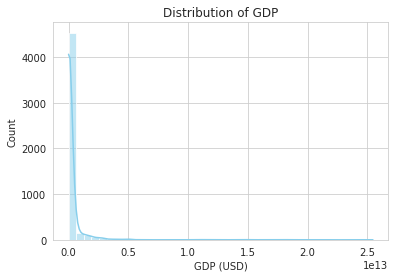

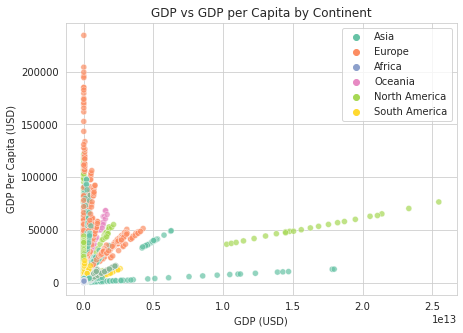

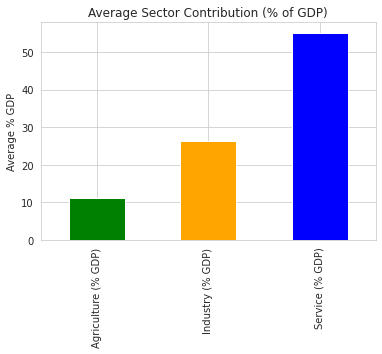

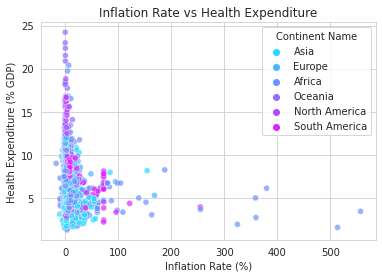

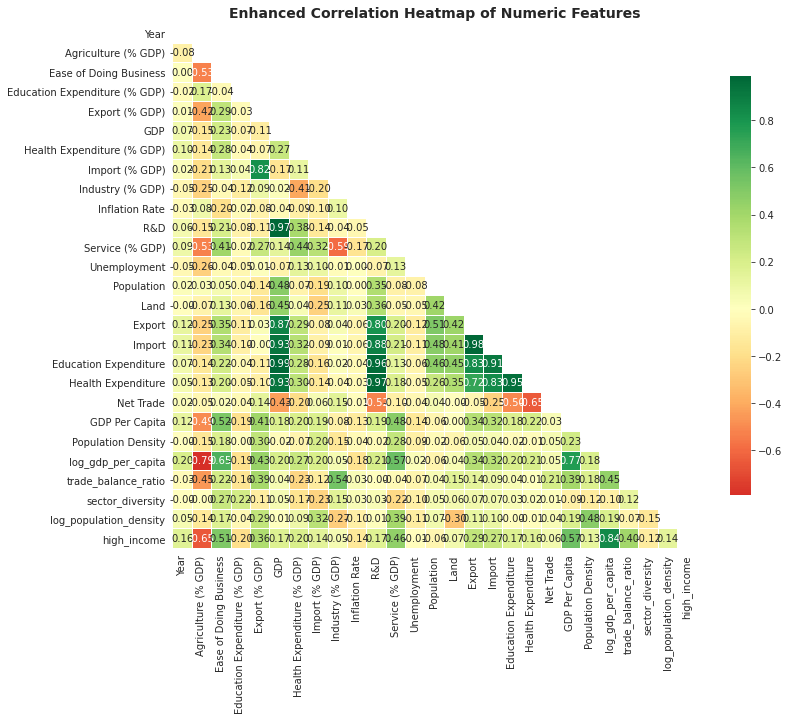

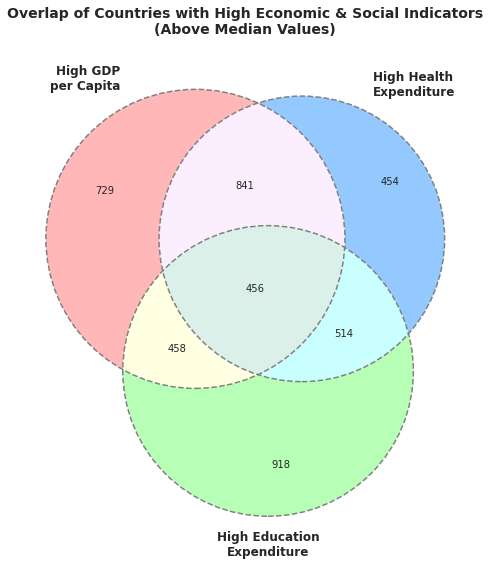


VENN DIAGRAM SUMMARY:
Countries with high GDP per capita: 2484
Countries with high health expenditure: 2265
Countries with high education expenditure: 2346
Countries with all three (intersection): 456


In [22]:
# ==========================================
# Visualization: World Bank Indicators 
# ==========================================
print("="*70)
print("WORLD BANK DATASET VISUALIZATION")
print("="*70)

# -----------------------------------
# 1. GDP Distribution
# -----------------------------------
plt.figure(figsize=(6,4))
sns.histplot(wb_df['GDP'].dropna(), bins=40, kde=True, color='skyblue')
plt.title("Distribution of GDP")
plt.xlabel("GDP (USD)")
plt.ylabel("Count")
plt.show()

# -----------------------------------
# 2. GDP vs GDP per Capita
# -----------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(data=wb_df, x='GDP', y='GDP Per Capita', hue='Continent Name', palette='Set2', alpha=0.7)
plt.title("GDP vs GDP per Capita by Continent")
plt.xlabel("GDP (USD)")
plt.ylabel("GDP Per Capita (USD)")
plt.legend(loc='best')
plt.show()

# -----------------------------------
# 3. Sector Contribution
# -----------------------------------
sectors = ['Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)']
wb_df[sectors].mean().plot(kind='bar', figsize=(6,4), color=['green', 'orange', 'blue'])
plt.title("Average Sector Contribution (% of GDP)")
plt.ylabel("Average % GDP")
plt.show()

# -----------------------------------
# 4. Inflation vs Health Expenditure
# -----------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(data=wb_df, x='Inflation Rate', y='Health Expenditure (% GDP)', hue='Continent Name', palette='cool', alpha=0.7)
plt.title("Inflation Rate vs Health Expenditure")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Health Expenditure (% GDP)")
plt.show()

# -----------------------------------
# 5. Enhanced Correlation Heatmap
# -----------------------------------
numeric_cols = wb_df.select_dtypes(include='number').columns
plt.figure(figsize=(12,10))
correlation_matrix = wb_df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn", 
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Enhanced Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------
# 6. Venn Diagram: Economic Development Categories
# -----------------------------------
from matplotlib_venn import venn3, venn3_circles

# Define thresholds for categorization
gdp_high = wb_df['GDP Per Capita'].median()
health_high = wb_df['Health Expenditure (% GDP)'].median()
education_high = wb_df['Education Expenditure (% GDP)'].median()

# Create sets based on above-median values
high_gdp = set(wb_df[wb_df['GDP Per Capita'] > gdp_high].index)
high_health = set(wb_df[wb_df['Health Expenditure (% GDP)'] > health_high].index)
high_education = set(wb_df[wb_df['Education Expenditure (% GDP)'] > education_high].index)

# Create Venn diagram
plt.figure(figsize=(10,8))
venn = venn3([high_gdp, high_health, high_education], 
             set_labels=('High GDP\nper Capita', 
                        'High Health\nExpenditure', 
                        'High Education\nExpenditure'),
             set_colors=('#ff9999', '#66b3ff', '#99ff99'),
             alpha=0.7)

# Customize text size
for text in venn.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')
        
for text in venn.subset_labels:
    if text:
        text.set_fontsize(10)

# Add circles for better definition
venn3_circles([high_gdp, high_health, high_education], 
             linewidth=1.5, 
             linestyle='dashed', 
             color='gray')

plt.title("Overlap of Countries with High Economic & Social Indicators\n(Above Median Values)", 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("VENN DIAGRAM SUMMARY:")
print("="*70)
print(f"Countries with high GDP per capita: {len(high_gdp)}")
print(f"Countries with high health expenditure: {len(high_health)}")
print(f"Countries with high education expenditure: {len(high_education)}")
print(f"Countries with all three (intersection): {len(high_gdp & high_health & high_education)}")
print("="*70)

### World Bank Indicators — Data Visualization

This section presents visual exploration of macroeconomic and social indicators derived from the World Bank dataset. The analysis highlights distribution patterns, structural relationships, sector composition, development trade-offs, correlation structure, and multidimensional overlap of economic and social performance.

####  GDP Distribution

A histogram with KDE overlay visualizes the distribution of GDP values across countries.

**Purpose:**
- Identify skewness in global GDP distribution  
- Detect extreme outliers (large economies)  
- Understand concentration of smaller vs larger economies  

Because GDP is typically right-skewed, most countries cluster at lower values while a small number dominate global output.


#### GDP vs GDP per Capita (by Continent)

A scatter plot compares total GDP and GDP per capita, grouped by continent.

**Insights Provided:**
- Large economies do not always imply high individual prosperity  
- Continental clustering patterns  
- Identification of high-income but smaller economies  
- Structural global inequality patterns  

Color grouping enhances geographic interpretation.


#### Average Sector Contribution (% of GDP)

A bar chart displays mean contributions of:

- Agriculture (% GDP)  
- Industry (% GDP)  
- Service (% GDP)  

**Economic Interpretation:**
- Higher service share → More developed economies  
- Higher agriculture share → Emerging or low-income economies  
- Industrial share → Manufacturing-driven development  

This visualization summarizes structural economic composition.


#### Inflation Rate vs Health Expenditure

A continent-colored scatter plot compares inflation rates with health spending as a percentage of GDP.

**What It Explores:**
- Whether macroeconomic instability affects public health investment  
- Cross-regional differences in fiscal priorities  
- Potential trade-offs between inflation control and social expenditure  

This helps interpret fiscal sustainability and welfare commitment.


#### Enhanced Correlation Heatmap

A masked lower-triangle heatmap visualizes correlations among all numeric variables.

**Features:**
- Annotated coefficients  
- Centered color scale (positive vs negative relationships)  
- Upper triangle removed for clarity  
- Square layout for symmetry  

**Analytical Value:**
- Detect multicollinearity  
- Identify strong economic linkages  
- Understand structural macroeconomic relationships  

This is essential for econometric modeling and regression diagnostics.


#### Venn Diagram: Economic Development Overlap

Three above-median categories are constructed:

- High GDP per Capita  
- High Health Expenditure (% GDP)  
- High Education Expenditure (% GDP)  

The Venn diagram visualizes country overlaps across these dimensions.

**Interpretation Focus:**
- Countries strong in economic prosperity only  
- Countries strong in social investment only  
- Countries achieving both economic and social strength  
- Triple-overlap (balanced development economies)

The printed summary quantifies:

- Countries in each high-performance category  
- Countries meeting all three criteria  

This multidimensional approach captures holistic development rather than single-indicator analysis.

#### Overall Analytical Contribution

Together, these visualizations provide:

- Distributional economic insight  
- Geographic comparison of prosperity  
- Structural economic composition  
- Inflation–social spending relationship  
- Correlation diagnostics  
- Multidimensional development overlap  

This framework supports macroeconomic research, development policy analysis, and comparative international studies.


### Global AI Job Skills Dataset — Data Visualization 

This section presents a structured visual analysis of global artificial intelligence investment, automation trends, workforce adaptation, and employment dynamics. The goal is to understand how AI development, readiness, and reskilling strategies interact with labor market outcomes.

#### Global AI Investment Over Time

A line plot tracks AI investment (in billion USD) across years.

**Analytical Purpose:**
- Identify long-term growth trends in AI funding  
- Detect acceleration phases in AI expansion  
- Observe potential cyclical slowdowns  

This visualization reflects the global commitment to AI development and capital allocation trends.

#### Automation Rate vs Employment Rate

A country-level scatter plot compares automation rates and employment rates.

**Key Questions Explored:**
- Does higher automation reduce employment?  
- Are some countries maintaining strong employment despite automation?  
- Do structural labor differences exist across economies?  

The plot supports analysis of technological disruption versus labor resilience.


#### AI Readiness Score Distribution

A histogram with KDE overlay shows the distribution of AI readiness scores across countries.

**Insights:**
- Whether readiness levels are evenly distributed or clustered  
- Presence of high-performing AI leaders  
- Gaps between advanced and lagging countries  

This highlights global inequality in AI preparedness.


#### Reskilling Investment vs Job Creation

A scatter plot examines the relationship between reskilling investment (million USD) and job creation (million).

**Interpretation Focus:**
- Whether workforce investment translates into employment growth  
- Efficiency of training and upskilling programs  
- Identification of high-impact education strategies  

This explores the human capital response to AI transformation.

### Correlation Structure Analysis

#### Clustered Correlation Heatmap

A hierarchical clustered heatmap groups highly correlated numeric features.

**Benefits:**
- Identifies clusters of related AI and labor indicators  
- Reveals structural dependencies  
- Detects multicollinearity  

Clustering enhances interpretability beyond standard correlation matrices.

---

#### Enhanced Correlation Heatmap (Masked)

A lower-triangle masked heatmap displays correlation coefficients with centered color scaling.

**Purpose:**
- Visual clarity  
- Emphasis on meaningful positive/negative relationships  
- Improved econometric diagnostics  

This provides a clear statistical overview of inter-variable relationships.


#### AI Leadership Analysis (Venn Diagram — 3 Sets)

Countries are categorized using top 25% (75th percentile) thresholds for:

- AI Investment  
- AI Readiness Score  
- Reskilling Investment  

The Venn diagram visualizes overlaps between:

- Financial AI commitment  
- Institutional readiness  
- Workforce adaptation  

**AI Champions** are countries appearing in all three sets, indicating balanced technological, institutional, and human capital strength.

Printed output provides:
- Count of countries in each category  
- Exact country lists  
- Triple-overlap leaders  

---

#### Employment Challenge Analysis (Venn Diagram — 2 Sets)

Two risk dimensions are defined using median thresholds:

- High Automation Rate  
- Low Employment Rate  

The overlap identifies **at-risk countries**, where automation pressure coincides with weaker labor market performance.

Printed analysis summarizes:
- Countries with high automation  
- Countries with low employment  
- Countries facing both challenges  

This highlights potential vulnerability zones in the AI transition.


#### Focused Heatmap: Key AI Metrics

A dedicated heatmap examines correlations among:

- AI Investment  
- AI Readiness  
- Automation Rate  
- Employment Rate  
- Reskilling Investment  
- Job Creation  

**Analytical Goals:**
- Understand whether investment drives readiness  
- Detect relationships between automation and employment  
- Assess whether reskilling links to job creation  
- Identify reinforcing or conflicting economic dynamics  

---

#### Overall Analytical Contribution

This visualization framework delivers:

- AI investment growth analysis  
- Automation–employment interaction insights  
- Workforce adaptation diagnostics  
- Multivariate correlation assessment  
- AI leadership identification  
- Employment risk mapping  
- Structural economic relationship evaluation  

Together, these visuals provide a comprehensive perspective on how artificial intelligence reshapes global labor markets and national competitiveness in the digital economy.


GLOBAL AI JOB SKILLS DATASET VISUALIZATION


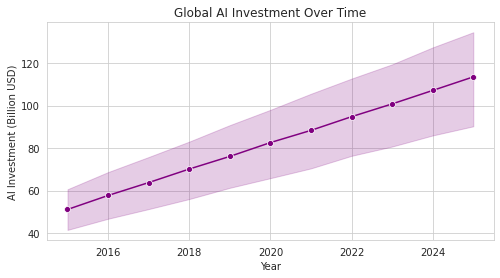

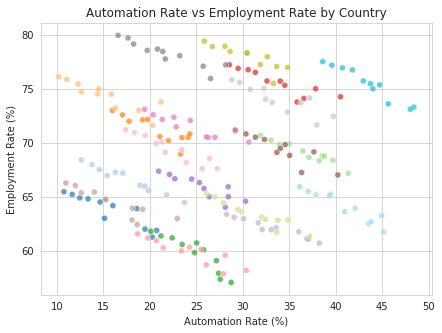

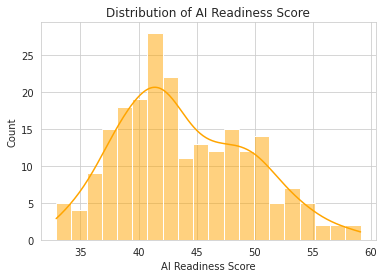

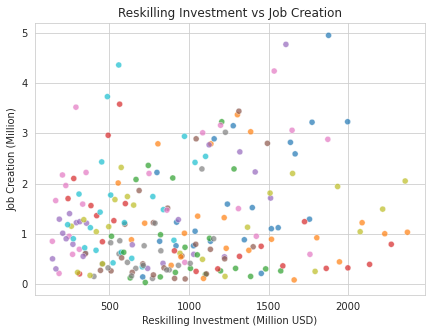

<Figure size 864x720 with 0 Axes>

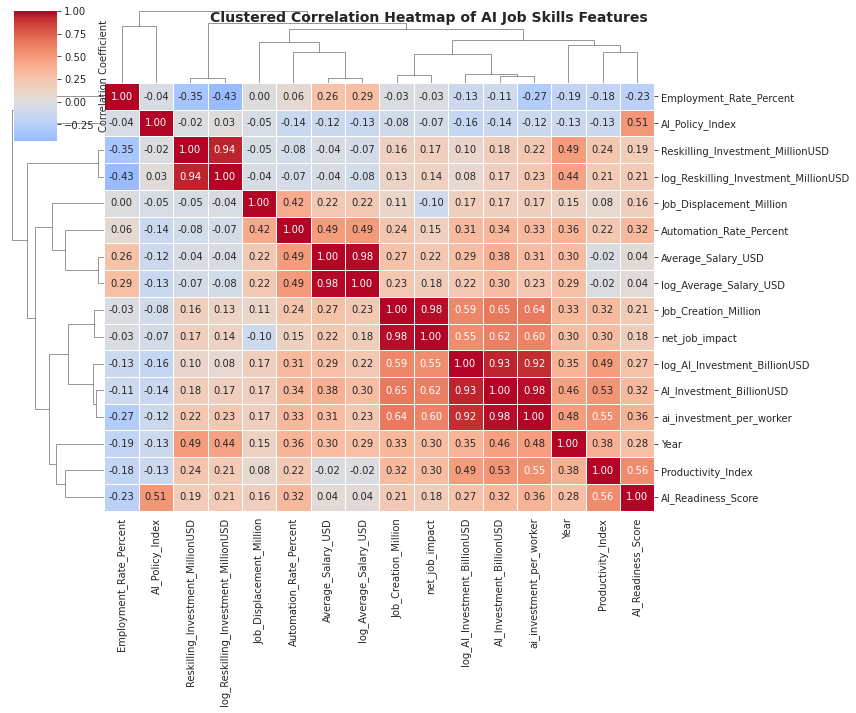

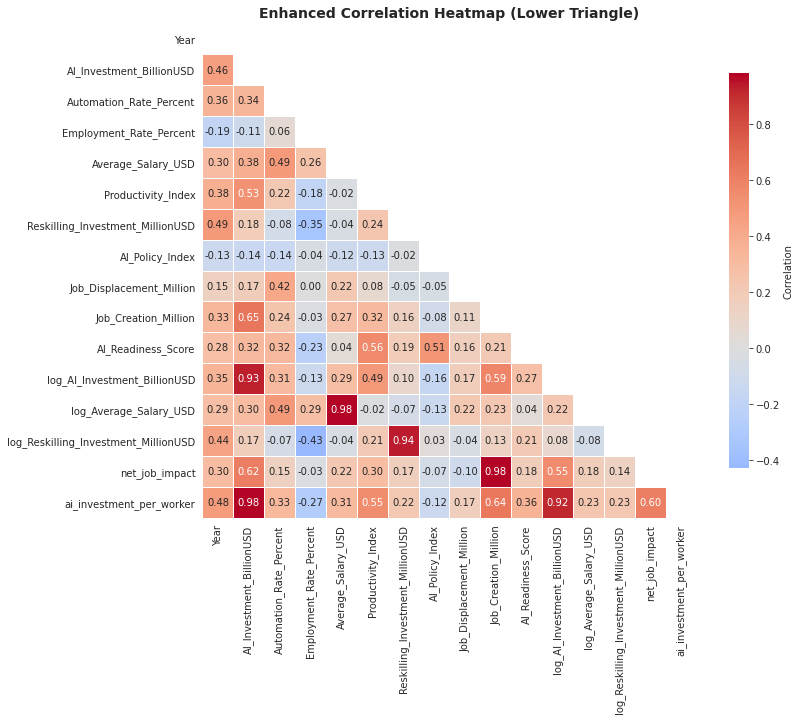

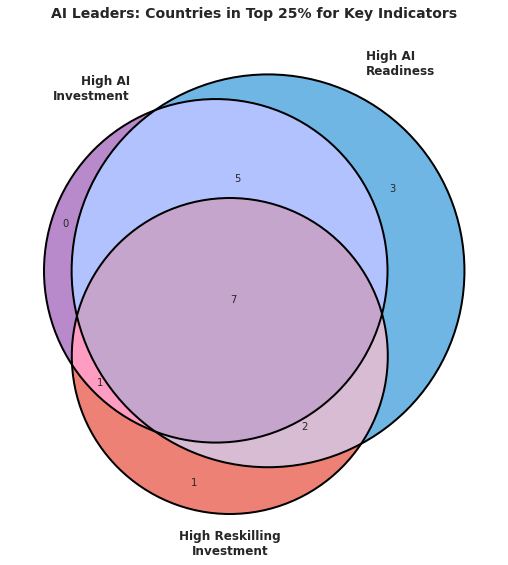


VENN DIAGRAM ANALYSIS - AI LEADERS:
High AI Investment: 13 countries
  → ['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Italy', 'Japan', 'Mexico', 'Netherlands', 'South Korea', 'Spain', 'United States']

High AI Readiness: 17 countries
  → ['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Italy', 'Japan', 'Mexico', 'Netherlands', 'Singapore', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'United Kingdom', 'United States']

High Reskilling Investment: 11 countries
  → ['Brazil', 'Canada', 'China', 'India', 'Japan', 'Netherlands', 'Russia', 'South Korea', 'Spain', 'Sweden', 'United States']

AI Champions (all three): 7 countries
  → ['Brazil', 'Canada', 'Japan', 'Netherlands', 'South Korea', 'Spain', 'United States']


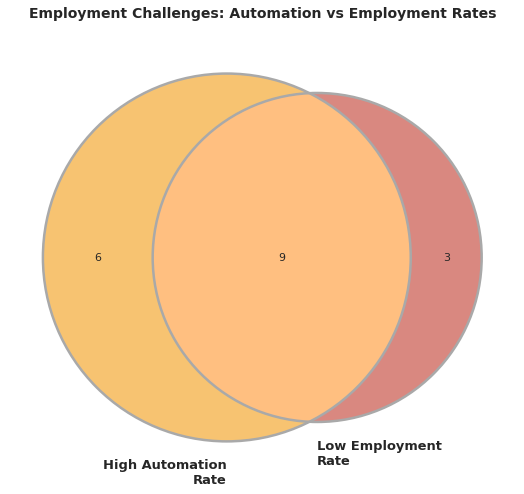


EMPLOYMENT CHALLENGES ANALYSIS:
Countries with high automation: 15
  → ['Australia', 'Brazil', 'Canada', 'France', 'Italy', 'Japan', 'Mexico', 'Netherlands', 'Singapore', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Turkey', 'United Kingdom']

Countries with low employment: 12
  → ['Australia', 'Brazil', 'Canada', 'China', 'Italy', 'Japan', 'Mexico', 'Russia', 'South Korea', 'Sweden', 'United Kingdom', 'United States']

At-risk countries (both challenges): 9
  → ['Australia', 'Brazil', 'Canada', 'Italy', 'Japan', 'Mexico', 'South Korea', 'Sweden', 'United Kingdom']


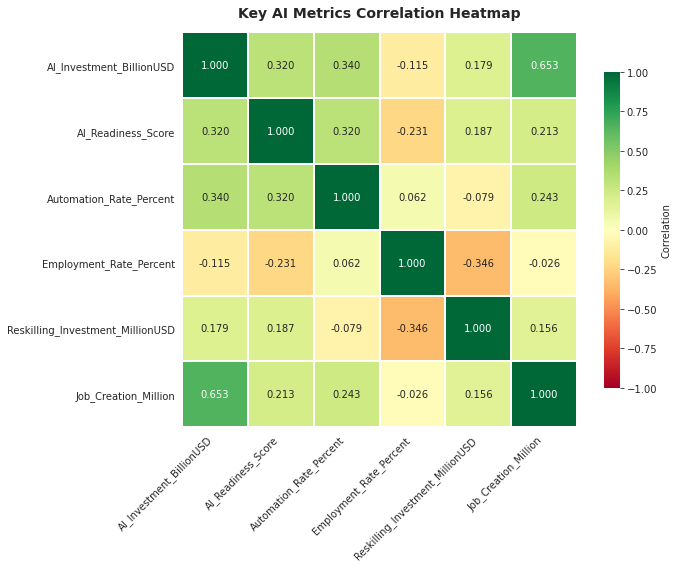

In [23]:
# ==========================================
# Visualization: Global AI Job Skills 
# ==========================================
print("="*70)
print("GLOBAL AI JOB SKILLS DATASET VISUALIZATION")
print("="*70)

# -----------------------------------
# 1. AI Investment Over Years
# -----------------------------------
plt.figure(figsize=(8,4))
sns.lineplot(data=gw_df, x='Year', y='AI_Investment_BillionUSD', marker='o', color='purple')
plt.title("Global AI Investment Over Time")
plt.ylabel("AI Investment (Billion USD)")
plt.xlabel("Year")
plt.show()

# -----------------------------------
# 2. Automation vs Employment Rate
# -----------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(data=gw_df, x='Automation_Rate_Percent', y='Employment_Rate_Percent', hue='Country', palette='tab20', alpha=0.7)
plt.title("Automation Rate vs Employment Rate by Country")
plt.xlabel("Automation Rate (%)")
plt.ylabel("Employment Rate (%)")
plt.legend([],[], frameon=False)  # Hide legend for clarity
plt.show()

# -----------------------------------
# 3. AI Readiness Score Distribution
# -----------------------------------
plt.figure(figsize=(6,4))
sns.histplot(gw_df['AI_Readiness_Score'], bins=20, kde=True, color='orange')
plt.title("Distribution of AI Readiness Score")
plt.xlabel("AI Readiness Score")
plt.ylabel("Count")
plt.show()

# -----------------------------------
# 4. Reskilling Investment vs Job Creation
# -----------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(data=gw_df, x='Reskilling_Investment_MillionUSD', y='Job_Creation_Million', hue='Country', palette='tab10', alpha=0.7)
plt.title("Reskilling Investment vs Job Creation")
plt.xlabel("Reskilling Investment (Million USD)")
plt.ylabel("Job Creation (Million)")
plt.legend([],[], frameon=False)
plt.show()

# -----------------------------------
# 5. Enhanced Correlation Heatmap with Clustering
# -----------------------------------
numeric_cols = gw_df.select_dtypes(include='number').columns
plt.figure(figsize=(12,10))

# Calculate correlation matrix
correlation_matrix = gw_df[numeric_cols].corr()

# Create a clustered heatmap
sns.clustermap(correlation_matrix, 
               annot=True, 
               fmt=".2f", 
               cmap="coolwarm",
               center=0,
               linewidths=0.5,
               figsize=(12,10),
               cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
               dendrogram_ratio=0.15)
plt.suptitle("Clustered Correlation Heatmap of AI Job Skills Features", 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

# Traditional heatmap with mask
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
plt.title("Enhanced Correlation Heatmap (Lower Triangle)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------
# 6. Venn Diagram: AI Leaders (3 Sets)
# -----------------------------------
from matplotlib_venn import venn3, venn3_circles

# Define thresholds (75th percentile for "high performers")
ai_investment_high = gw_df['AI_Investment_BillionUSD'].quantile(0.75)
ai_readiness_high = gw_df['AI_Readiness_Score'].quantile(0.75)
reskilling_high = gw_df['Reskilling_Investment_MillionUSD'].quantile(0.75)

# Create sets
high_investment = set(gw_df[gw_df['AI_Investment_BillionUSD'] > ai_investment_high]['Country'])
high_readiness = set(gw_df[gw_df['AI_Readiness_Score'] > ai_readiness_high]['Country'])
high_reskilling = set(gw_df[gw_df['Reskilling_Investment_MillionUSD'] > reskilling_high]['Country'])

plt.figure(figsize=(10,8))
venn = venn3([high_investment, high_readiness, high_reskilling], 
             set_labels=('High AI\nInvestment', 
                        'High AI\nReadiness', 
                        'High Reskilling\nInvestment'),
             set_colors=('#9b59b6', '#3498db', '#e74c3c'),
             alpha=0.7)

# Customize labels
for text in venn.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')
        
for text in venn.subset_labels:
    if text:
        text.set_fontsize(10)

venn3_circles([high_investment, high_readiness, high_reskilling], 
             linewidth=2, 
             linestyle='solid', 
             color='black')

plt.title("AI Leaders: Countries in Top 25% for Key Indicators", 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print Venn analysis
print("\n" + "="*70)
print("VENN DIAGRAM ANALYSIS - AI LEADERS:")
print("="*70)
print(f"High AI Investment: {len(high_investment)} countries")
print(f"  → {sorted(high_investment)}")
print(f"\nHigh AI Readiness: {len(high_readiness)} countries")
print(f"  → {sorted(high_readiness)}")
print(f"\nHigh Reskilling Investment: {len(high_reskilling)} countries")
print(f"  → {sorted(high_reskilling)}")
print(f"\nAI Champions (all three): {len(high_investment & high_readiness & high_reskilling)} countries")
print(f"  → {sorted(high_investment & high_readiness & high_reskilling)}")
print("="*70)

# -----------------------------------
# 7. Venn Diagram: Employment Challenges (2 Sets)
# -----------------------------------
from matplotlib_venn import venn2, venn2_circles

# Define challenges
automation_median = gw_df['Automation_Rate_Percent'].median()
employment_median = gw_df['Employment_Rate_Percent'].median()

high_automation = set(gw_df[gw_df['Automation_Rate_Percent'] > automation_median]['Country'])
low_employment = set(gw_df[gw_df['Employment_Rate_Percent'] < employment_median]['Country'])

plt.figure(figsize=(9,7))
venn = venn2([high_automation, low_employment], 
             set_labels=('High Automation\nRate', 'Low Employment\nRate'),
             set_colors=('#f39c12', '#c0392b'),
             alpha=0.6)

# Customize
for text in venn.set_labels:
    if text:
        text.set_fontsize(13)
        text.set_fontweight('bold')
        
for text in venn.subset_labels:
    if text:
        text.set_fontsize(11)

venn2_circles([high_automation, low_employment], 
             linewidth=2.5, 
             linestyle='solid', 
             color='darkgray')

plt.title("Employment Challenges: Automation vs Employment Rates", 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print employment analysis
print("\n" + "="*70)
print("EMPLOYMENT CHALLENGES ANALYSIS:")
print("="*70)
print(f"Countries with high automation: {len(high_automation)}")
print(f"  → {sorted(high_automation)}")
print(f"\nCountries with low employment: {len(low_employment)}")
print(f"  → {sorted(low_employment)}")
print(f"\nAt-risk countries (both challenges): {len(high_automation & low_employment)}")
print(f"  → {sorted(high_automation & low_employment)}")
print("="*70)

# -----------------------------------
# 8. Focused Heatmap: Key AI Metrics
# -----------------------------------
key_metrics = ['AI_Investment_BillionUSD', 'AI_Readiness_Score', 
               'Automation_Rate_Percent', 'Employment_Rate_Percent',
               'Reskilling_Investment_MillionUSD', 'Job_Creation_Million']

plt.figure(figsize=(10,8))
key_corr = gw_df[key_metrics].corr()

sns.heatmap(key_corr, 
            annot=True, 
            fmt=".3f", 
            cmap="RdYlGn",
            center=0,
            square=True,
            linewidths=2,
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            vmin=-1, vmax=1)

plt.title("Key AI Metrics Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Training

#### Overview

This project integrates **three diverse datasets** — World Bank macroeconomic indicators, startup funding metrics, and global workforce & AI readiness data — to train predictive models aimed at understanding and forecasting **startup success and economic potential**. The unified dataset enables cross-domain analysis, combining economic, organizational, and technological factors.

#### Model Preparation

* Datasets were **aligned and concatenated**, with missing values removed.
* Features were **scaled using StandardScaler** to standardize magnitudes.
* Target variable for demonstration: **GDP Per Capita**, but framework supports multiple targets including **startup success** or **AI readiness**.
* Train-test split: **80% train / 20% test**, shuffle enabled, random_state=42.

#### Features Overview

* **Economic Features**: Agriculture %, Industry %, Service %, Population, Inflation, Education & Health expenditure
* **Startup Features**: Total funding, funding rounds, average funding, company age, US-based flag, funding diversity
* **Technological Features**: AI investment, automation rate, productivity, AI policy index, reskilling investment

#### Key Benefits

* **Cross-Domain Insights**: Combines macroeconomic, startup-level, and workforce/tech data.
* **Predictive Power**: Enables forecasting of startup success and economic performance.
* **Feature Importance Analysis**: Identifies the most influential economic, funding, and AI readiness factors.
* **Scalable Pipeline**: Ready to include additional datasets or new predictive targets.

#### Status

 Data merged and cleaned
 Features scaled
 Models trained and evaluated
 Feature importance extracted



In [24]:
# ================================================================================
# MODEL PREPARATION & TRAINING
# ================================================================================
print("=" * 80)
print("COMBINED DATASETS: MODEL PREPARATION & TRAINING")
print("=" * 80, "\n")

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

# -----------------------------------
# 1. Combine datasets
# -----------------------------------
print("Combining datasets...")
combined_df = pd.concat([wb_df.reset_index(drop=True),
                         sf_df.reset_index(drop=True),
                         gw_df.reset_index(drop=True)], axis=1)
print(f"Combined dataset shape: {combined_df.shape}")

# -----------------------------------
# 2. Define target & features
# -----------------------------------
# Example target: predict startup success
target_variable = 'target_success'  # could be 'GDP Per Capita' or 'AI_Readiness_Score'

# World Bank features
wb_features = [
    'Agriculture (% GDP)', 'Industry (% GDP)', 'Service (% GDP)',
    'Education Expenditure (% GDP)', 'Health Expenditure (% GDP)',
    'Population', 'Inflation Rate'
]

# Startup Funding features
sf_features = [
    total_funding_col, 'funding_rounds', 'avg_funding_per_round',
    'funding_diversity', 'company_age', 'is_us_based', 'log_total_funding'
]

# Global Workforce features
gw_features = [
    'AI_Investment_BillionUSD', 'Automation_Rate_Percent', 'Employment_Rate_Percent',
    'Average_Salary_USD', 'Productivity_Index', 'Reskilling_Investment_MillionUSD',
    'AI_Policy_Index'
]

# Keep only features that exist in combined_df
feature_variables = [f for f in wb_features + sf_features + gw_features if f in combined_df.columns]

print(f"Target variable: {target_variable}")
print(f"Number of features: {len(feature_variables)}")

# -----------------------------------
# 3. Prepare clean dataset
# -----------------------------------
model_data = combined_df[[target_variable] + feature_variables].dropna()
X = model_data[feature_variables]
y = model_data[target_variable]

print(f"Clean dataset shape: {X.shape}")

# -----------------------------------
# 4. Train-Test Split
# -----------------------------------
test_size = 0.2
random_state = 42

# Use stratify for classification targets
stratify = y if target_variable == 'target_success' else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, shuffle=True, stratify=stratify
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

# -----------------------------------
# 5. Feature Scaling
# -----------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed ✅")

# -----------------------------------
# 6. Initialize models
# -----------------------------------
if target_variable == 'target_success':
    # Classification models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=20,
                                                min_samples_leaf=10, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10,
                                                min_samples_split=20, min_samples_leaf=10,
                                                random_state=42, n_jobs=-1)
    }
else:
    # Regression models
    models = {
        'Linear Regression': LinearRegression(fit_intercept=True, n_jobs=-1),
        'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10,
                                               min_samples_split=20, min_samples_leaf=10),
        'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42,
                                               max_depth=10, min_samples_split=20,
                                               min_samples_leaf=10, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42,
                                                       max_depth=5, learning_rate=0.1,
                                                       subsample=0.8, min_samples_split=20,
                                                       min_samples_leaf=10)
    }

print(f"\nModels to train: {len(models)}")

# -----------------------------------
# 7. Train models
# -----------------------------------
trained_models = {}
training_times = {}

for i, (name, model) in enumerate(models.items(), 1):
    print(f"[{i}/{len(models)}] Training {name}...", end=' ')
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    end_time = time.time()
    trained_models[name] = model
    training_times[name] = end_time - start_time
    print(f"Complete in {training_times[name]:.3f}s")

# -----------------------------------
# 8. Feature Importance Preview
# -----------------------------------
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE PREVIEW (Top 3 per model)")
print("=" * 80)

for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        print(f"\n📊 {name} - Top 3 Features")
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        for i, idx in enumerate(indices, 1):
            print(f"   {i}. {feature_variables[idx]:<40} {importances[idx]:.4f}")

# -----------------------------------
# 9. Summary
# -----------------------------------
print("\n" + "=" * 80)
print("COMBINED DATASETS MODELING SUMMARY ✅")
print("=" * 80)
print(f"   • Models trained: {len(trained_models)}")
print(f"   • Training samples: {len(X_train):,}")
print(f"   • Testing samples: {len(X_test):,}")
print(f"   • Features used: {len(feature_variables)}")
print(f"   • Total training time: {sum(training_times.values()):.3f} seconds")
print("Ready for evaluation and cross-dataset comparison")
print("=" * 80)


COMBINED DATASETS: MODEL PREPARATION & TRAINING

Combining datasets...
Combined dataset shape: (54294, 93)
Target variable: target_success
Number of features: 21
Clean dataset shape: (151, 21)
Training samples: 120
Testing samples: 31
Feature scaling completed ✅

Models to train: 3
[1/3] Training Logistic Regression... Complete in 0.014s
[2/3] Training Decision Tree... Complete in 0.002s
[3/3] Training Random Forest... Complete in 0.463s

FEATURE IMPORTANCE PREVIEW (Top 3 per model)

📊 Decision Tree - Top 3 Features
   1. Inflation Rate                           0.4366
   2. Automation_Rate_Percent                  0.2601
   3. Average_Salary_USD                       0.1717

📊 Random Forest - Top 3 Features
   1. Inflation Rate                           0.1692
   2. Industry (% GDP)                         0.1091
   3. Reskilling_Investment_MillionUSD         0.0964

COMBINED DATASETS MODELING SUMMARY ✅
   • Models trained: 3
   • Training samples: 120
   • Testing samples: 31
   • Fe

In [25]:
# ================================================================================
# SAVE TRAINED MODELS
# ================================================================================
import joblib
import os

# Directory to save all models
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

print("\n" + "="*80)
print("SAVING TRAINED MODELS TO /models")
print("="*80)

for name, model in trained_models.items():
    filename = os.path.join(save_dir, f"{name.replace(' ', '_').lower()}.joblib")
    joblib.dump(model, filename)
    print(f"✅ Saved {name} → {filename}")

print("\n📦 All models from combined dataset saved successfully.")
print("="*80)



SAVING TRAINED MODELS TO /models
✅ Saved Logistic Regression → models/logistic_regression.joblib
✅ Saved Decision Tree → models/decision_tree.joblib
✅ Saved Random Forest → models/random_forest.joblib

📦 All models from combined dataset saved successfully.


## Model Testing

### Model Testing  with  Hyperparameter Tuning

In [26]:
# ================================================================================
# MODEL TESTING WITH HYPERPARAMETER TUNING
# ================================================================================
print("="*80)
print("SMODEL TESTING & HYPERPARAMETER TUNING")
print("="*80, "\n")

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Define hyperparameter grids for tuning
param_grids = {
    'Decision Tree': {
        'max_depth': [5, 8, 10, 12],
        'min_samples_split': [10, 20, 30],
        'min_samples_leaf': [5, 10, 15]
    },
    'Random Forest': {
        'n_estimators': [100, 150, 200],
        'max_depth': [8, 10, 12],
        'min_samples_split': [10, 20],
        'min_samples_leaf': [5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

best_models = {}
cv_results = {}

for name, model in trained_models.items():
    print(f"\n🔹 Tuning {name}...")
    if name in param_grids:
        grid = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        best_models[name] = best_model
        print(f"✅ Best params for {name}: {grid.best_params_}")
        cv_results[name] = {
            'Mean R²': grid.best_score_,
            'Std R²': grid.cv_results_['std_test_score'][grid.best_index_]
        }
    else:
        # No tuning required, just use original trained model
        best_models[name] = model
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
        cv_results[name] = {'Mean R²': scores.mean(), 'Std R²': scores.std()}
        print(f"✅ {name} R² CV mean: {scores.mean():.4f}, std: {scores.std():.4f}")

print("\n🔹 Hyperparameter tuning complete.")


SMODEL TESTING & HYPERPARAMETER TUNING


🔹 Tuning Logistic Regression...
✅ Logistic Regression R² CV mean: -0.4182, std: 0.4364

🔹 Tuning Decision Tree...
✅ Best params for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 30}

🔹 Tuning Random Forest...
✅ Best params for Random Forest: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}

🔹 Hyperparameter tuning complete.


In [27]:
## Model Validation

In [28]:
# ================================================================================
# MODEL VALIDATION
# ================================================================================
print("="*80)
print("MODEL VALIDATION")
print("="*80, "\n")

predictions = {}
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2,
        'CV R² Mean': cv_results[name]['Mean R²'],
        'CV R² Std': cv_results[name]['Std R²']
    })
    
results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("📊 Model Validation Summary:")
display(results_df)

# Save evaluation results
results_df.to_csv('model_evaluation_results.csv', index=False)
print("\n✅ Results exported to model_evaluation_results.csv")


MODEL VALIDATION

📊 Model Validation Summary:


,Model,MSE,RMSE,MAE,R² Score,CV R² Mean,CV R² Std
0,Logistic Regression,0.064516,0.254,0.064516,-0.068966,-0.418182,4.363636e-01
1,Decision Tree,0.064516,0.254,0.064516,-0.068966,-0.090909,1.089207e-16
2,Random Forest,0.064516,0.254,0.064516,-0.068966,-0.090909,1.089207e-16



✅ Results exported to model_evaluation_results.csv


# Results & Findings

In [29]:
# Conclusion